# 기초 세팅

데이터셋 링크
https://drive.google.com/drive/folders/16Vagnj2nsksgvyb6ahjkd8JHMdOMibKB?usp=share_link

In [ ]:
%pip install holidays

In [ ]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import seaborn as sns
import re
import os
import glob
import holidays


from google.colab import drive
from datetime import datetime, timedelta
from collections import defaultdict


In [ ]:
# Set font
os_name = platform.system()

if os_name == 'Windows': # 윈도우
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin': # 맥, macOS
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'], rc={"axes.unicode_minus": False})

## google colab에서의 한글 폰트 깨짐 처리

In [ ]:
# 한글 폰트 설치
!apt-get -qq -y install fonts-nanum

# matplotlib 폰트 캐시 삭제
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

# 런타임 재시작 필요
#os.kill(os.getpid(), 9)

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [ ]:
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
print(fonts)

['DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Humor Sans', 'Liberation Mono', 'Liberation Sans', 'Liberation Sans Narrow', 'Liberation Serif', 'NanumBarunGothic', 'NanumGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumSquare', 'NanumSquareRound', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmtt10']


## google drive mount

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/Data"

# Data 전처리

## 서울시 체육시설 데이터 전처리

In [ ]:
seoul_event_df = pd.read_csv(f'{base_path}/original_data/서울시 체육시설 공연행사 정보.csv', encoding = 'cp949',
                         parse_dates= ['시작일', '종료일', '등록일', '수정일'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


서울시 행사정보 데이터의 불필요한 컬럼 제거

In [ ]:
# delete unnecessary columns
seoul_event_df = seoul_event_df.drop(columns = ['이용연령','이용대상','이용료', '링크 URL'])

다른 데이터의 범주들을 맞추기 위해 2020-2025년까지 하는 것으로 결정 후 진행.

In [ ]:
# 데이터 날짜 범위 2020-2025년까지
seoul_event_df = seoul_event_df[(seoul_event_df['시작일'].dt.year >= 2020) & (seoul_event_df['시작일'].dt.year <= 2025)]

팀원들과 상의했을때 서울시 전체보다는 '잠실'을 기준으로 프로젝트의 초점을 맞춤.

> 5, 6, 7, 8, 9, 10만 남기고 나머지는 제거.





In [ ]:
seoul_event_df = seoul_event_df[seoul_event_df['시설코드'].isin([5,6,7,8,9,10])]

### 뒤죽박죽인 이용시간에서 시작시간 추출을 위해 정규표현식을 사용.

In [ ]:
def standardize_time_format(ampm, hour, minute=None):
    hour = int(hour)
    minute = int(minute) if minute not in (None, "") else 0

    if ampm:
        ampm = ampm.upper()

    if ampm in ("오전", "AM") and hour == 12:
        hour = 0
    elif ampm in ("오후", "PM") and hour != 12:
        hour += 12

    return f"{hour:02d}:{minute:02d}"

In [ ]:
# 한글 시간 문자열 추출
def parse_korean_time(time_text):
    korean_time_pattern = (
        r"(?:(오전|오후)\s*)?"
        r"(\d{1,2})"
        r"(?::(\d{2})|시(?:\s*(\d{1,2})분)?)"
    )

    # 한글로 저장된 이용시간이 날짜 범위가 있는 경우.
    korean_range_pattern = re.compile(
        rf"{korean_time_pattern}"
        rf".*?(?:~|〜|～|–|—|-).*?"
        rf"{korean_time_pattern}"
    )

    range_match = korean_range_pattern.search(str(time_text))

    if range_match:
        groups = range_match.groups()
        start = standardize_time_format(groups[0], groups[1], groups[2] or groups[3])
        end = standardize_time_format(groups[4], groups[5], groups[6] or groups[7])

        return {
            "시작시간": [start],
            "종료시간": end
        }

    # 쉼표나 슬래시 기준으로 세션 분리 후 시간들 추출 ('월요일 시간' / '화요일 시간' => 이런 형식을 처리하기 위함)
    segments = [s.strip() for s in re.split(r'[/,]', str(time_text)) if s.strip()]
    start_times = []

    for segment in segments:
        for match in re.finditer(korean_time_pattern, segment):
            ampm, hour, colon_minute, korean_minute = match.groups()
            time = standardize_time_format(ampm, hour, colon_minute or korean_minute)
            if time not in start_times:
                start_times.append(time)

    return {
        "시작시간": start_times,
        "종료시간": "미정"
    }

In [ ]:
# 영어로 저장된 시간 추출
def parse_english_time(time_text):
    english_time_pattern = (
        r"(\d{1,2})"
        r"(?::(\d{2}))?"
        r"\s*(AM|PM)"
    )

    matches = list(
        re.finditer(
            english_time_pattern,
            time_text,
            flags=re.IGNORECASE
        )
    )

    if not matches:
        return {
            "시작시간": [],
            "종료시간": "미정"
        }

    times = []

    for match in matches:
        hour, minute, ampm = match.groups()

        times.append({
            "위치": match.start(),
            "끝위치": match.end(),
            "시간": standardize_time_format(
                ampm,
                hour,
                minute
            )
        })

    # 시간 2개 사이가 하이픈 또는 물결표만 있으면 범위인지 검사
    if len(times) == 2:
        between = time_text[
            times[0]["끝위치"]:times[1]["위치"]
        ]

        is_simple_range = bool(
            re.fullmatch(
                r"\s*(?:~|〜|～|–|—|-)\s*",
                between
            )
        )

        if is_simple_range:
            return {
                "시작시간": [times[0]["시간"]],
                "종료시간": times[1]["시간"]
            }

    # 날짜가 중간에 있거나 여러 시간이 있으면 전부 시작시간
    start_times = []

    for item in times:
        if item["시간"] not in start_times:
            start_times.append(item["시간"])

    return {
        "시작시간": start_times,
        "종료시간": "미정"
    }

In [ ]:
# 데이터 파싱: 추출한 데이터 패턴들에 따라 시작, 종료시간을 구분
def parse_usage_time(time_text):
    if pd.isna(time_text):
        return {
            "시작시간": [],
            "종료시간": "미정"
        }

    time_text = str(time_text).strip()

    korean_result = parse_korean_time(time_text)
    english_result = parse_english_time(time_text)

    # 한글/영어 시간에서 범위가 우선 발견된 경우
    if korean_result["종료시간"] != "미정":
        return korean_result
    if english_result["종료시간"] != "미정":
        return english_result

    # 시작시간 리스트 병합
    korean_starts = korean_result.get("시작시간", [])
    english_starts = english_result.get("시작시간", [])

    if isinstance(korean_starts, str): korean_starts = [korean_starts]
    if isinstance(english_starts, str): english_starts = [english_starts]

    start_times = []
    for time in korean_starts + english_starts:
        if time not in start_times:
            start_times.append(time)

    return {
        "시작시간": start_times,
        "종료시간": "미정"
    }

In [ ]:
# 시작, 종료일을 기준으로 데이터 로우를 쪼개고, 각 날짜별 데이터를 매칭 하여 '시작시간', '종료시간' 컬럼을 생성
def expand_and_match_schedule(row):
    text = str(row['이용시간'])

    # 시작일 ~ 종료일 범위 생성
    start_date = row.get('시작일')
    end_date = row.get('종료일')

    # 날짜 범위가 없거나 결측치면 원본 1행 유지
    if pd.isna(start_date) or pd.isna(end_date):
        new_row = row.copy()
        new_row['날짜'] = start_date if pd.notna(start_date) else None
        new_row['시작시간'] = "미정"
        new_row['종료시간'] = "미정"
        return [new_row]

    dates = pd.date_range(start=start_date, end=end_date)

    # 기본 파싱 결과 (종료시간 및 기본 시작시간용)
    parsed_res = parse_usage_time(text)
    default_starts = parsed_res.get('시작시간', [])
    default_end = parsed_res.get('종료시간', '미정')

    # [날짜 세션 + 시간] 추출 패턴 (예: "19일(금) 19:30")
    pattern = re.compile(
        r'(?:(\d{1,2})일(?:\([월화수목금토일]\))?\s*~\s*)?'
        r'(\d{1,2})일(?:\([월화수목금토일]\))?'
        r'[^0-9]*?'
        r'(?:(오전|오후)\s*)?(\d{1,2})(?::(\d{2})|시(?:\s*(\d{1,2})분)?)'
    )

    expanded_list = []

    # 날짜별로 행 전개 및 각 날짜에 맞는 시간 매칭
    for d in dates:
        new_row = row.copy()
        target_day = d.day
        matched_start = "미정"

        for m in pattern.finditer(text):
            start_day_str, end_day_str, ampm, hour, colon_m, korean_m = m.groups()
            end_d = int(end_day_str)
            start_d = int(start_day_str) if start_day_str else end_d

            if start_d <= target_day <= end_d:
                matched_start = standardize_time_format(ampm, hour, colon_m or korean_m)
                break

        if matched_start == "미정" and default_starts:
            matched_start = default_starts[0] if isinstance(default_starts, list) else default_starts

        new_row['날짜'] = d.strftime('%Y-%m-%d')
        new_row['시작시간'] = matched_start
        new_row['종료시간'] = default_end

        expanded_list.append(new_row)

    return expanded_list


# 3. 데이터프레임 전개 및 갱신 실행
expanded_rows = []

for _, row in seoul_event_df.iterrows():
    expanded_rows.extend(expand_and_match_schedule(row))

seoul_event_df = pd.DataFrame(expanded_rows)

In [ ]:
mask1 = seoul_event_df['이용시간'].str.contains('PM', na=False)
mask2 = pd.to_datetime(seoul_event_df['시작시간'].astype(str), format='mixed', errors='coerce').dt.hour < 12
target = seoul_event_df[mask1 & mask2].index

seoul_event_df.loc[target, ['시작시간', '종료시간']] = seoul_event_df.loc[target, ['시작시간', '종료시간']].apply(
    lambda col: (
        pd.to_datetime(col.astype(str), format='mixed', errors='coerce') \
        + pd.Timedelta(hours=12)).dt.strftime('%H:%M')
)
seoul_event_df.head()

,순번,제목,시작일,종료일,이용시간,등록일,수정일,분야코드,시설코드,분야명,시설명,날짜,시작시간,종료시간
166,3902,2025 잔나비 콘서트,2025-12-27,2025-12-28,2025년 12월 27일(토) - 12월 28일(일) 17시,2025-12-10 16:00:37,NaT,2,9,공연,잠실실내체육관,2025-12-27,17:00,미정
166,3902,2025 잔나비 콘서트,2025-12-27,2025-12-28,2025년 12월 27일(토) - 12월 28일(일) 17시,2025-12-10 16:00:37,NaT,2,9,공연,잠실실내체육관,2025-12-28,17:00,미정
167,3901,2025 크러쉬 콘서트,2025-12-19,2025-12-21,2025년 12월 19일(금) 19:30 [KST] 2025년 12월 20일(토) ...,2025-12-10 14:21:11,NaT,2,9,공연,잠실실내체육관,2025-12-19,19:30,미정
167,3901,2025 크러쉬 콘서트,2025-12-19,2025-12-21,2025년 12월 19일(금) 19:30 [KST] 2025년 12월 20일(토) ...,2025-12-10 14:21:11,NaT,2,9,공연,잠실실내체육관,2025-12-20,19:00,미정
167,3901,2025 크러쉬 콘서트,2025-12-19,2025-12-21,2025년 12월 19일(금) 19:30 [KST] 2025년 12월 20일(토) ...,2025-12-10 14:21:11,NaT,2,9,공연,잠실실내체육관,2025-12-21,18:00,미정


### 시작시간 기입 안되어 있는 데이터 전처리

#### 날짜에서 요일코드 생성

In [ ]:
seoul_event_df['날짜'] = pd.to_datetime(seoul_event_df['날짜'], format='%Y-%m-%d')
seoul_event_df['요일코드'] = seoul_event_df['날짜'].dt.dayofweek

In [ ]:
dow = {
    0 : '월요일',
    1 : '화요일',
    2 : '수요일',
    3 : '목요일',
    4 : '금요일',
    5 : '토요일',
    6 : '일요일'
}

seoul_event_df['요일'] = seoul_event_df['요일코드'].map(dow)

평일과 주말 분류를 위한 새로운 컬럼 생성

In [ ]:
is_weekend = seoul_event_df['요일'].isin(['토요일', '일요일'])
seoul_event_df['평일/주말'] = is_weekend.map({True: '주말', False: '평일'})

### 태양의 써커스 시작시간 매핑
-> 만들어둔 요일코드 사용

In [ ]:
# 요일별 딕셔너리 생성 (월/화는 운영 X)
# 태양의 써커스 (쿠자)
dow_dict = {'0' : '운영X',
            '1' : '운영X',
            '2' : '20:00',
            '3' : '20:00',
            '4' : '20:00',
            '5' : '12:30, 16:00, 19:30',
            '6' : '14:00, 17:30'
            }

mask = seoul_event_df['제목'] == '태양의 써커스 (쿠자)'
seoul_event_df.loc[mask, '시작시간'] = seoul_event_df.loc[mask, '요일코드'].astype(str).map(dow_dict)

In [ ]:
# 태양의 써커스 (루치아) => 월, 화 공연 X

dow_dict_2 = {'0' : '운영X',
            '1' : '운영X',
            '2' : '19:30',
            '3' : '19:30',
            '4' : '19:30',
            '5' : '15:30',
            '6' : '14:00, 17:30'
            }

mask = seoul_event_df['제목'] == '태양의 써커스 (루치아)'
seoul_event_df.loc[mask, '시작시간'] = seoul_event_df.loc[mask, '요일코드'].astype(str).map(dow_dict_2)

In [ ]:
# 태양의 써커스 => 월, 화 공연 X

dow_dict_3 = {'0' : '운영X',
            '1' : '운영X',
            '2' : '20:00',
            '3' : '20:00',
            '4' : '20:00',
            '5' : '12:30',
            '6' : '14:00, 18:00'
            }

mask = seoul_event_df['제목'] == '태양의 써커스'
seoul_event_df.loc[mask, '시작시간'] = seoul_event_df.loc[mask, '요일코드'].astype(str).map(dow_dict_3)

태양의 써커스 => 토요일, 일요일 여러번 운영 => 여러 로우로 쪼개주기



In [ ]:
cond_title = seoul_event_df['제목'].str.contains('태양의 써커스', na=False)
cond_comma = seoul_event_df['시작시간'].str.contains(',', na=False)
cond_target = cond_title & cond_comma

target_df = seoul_event_df[cond_target].copy()
target_df['시작시간'] = target_df['시작시간'].str.split(',')
target_df = target_df.explode('시작시간')
target_df['시작시간'] = target_df['시작시간'].str.strip()

other_df = seoul_event_df[~cond_target].copy()

seoul_event_df = pd.concat([target_df, other_df], ignore_index=True)

seoul_event_df[seoul_event_df['제목'].str.contains('태양의써커스')]

AttributeError: Can only use .str accessor with string values!

### 그 밖의 이용시간 기입 안되어 있는 데이터들 처리

In [ ]:
# 야구 데이터 순번 3611, 3612, 3613, 3614, 3617 => 평일 진행하는 야구경기 18:30 시작
seoul_event_df.loc[seoul_event_df['순번'].isin([3611, 3612, 3613, 3614, 3617]), '시작시간'] = '18:30'

# 잔나비 콘서트 => 17시 시작
seoul_event_df.loc[seoul_event_df['순번'].isin([3619]), '시작시간'] = '17:00'

# 서울 마라톤 => 7시 20분 시작
seoul_event_df.loc[seoul_event_df['순번'].isin([2687]), '시작시간'] = '7:20'

# RIZZE FAN-CON => 토 : 18:00, 일 : 16:00
seoul_event_df.loc[(seoul_event_df['순번'].isin([3223])) & (seoul_event_df['요일'] == '토요일'), '시작시간'] = '18:00'
seoul_event_df.loc[(seoul_event_df['순번'].isin([3223])) & (seoul_event_df['요일'] == '일요일'), '시작시간'] = '16:00'

In [ ]:
# 써커스 운영X 날은 그냥 로우 제거 처리
cond_drop = (seoul_event_df['제목'].str.contains('써커스', na=False)) & (seoul_event_df['시작시간'] == '운영X')
seoul_event_df = seoul_event_df.loc[~cond_drop]

### 오기입된 데이터

In [ ]:
# 오기입된 데이터 => 재수정
seoul_event_df.loc[seoul_event_df['제목'].str.contains('2024 INFINITE FAN MEETING'), '시작일'] = '2024-07-13'
seoul_event_df.loc[seoul_event_df['제목'].str.contains('2024 INFINITE FAN MEETING'), '종료일'] = '2024-07-14'

seoul_event_df.loc[(seoul_event_df['제목'].str.contains('2024 INFINITE FAN MEETING')) & (seoul_event_df['요일'] == '토요일'), '날짜'] = '2024-07-13'
seoul_event_df.loc[(seoul_event_df['제목'].str.contains('2024 INFINITE FAN MEETING')) & (seoul_event_df['요일'] == '일요일'), '날짜'] = '2024-07-14'

In [ ]:
# 오기입 된 데이터 => 프로축구(KT:두산) => 시설명, 이용시간(연달아 경기를 진행하는 점), 구단명(프로축구단에 존재X)들을 근거로 야구데이터로 판단
seoul_event_df.loc[seoul_event_df['제목'] == ('프로축구(KT:두산)'), '제목'] = '프로야구(KT:두산)'

# 순번 2720번은 프로야구 경기 이지만 제목에 프로야구가 없어 종료시간 계산이 안되기 때문에 제목을 수정
seoul_event_df.loc[seoul_event_df['순번'] == 2720, '제목'] = '프로야구(KT:LG)'


In [ ]:
# 오기입 된 데이터 => 프로축구(KT:두산) => 시설명, 이용시간(연달아 경기를 진행하는 점), 구단명(프로축구단에 존재X)들을 근거로 야구데이터로 판단
seoul_event_df.loc[seoul_event_df['제목'] == ('프로축구(KT:두산)'), '제목'] = '프로야구(KT:두산)'

# 순번 2720번은 프로야구 경기 이지만 제목에 프로야구가 없어 종료시간 계산이 안되기 때문에 제목을 수정
seoul_event_df.loc[seoul_event_df['순번'] == 2720, '제목'] = '프로야구(KT:LG)'


### 분야코드가 맞지 않다고 생각되는 데이터가 있다고 판단.
엑셀에서 필터링한 후 직접 비교 한 결과 추후에 쓰일 대형행사라고 판단하여 삭제가 아닌 분야코드 변경 선택.

In [ ]:
# 분야코드가 맞지 않는 데이터가 있다고 판단 => 엑셀 필터링을 이용하여 직접 비교 후 반영 => 추후에 쓸 데이터는 큰 규모의 1,2 분류코드 데이터들

# 올리비아 로드리고 내한공연은 분야코드 2로 변경
seoul_event_df.loc[seoul_event_df['제목'].str.contains('올리비아 로드리고'), '분야코드'] = 2

# 러브썸 페스티벌은 분야코드 2로 변경
seoul_event_df.loc[seoul_event_df['제목'].str.contains('러브썸 페스티벌'), '분야코드'] = 2

# 워터밤은 분야코드 2로 변경
seoul_event_df.loc[seoul_event_df['제목'].str.contains('워터밤 서울 2023'), '분야코드'] = 2

# 6000명 이하의 규모로 분석대상이 아님 => 분야코드 5로 변경 (제거 예정)
seoul_event_df.loc[seoul_event_df['제목'].str.contains('서울시장기  탁구대회'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('제7회 서울시 배드민턴협회장기 대회'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('NH농협은행 3대3 농구대회'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('2022 러브기빙데이'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('최강야구 녹화촬영'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('재경 오현고 동문 체육대회'), '분야코드'] = 5
seoul_event_df.loc[seoul_event_df['제목'].str.contains('제15회 송파구민 체육대회'), '분야코드'] = 5

### 종료시간 결측값 처리

### 분야코드 1번 : 스포츠 경기

In [ ]:
# 시작시간과 종료시간의 type을 datetime으로 변환
seoul_event_df['시작시간'] = pd.to_datetime(seoul_event_df['시작시간'], format='%H:%M', errors='coerce').dt.time
seoul_event_df['종료시간'] = pd.to_datetime(seoul_event_df['종료시간'], format='%H:%M', errors='coerce').dt.time

스포츠 경기는 평균 경기 진행 시간을 기준으로 종료시간 할당.
1. 프로야구 경기는 종료시간 = 시작시간 + 3시간 5분
2. 프로농구 경기는 종료시간 = 시작시간 + 2시간 10분
3. 프로축구 경기는 종료시간 = 시작시간 + 1시간 45분

마라톤의 경우에는 장거리 코스 진행 유무에 따라 다르지만 평균 5시간 정도면 마무리.

In [ ]:


# 프로야구
mask = (
    seoul_event_df["시작시간"].notna() &
    seoul_event_df["제목"].str.contains("야구", na=False)
)

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=3, minutes=5)
    ).time()
)

# 프로농구
mask = (
    seoul_event_df["시작시간"].notna() &
    seoul_event_df["제목"].str.contains("농구", na=False)
)

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=10)
    ).time()
)

# 프로 축구
mask = (
    seoul_event_df["시작시간"].notna() &
    seoul_event_df["제목"].str.contains("축구", na=False)
)

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=1, minutes=45)
    ).time()
)

In [ ]:
# 마라톤 종료시간 = 시작시간 + 5시간으로 설정
mask = (
    seoul_event_df["시작시간"].notna() &
    seoul_event_df['종료시간'].isna() &
    seoul_event_df["제목"].str.contains("마라톤", na=False)
)

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=5)
    ).time()
)


 남은 세트제 경기들은 편차가 큼 (확인되는 데이터는 여자배구 2건) => 1시간 30분 ~ 3시간 => 2시간 15분을 평균 경기시간으로 통일하여 계산


In [ ]:
mask = (seoul_event_df["분야코드"] == 1) & (seoul_event_df["종료시간"].isna())
seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=15)
    ).time()
)

### 분야코드 2번 : 공연

In [ ]:
# 팬미팅과 콘서트가 포함되면 종료시간에 2시간 30분 추가.
mask = (seoul_event_df["제목"].str.contains(
    "FAN MEETING|팬 미팅|팬미팅|콘서트|CONCERT")) & (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=30)
    ).time()
)

In [ ]:
# 내한공연과 합창단은 종료시간 = 시작시간 + 1시간 30분으로 설정
mask = (seoul_event_df["제목"].str.contains("내한공연|내한 공연|합창단")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=1, minutes=30)
    ).time()
)

In [ ]:
# 써커스는 종료시간 = 시작시간 + 2시간 10분으로 설정
mask = (seoul_event_df["제목"].str.contains("써커스")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=10)
    ).time()
)

In [ ]:
# dingo music concert는 종료시간 = 시작시간 + 2시간 40분으로 설정
mask = (seoul_event_df["제목"].str.contains("2025 dingo music CONCERT 〈Killing Voice")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=40)
    ).time()
)

In [ ]:
# 월드 투어는 러닝타임 약 2시간 30분
mask = (seoul_event_df["제목"].str.contains("TOUR|투어")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=40)
    ).time()
)

In [ ]:
# Mnet(BOYS PLANET) 또한 러닝타임 약 2시간 30분
mask = (seoul_event_df["제목"].str.contains("Mnet")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=2, minutes=30)
    ).time()
)

In [ ]:
# 울트라코리아 2022: 초대형 행사로 러닝타임 약 10시간
mask = (seoul_event_df["제목"].str.contains("울트라코리아 2022")) \
& (seoul_event_df["시작시간"].notna() & (seoul_event_df["종료시간"].isna()))

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=10)
    ).time()
)

In [ ]:
# 분류코드 2번중 종료시간 없는 나머지 경우는 +2시간으로 설정 (어워즈)
mask = (seoul_event_df["분야코드"] == 2) \
& (seoul_event_df["시작시간"].notna()) & (seoul_event_df["종료시간"].isna())

seoul_event_df.loc[mask, "종료시간"] = seoul_event_df.loc[mask, "시작시간"].apply(
    lambda t: (
        datetime.combine(datetime.today(), t)
        + timedelta(hours=3)
    ).time()
)

## 2020-2025년까지 서울교통공사 지하철 데이터 전처리(2호선)
처음에는 데이터 개수가 부족할까봐 코로나 시기도 포함시켰지만 후에 2차 eda하는 과정에서 배제시킴

In [ ]:
seoul_subway_df = pd.read_csv(
    f'{base_path}/original_data/서울교통공사_역별_일별_시간대별_승하차인원_2020_2025_통합.csv',
    encoding='utf-8-sig',
    dtype={'역번호': 'string'},
    low_memory=False
)
seoul_subway_df.head()

#### 시간대 설정

In [ ]:
time_cols = [
    '06시이전',
    '06-07시간대',
    '07-08시간대',
    '08-09시간대',
    '09-10시간대',
    '10-11시간대',
    '11-12시간대',
    '12-13시간대',
    '13-14시간대',
    '14-15시간대',
    '15-16시간대',
    '16-17시간대',
    '17-18시간대',
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대'
]
common_time_cols = [
    '06시이전',
    '06-07시간대',
    '07-08시간대',
    '08-09시간대',
    '09-10시간대',
    '10-11시간대',
    '11-12시간대',
    '12-13시간대',
    '13-14시간대',
    '14-15시간대',
    '15-16시간대',
    '16-17시간대',
    '17-18시간대',
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대'
]

In [ ]:
seoul_subway_df['수송일자'] = pd.to_datetime(seoul_subway_df['수송일자'], errors='coerce')

seoul_subway_df['연도'] = pd.to_numeric(seoul_subway_df['연도'], errors='coerce')

for col in time_cols + ['합계']:
    seoul_subway_df[col] = pd.to_numeric(seoul_subway_df[col], errors='coerce')

for col in ['호선', '역번호', '역명', '승하차구분']:
    seoul_subway_df[col] = seoul_subway_df[col].astype('string').str.strip()

seoul_subway_df['역번호'] = seoul_subway_df['역번호'].str.replace(r'\.0$', '', regex=True)

In [ ]:
# 23시 이후, 23-24시간대, 24시 이후 컬럼을 합치기
seoul_subway_df['23시 이후_통합'] = seoul_subway_df[['23시이후', '23-24시간대', '24시이후']].fillna(0).sum(axis=1)

# 합쳤으니 원래 3개 컬럼은 지우기
seoul_subway_df = seoul_subway_df.drop(columns=['23시이후', '23-24시간대', '24시이후'], errors='ignore')

#### 같은 역이어도 역 이름 변경된 사례 있음
분석 기준은 역 ID / 차트 표시에는 역명_표준 사용

#### 새로운 컬럼 생성 '역ID'
역ID는 호선_역번호

In [ ]:
seoul_subway_df['역ID'] = seoul_subway_df['호선'] + '_' + seoul_subway_df['역번호']

In [ ]:
latest_station_name = (
    seoul_subway_df.sort_values('수송일자')
    .drop_duplicates('역ID', keep='last')
    .set_index('역ID')['역명']
)

seoul_subway_df['역명_표준'] = seoul_subway_df['역ID'].map(latest_station_name)

#### 컬럼정리

In [ ]:
seoul_subway_df = seoul_subway_df.rename(columns={'통합연번': '연번'})

#### 결측치 확인

In [ ]:
missing_summary = pd.DataFrame({
    '자료형': seoul_subway_df.dtypes.astype(str),
    '결측치수': seoul_subway_df.isna().sum(),
    '결측치비율': seoul_subway_df.isna().mean() * 100
})

missing_summary[missing_summary['결측치수'] > 0]

,자료형,결측치수,결측치비율
역번호,string,1,0.000083
역ID,string,1,0.000083


In [ ]:
# 연도별로 심야시간대 칼럼이 다른데, 데이터를 합치다보니 결측치 발생
# 무조건 지우거나 대체값 넣으면 안 됨! 팀원들과 합의후 처리 방법 결정.

In [ ]:
# 역번호 결측치 처리 -> 광명사거리역
condition = (
    (seoul_subway_df['호선'] == '7호선') &
    (seoul_subway_df['역명'] == '광명사거리') &
    (seoul_subway_df['역번호'].isna())
)

seoul_subway_df.loc[condition, '역번호'] = '2750'

#### 중복값 확인

In [ ]:
seoul_subway_df.duplicated(
    subset=['수송일자', '역ID', '승하차구분']
).sum()

np.int64(0)

#### 음수값 확인

In [ ]:
negative_count = (seoul_subway_df[time_cols] < 0).sum()

negative_count[negative_count > 0]

,0
17-18시간대,5


In [ ]:
negative_condition = (seoul_subway_df[time_cols] < 0).any(axis=1)

negative_rows = seoul_subway_df.loc[
    negative_condition,
    ['수송일자', '호선', '역번호', '역명', '승하차구분'] + time_cols
]
negative_rows

,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,...,13-14시간대,14-15시간대,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,23시 이후_통합
147737,2020-09-24,6호선,2636,신당,하차,39,206,691,1703,883,...,240,250,245,227,-101,460,677,354,224,417.0
148270,2020-09-25,6호선,2626,대흥(서강대앞),승차,81,196,563,745,438,...,388,388,432,455,-53,1053,452,312,292,124.0
148291,2020-09-25,6호선,2636,신당,하차,34,207,633,1651,900,...,256,245,259,260,-35,553,717,333,232,339.0
149403,2020-09-27,6호선,2636,신당,하차,10,60,112,300,204,...,318,196,183,183,-114,286,422,222,199,357.0
149957,2020-09-28,6호선,2636,신당,하차,36,205,677,1647,868,...,297,232,248,229,-100,385,622,313,233,379.0


음수 이상치 제거

In [ ]:
seoul_subway_df['음수이상치여부'] = negative_condition

seoul_subway_clean_df = seoul_subway_df[seoul_subway_df['음수이상치여부'] == False].copy()

seoul_subway_clean_df.shape

(1203699, 30)

#### 날짜 파생변수 생성
월, 일, 요일(요일번호에서 매핑)

In [ ]:
seoul_subway_clean_df['연도'] = seoul_subway_clean_df['수송일자'].dt.year
seoul_subway_clean_df['월'] = seoul_subway_clean_df['수송일자'].dt.month
seoul_subway_clean_df['일'] = seoul_subway_clean_df['수송일자'].dt.day
seoul_subway_clean_df['요일번호'] = seoul_subway_clean_df['수송일자'].dt.dayofweek

weekday_map = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}

seoul_subway_clean_df['요일'] = seoul_subway_clean_df['요일번호'].map(weekday_map)

#### 새로운 컬럼 생성 '공휴일여부'


```
%pip install holidays
```
해당 라이브러리 사용


In [ ]:
kr_holidays = holidays.KR(years=range(2020, 2026))
holiday_dates = set(kr_holidays.keys())

seoul_subway_clean_df['공휴일여부'] = seoul_subway_clean_df['수송일자'].dt.date.isin(holiday_dates)

In [ ]:
conditions = [
    seoul_subway_clean_df['공휴일여부'] | (seoul_subway_clean_df['요일번호'] == 6),
    seoul_subway_clean_df['요일번호'] == 5
]

choices = [
    '일요일',
    '토요일'
]

seoul_subway_clean_df['요일구분'] = np.select(
    conditions,
    choices,
    default='평일'
)

In [ ]:
seoul_subway_clean_df[['수송일자', '요일', '공휴일여부', '요일구분']].drop_duplicates()

,수송일자,요일,공휴일여부,요일구분
0,2020-01-01,수요일,True,일요일
550,2020-01-02,목요일,False,평일
1100,2020-01-03,금요일,False,평일
1650,2020-01-04,토요일,False,토요일
2202,2020-01-05,일요일,False,일요일
...,...,...,...,...
1200974,2025-12-27,토요일,False,토요일
1201520,2025-12-28,일요일,False,일요일
1202066,2025-12-29,월요일,False,평일
1202612,2025-12-30,화요일,False,평일


#### 컬럼 순서

In [ ]:
# 컬럼 순서 정리
column_order = ['연번', '수송일자', '연도', '월', '일', '요일', '호선', '역ID', '역번호', '역명', '승하차구분', '06시이전', '06-07시간대',
       '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
       '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
       '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23시 이후_통합', '역명_표준', '음수이상치여부',  '요일번호',
       '공휴일여부', '요일구분', '합계']

seoul_subway_clean_df = seoul_subway_clean_df[column_order]

In [ ]:
# 종합운동장역 정확한 명칭 확인 위해 2호선 역명 종류 확인
cond1 = seoul_subway_clean_df['호선'] == '2호선'

seoul_subway_clean_df[cond1]['역명'].unique()

<StringArray>
[            '시청',          '을지로입구',          '을지로3가',          '을지로4가',
 '동대문역사문화공원(DDP)',             '신당',           '상왕십리',      '왕십리(성동구청)',
            '한양대',             '뚝섬',             '성수',           '건대입구',
       '구의(광진구청)',     '강변(동서울터미널)',           '잠실나루',       '잠실(송파구청)',
           '잠실새내',          '종합운동장',       '삼성(무역센터)',             '선릉',
             '역삼',             '강남',     '교대(법원.검찰청)',             '서초',
             '방배',             '사당',       '낙성대(강감찬)',    '서울대입구(관악구청)',
             '봉천',             '신림',            '신대방',        '구로디지털단지',
       '대림(구로구청)',            '신도림',             '문래',          '영등포구청',
             '당산',             '합정',           '홍대입구',             '신촌',
             '이대',             '아현',     '충정로(경기대입구)',             '용답',
             '신답',            '신설동',            '도림천',           '양천구청',
          '신정네거리',      '용두(동대문구청)']
Length: 50, dtype: string

### 종합운동장역만 추출

In [ ]:
# '종합운동장역'이 아닌 '종합운동장'으로 표기됨을 확인. 별도의 데이터프레임에 저장
jonghab_df = seoul_subway_clean_df.loc[seoul_subway_clean_df['역명'] == '종합운동장', :].copy()

In [ ]:
# '호선' 컬럼에 숫자 2로 표기되어있는 부분을 '2호선'으로 통일
jonghab_df['호선'] = jonghab_df['호선'].replace(2, '2호선')

# 변경 확인
jonghab_df['호선'].unique()

<StringArray>
['2호선']
Length: 1, dtype: string

In [ ]:
# 연번을 1번부터 순서대로 다시 기입
jonghab_df['연번'] = range(1, len(jonghab_df)+1)

In [ ]:
# 시간대 구간별 새로운 컬럼 생성
jonghab_df['낮시간대'] = jonghab_df['12-13시간대'] + jonghab_df['13-14시간대'] + jonghab_df['14-15시간대'] + jonghab_df['15-16시간대'] + jonghab_df['16-17시간대']

jonghab_df['저녁시간대'] = jonghab_df['17-18시간대'] + jonghab_df['18-19시간대'] + jonghab_df['19-20시간대']

jonghab_df['야간시간대'] = jonghab_df['20-21시간대'] + jonghab_df['21-22시간대'] + jonghab_df['22-23시간대'] + jonghab_df['23시 이후_통합']

## 9호선 데이터 승하차 전처리

 ### 컬럼 구조 확인

In [ ]:
# 원본 데이터 불러오기
# data 폴더 안에 있는 모든 csv 파일을 가져옴 + 정렬
file_paths = sorted(glob.glob(f'{base_path}/original_data/9호선_승하차 원본데이터/*.csv'))

2020~2026년 9호선 승하차 데이터를 합치기 전, 파일마다 컬럼명이 다른지 확인했다.
그 결과 총 3가지 구조가 발견됨:
- 20201231: 연번 없음, '역명' 표기
- 대부분 연도: 연번 있음, '역사명' 표기, 시간대는 '00시~01시' 형식
- 20221231: 연번 있음, '수송일자'/'승하차구분' 등 완전히 다른 컬럼명, 시간대는 '00-01시간대' 형식

In [ ]:
groups = defaultdict(list)

for file in file_paths:
    try:
        temp_df = pd.read_csv(file, encoding='cp949', nrows=0)
    except UnicodeDecodeError:
        temp_df = pd.read_csv(file, encoding='utf-8', nrows=0)

    key = tuple(temp_df.columns)
    groups[key].append(file)

# print(f"발견된 컬럼 구조 종류: {len(groups)}가지\n")

# for i, (cols, files) in enumerate(groups.items(), 1):
#     print(f"[구조 {i}] 파일 {len(files)}개")
#     print("컬럼:", cols)
#     print("해당 파일들:", files)
#     print()

### 컬럼명 통일



In [ ]:
df_list = []

column_mapping = {
    '연번' : '통합연번',
    '날짜' : '수송일자',
    '고유역번호(외부역코드)' : '역번호',
    '역사명': '역명',
    '구분' : '승하차구분'
}
#시간대 컬럼은 00-01 형식 -> 00-01시간대로 변경.
def standardize_col(col):
    #2자리 숫자를 col에서 모두 찾기
    numbers = re.findall(r'\d{2}', col)

    if len(numbers) == 2:
        return f"{numbers[0]}-{numbers[1]}시간대"
    else:
      # 컬럼매핑에서 반환, 컬럼매핑에 없을 경우 원래 컬럼명 반환
        return column_mapping.get(col, col)

for file in file_paths:
    try:
        temp_df = pd.read_csv(file, encoding='cp949')
    except UnicodeDecodeError:
        temp_df = pd.read_csv(file, encoding='utf-8')

    temp_df = temp_df.rename(columns=standardize_col)  # 컬럼명 변경
    df_list.append(temp_df)

#리스트에 있는 데이터프레임들을 하나로 합침
line9_df = pd.concat(df_list, ignore_index=True)
line9_df.head()

,수송일자,호선,역번호,역명,승하차구분,00-01시간대,01-02시간대,02-03시간대,03-04시간대,04-05시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,통합연번
0,2020-01-01,9호선,4126,언주,순승차,0,0,0,0,0,...,214,198,200,201,156,123,139,101,58,NaN
1,2020-01-01,9호선,4126,언주,순하차,5,0,0,0,0,...,196,155,241,185,184,195,181,175,110,NaN
2,2020-01-02,9호선,4126,언주,순승차,27,0,0,0,0,...,530,702,1263,2315,1194,552,522,378,145,NaN
3,2020-01-02,9호선,4126,언주,순하차,72,4,0,0,0,...,426,370,436,603,460,289,265,202,177,NaN
4,2020-01-03,9호선,4126,언주,순승차,45,0,0,0,0,...,590,742,1307,2560,1169,599,586,425,203,NaN


### 분석 대상 필터링
- 분석 대상역인 종합운동장역으로 한정하여 진행한다.
- 환승승하차의 경우 행사 참여인원보다는 운행사가 다른 2호선-9호선간 환승하는 인원이으로 분석목적과 연관이 낮다고 판단, 승하차 구분은 순승차, 순하차로 한정한다.

In [ ]:
#역명을 종합운동장역으로 한정
line9_df = line9_df[line9_df['역명'] == '종합운동장']

# 승하차 구분 : 환승 승하차 제외, 승차/하차로 표기 통일
line9_df_clean = line9_df[line9_df['승하차구분'].isin(['순승차', '순하차'])].copy()

category_mapping = {
    '순승차': '승차',
    '순하차': '하차'
}
line9_df_clean['승하차구분'] = line9_df_clean['승하차구분'].map(category_mapping)
line9_df_clean['호선'] = line9_df_clean['호선'].replace({'9' : '9호선'})

#통합연번 순서대로 지정
line9_df_clean['통합연번'] = range(1, len(line9_df_clean) + 1)


### 데이터타입 수정

In [ ]:
# 수송일자 데이터 타입 변경
line9_df_clean['수송일자'] = pd.to_datetime(line9_df_clean['수송일자'])

# 시간대 컬럼들의 데이터 타입 변경
target_cols = ['01-02시간대', '02-03시간대', '03-04시간대', '04-05시간대', '05-06시간대', '06-07시간대', '07-08시간대','08-09시간대',
               '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대',
               '17-18시간대', '18-19시간대', '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대']

line9_df_clean[target_cols] = line9_df_clean[target_cols].astype(str).apply(
    lambda col: pd.to_numeric(col.str.replace(',','', regex=False), errors='raise')
)

### 중복값 처리

- 엑셀파일로 확인한 결과 중복값이 발생한 일자의 전날 하차 데이터가 누락되어있는것을 확인하였다.
- 각 일자 전날의 데이터가 해당일자들로 중복 기입된것으로 판단, 연번이 빠른 행의 수송일자를 -1일 하였다.

In [ ]:
key_cols = ['수송일자', '호선', '역번호', '역명', '승하차구분']

dup_mask = line9_df_clean.duplicated(subset=key_cols, keep=False)

# 중복 그룹별로 연번이 가장 작은 행의 인덱스만 뽑기
earliest_idx = line9_df_clean[dup_mask].groupby(key_cols)['통합연번'].idxmin()

# 해당 행들의 수송일자를 하루 전날로 변경
line9_df_clean.loc[earliest_idx, '수송일자'] = (
    pd.to_datetime(line9_df_clean.loc[earliest_idx, '수송일자']) - pd.Timedelta(days=1)
).dt.strftime('%Y-%m-%d')

line9_df_clean.head()

,수송일자,호선,역번호,역명,승하차구분,00-01시간대,01-02시간대,02-03시간대,03-04시간대,04-05시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,통합연번
3660,2020-01-01,9호선,4130,종합운동장,승차,0,0,0,0,1,...,141,141,200,152,231,143,139,133,67,1
3662,2020-01-01,9호선,4130,종합운동장,하차,0,0,0,0,0,...,158,193,196,148,114,125,99,139,82,2
3664,2020-01-02,9호선,4130,종합운동장,승차,20,0,0,0,0,...,215,284,348,526,250,228,187,205,118,3
3666,2020-01-02,9호선,4130,종합운동장,하차,46,0,0,0,0,...,209,214,267,601,509,255,240,225,116,4
3668,2020-01-03,9호선,4130,종합운동장,승차,25,0,0,0,1,...,225,276,383,568,265,219,277,248,184,5


### 결측치 처리

In [ ]:
# line9_df_clean.isna().sum() -> 결측치 없음

### 이상치 처리
최댓값은 분석에서 유의미한 수치일 수 있다고 판단하에 따로 처리하지 않고 보류.

## 2호선 혼잡도 전처리

### 데이터 불러오기

In [ ]:
file_list = sorted(glob.glob(f"{base_path}/original_data/혼잡도원본데이터/*.csv"))

df_list = []

for file in file_list:

    # 파일명만 추출
    filename = os.path.basename(file)

    # 파일명에서 8자리 날짜 추출
    match = re.search(r'(\d{8})', filename)

    if match:
        date = match.group(1)
        year = int(date[:4])
    else:
        print(f"날짜를 찾을 수 없습니다: {filename}")
        continue

    # csv 읽기
    df = pd.read_csv(file, encoding="cp949")

    # 컬럼명 공백 제거
    df.columns = df.columns.str.strip()

    # 컬럼명 통일
    df.rename(columns={
        "역명": "출발역",
        "구분": "상하구분",
        "조사일자": "요일구분"
    }, inplace=True)

    # 연도 및 기준일 추가
    df["연도"] = year
    df["기준일"] = date

    df_list.append(df)

# 하나의 데이터프레임으로 통합
subway_df = pd.concat(df_list, ignore_index=True)

In [ ]:
subway_df.columns

Index(['연번', '요일구분', '호선', '역번호', '출발역', '상하구분', '5시30분', '6시00분', '6시30분',
       '7시00분', '7시30분', '8시00분', '8시30분', '9시00분', '9시30분', '10시00분',
       '10시30분', '11시00분', '11시30분', '12시00분', '12시30분', '13시00분', '13시30분',
       '14시00분', '14시30분', '15시00분', '15시30분', '16시00분', '16시30분', '17시00분',
       '17시30분', '18시00분', '18시30분', '19시00분', '19시30분', '20시00분', '20시30분',
       '21시00분', '21시30분', '22시00분', '22시30분', '23시00분', '23시30분', '연도', '기준일',
       '00시00분', '00시30분'],
      dtype='object')

### 컬럼 수정 & 필요한 데이터만 추출

In [ ]:
# 연번 컬럼 제거
subway_df = subway_df.drop(columns=["연번"])

# 역번호 컬럼 삭제
subway_df = subway_df.drop(columns=["역번호"])

In [ ]:
# 연도, 기준일 컬럼 맨 앞으로 가져오기
cols = ["연도", "기준일"]

for col in subway_df.columns:
    if col != "연도" and col != "기준일":
        cols.append(col)

subway_df = subway_df[cols]

In [ ]:
#n호선으로 통일
subway_df["호선"] = subway_df["호선"].replace({
    1: "1호선",
    2: "2호선",
    3: "3호선",
    4: "4호선",
    5: "5호선",
    6: "6호선",
    7: "7호선",
    8: "8호선",
    13: "13호선",
    14: "14호선",
    15: "15호선"
})

#2호선만 추출
subway_df = subway_df[subway_df["호선"] == "2호선"].copy()

종합운동장역만을 보기 때문에 종합운동장역만 추출

In [ ]:
# 종합운동장역만 추출
subway_df = subway_df[subway_df["출발역"] == "종합운동장"].copy()

요일 형태를 확인해보니 공백이 섞여 있어 공백 제거.

In [ ]:
subway_df["요일구분"] = subway_df["요일구분"].str.strip()

2022년도에만 공휴일 그룹이 별도 존재함
공휴일 데이터가 적고 행사 비교 시 주말 패턴과 유사한 기준으로 활용하기 위해 일요일 그룹으로 통합

In [ ]:
subway_df["요일구분"] = subway_df["요일구분"].replace("공휴일", "일요일")

기존 시간대별 컬럼(5시30분, 6시00분...)을 하나의 시간 컬럼으로 변환
시간대별 혼잡도 비교 및 행사 데이터와 시간 기준 매칭을 위해 세로 형태로 변경

In [ ]:
time_cols = subway_df.columns[6:]

subway_long = subway_df.melt(
    id_vars=["연도", "기준일", "요일구분",
    "호선", "출발역", "상하구분"],
    value_vars=time_cols,
    var_name="시간대",
    value_name="혼잡도"
)

In [ ]:
# 토요일, 일요일을 주말로 통합
subway_long.loc[
    subway_long["요일구분"].isin(["토요일", "일요일"]),
    "요일구분"
] = "주말"

In [ ]:
# 30분 단위를 1시간 단위로 통일
subway_long["시간대"] = subway_long["시간대"].replace({
    "5시30분": "05:00~05:59",
    "6시00분": "06:00~06:59", "6시30분": "06:00~06:59",
    "7시00분": "07:00~07:59", "7시30분": "07:00~07:59",
    "8시00분": "08:00~08:59", "8시30분": "08:00~08:59",
    "9시00분": "09:00~09:59", "9시30분": "09:00~09:59",
    "10시00분": "10:00~10:59", "10시30분": "10:00~10:59",
    "11시00분": "11:00~11:59", "11시30분": "11:00~11:59",
    "12시00분": "12:00~12:59", "12시30분": "12:00~12:59",
    "13시00분": "13:00~13:59", "13시30분": "13:00~13:59",
    "14시00분": "14:00~14:59", "14시30분": "14:00~14:59",
    "15시00분": "15:00~15:59", "15시30분": "15:00~15:59",
    "16시00분": "16:00~16:59", "16시30분": "16:00~16:59",
    "17시00분": "17:00~17:59", "17시30분": "17:00~17:59",
    "18시00분": "18:00~18:59", "18시30분": "18:00~18:59",
    "19시00분": "19:00~19:59", "19시30분": "19:00~19:59",
    "20시00분": "20:00~20:59", "20시30분": "20:00~20:59",
    "21시00분": "21:00~21:59", "21시30분": "21:00~21:59",
    "22시00분": "22:00~22:59", "22시30분": "22:00~22:59",
    "23시00분": "23:00~23:59", "23시30분": "23:00~23:59",
    "00시00분": "00:00~00:59", "00시30분": "00:00~00:59"
})

# 같은 시간대로 묶인 혼잡도 평균 계산
subway_long = subway_long.groupby(
    ["연도", "기준일", "요일구분", "호선",
     "출발역", "상하구분", "시간대"],
    as_index=False
)["혼잡도"].mean()

In [ ]:
# 서울교통공사 혼잡도 기준에 따라 혼잡도 단계 컬럼 생성
# 쾌적: 80% 미만 / 보통: 80~130% / 주의: 130~150% / 혼잡: 150% 이상

subway_long["혼잡도단계"] = ""

subway_long.loc[
    subway_long["혼잡도"] < 80,
    "혼잡도단계"
] = "쾌적"

subway_long.loc[
    (subway_long["혼잡도"] >= 80) & (subway_long["혼잡도"] < 130),
    "혼잡도단계"
] = "보통"

subway_long.loc[
    (subway_long["혼잡도"] >= 130) & (subway_long["혼잡도"] < 150),
    "혼잡도단계"
] = "주의"

subway_long.loc[
    subway_long["혼잡도"] >= 150,
    "혼잡도단계"
] = "혼잡"

행사 분석에 필요한 시간대만 추출 (12:00~23:59)

In [ ]:
subway_long = subway_long[
    subway_long["시간대"].isin([
        "12:00~12:59", "13:00~13:59", "14:00~14:59", "15:00~15:59",
        "16:00~16:59", "17:00~17:59", "18:00~18:59", "19:00~19:59",
        "20:00~20:59", "21:00~21:59", "22:00~22:59", "23:00~23:59"
    ])
]

추출한 시간대를 기반으로 카테고리화

In [ ]:
subway_long["시간대구분"] = ""

# 낮 (12:00~16:59)
subway_long.loc[
    subway_long["시간대"].isin([
        "12:00~12:59", "13:00~13:59", "14:00~14:59",
        "15:00~15:59", "16:00~16:59"
    ]),
    "시간대구분"
] = "낮"

# 저녁 (17:00~19:59)
subway_long.loc[
    subway_long["시간대"].isin([
        "17:00~17:59", "18:00~18:59", "19:00~19:59"
    ]),
    "시간대구분"
] = "저녁"

# 야간 (20:00~23:59)
subway_long.loc[
    subway_long["시간대"].isin([
        "20:00~20:59", "21:00~21:59",
        "22:00~22:59", "23:00~23:59"
    ]),
    "시간대구분"
] = "야간"

In [ ]:
# 피크구분 컬럼 생성
subway_long["피크구분"] = ""

# 일반급행구분 컬럼 생성
subway_long["일반급행구분"] = "일반"

In [ ]:
# 컬럼명 & 순서 맞추기
subway_long = subway_long.rename(columns={"출발역": "역명"})

subway_long = subway_long[
    [
        "연도",
        "역명",
        "요일구분",
        "호선",
        "일반급행구분",
        "상하구분",
        "시간대",
        "혼잡도",
        "피크구분",
        "혼잡도단계",
        "시간대구분",
    ]
]

### 전처리

In [ ]:
# 결측값 확인
subway_long.isna().sum()

,0
연도,0
역명,0
요일구분,0
호선,0
일반급행구분,0
상하구분,0
시간대,0
혼잡도,0
피크구분,0
혼잡도단계,0


In [ ]:
# 중복값 확인
subway_long.duplicated().sum()

np.int64(4)

 특정 연도에 00시-00시30분 혼잡도 데이터는 제공되지 않았으며, 행사 종료 후 집중 분석 시간대(20시-24시)가 아니라고 판단하여 결측값 제거함

In [ ]:
subway_long = subway_long.dropna(subset=["혼잡도"])

이상치 확인
- 값이 튀는 이유가 다양할 것으로 보아 처리하지 않고 보류.

In [ ]:
subway_long["혼잡도"].describe()

,혼잡도
count,576.000000
mean,34.652083
std,13.512412
min,9.000000
25%,27.237500
50%,32.587500
75%,39.425000
max,91.450000


## 9호선 혼잡도 전처리

(9호선 혼잡도는 엑셀로 진행하여 따로 코드파일 없음.)
1. 데이터 구조 전환
가로로 길게 늘어서 있던 39개 시간대 컬럼(12:00~00:59)을 세로형 단일 컬럼(시간대, 혼잡도)으로 재배치하여, 통계 분석 및 데이터베이스(DB) 저장이 용이하도록 가공했습니다. (총 1201행)

2. 컬럼명 및 텍스트 정제
컬럼명 앞뒤의 공백/탭 문자(\t)를 제거했습니다.
기존 구분 컬럼명을 직관적인 역명으로 변경했습니다.

3. 결측치(NaN) 보완 처리
심야 미운행 시간대 및 일부 구간의 결측치를 전후 데이터 보간 및 0 처리하여 데이터 유실 없이 정리했습니다.

3.1: 숫자 0으로 적혀 있는 경우

원판 파일에서 개화역 상선(시발역이라 탈 사람이 없음), 급행 미정차역의 특정 방향, 또는 막차 이후 시간대 등은 실제 혼잡도가 없기 때문에 0.0으로 들어있었습니다.
처리 방법: 이 0 값들은 통계 왜곡을 일으키지 않는 '실제 혼잡도가 0%인 정상 데이터'이므로 그대로 유지했습니다.

3.2: 빈칸(NaN/결측치)이나 - 형태의 누락

일부 구간(예: 2023년/2024년 주말 신목동역 15:00~15:29 구간 등)이나 심야 시간대(00:00~00:59)에는 값이 비어있거나 누락되어 있었습니다.

중간 시간대 미세 누락: 동일한 역/요일의 바로 앞 시간대(14:30)와 뒤 시간대(15:30) 혼잡도 값으로 연결(보간)하여 흐름이 끊기지 않도록 채웠습니다.

심야 미운행 시간대: 지하철 운행이 종료된 시간대의 결측치는 0으로 일괄 채워 처리했습니다.

4. 행사/야간 피크, 시간대 파생변수 생성
평일 저녁 피크 (17:00~19:00)
주말 낮 피크 (15:00~17:00)
야간 재상승 피크 (평일·주말 공통, 20:00~22:00)

**낮시간대: 12시 이상~17시 미만**

**저녁시간대: 17시 이상~20시 미만**

**야간시간대: 20시 이상**



# 데이터 통합

데이터들을 하나로 모아 조금 더 편리하게 사용하기 위해 통합진행

## 승하차 데이터 통합

In [ ]:
# 파일 불러오기
sub_line2 = pd.read_csv(
    f'{base_path}/original_data/종합운동장역_승하차_2호선_2020_2025.csv')
sub_line9 = pd.read_csv(
    f'{base_path}/original_data/종합운동장역_승하차_9호선_2020_2025.csv')

In [ ]:
sub_line2.columns

Index(['Unnamed: 0', '통합연번', '수송일자', '연도', '호선', '역번호', '역명', '승하차구분', '06시이전',
       '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대',
       '12-13시간대', '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대',
       '18-19시간대', '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23시이후',
       '23-24시간대', '24시이후', '낮시간대', '저녁시간대', '야간시간대', '합계', '역ID', '역명_표준',
       '음수이상치여부', '월', '일', '요일번호', '요일', '공휴일여부', '요일구분'],
      dtype='object')

In [ ]:
sub_line9.columns

Index(['Unnamed: 0', '수송일자', '호선', '역번호', '역명', '승하차구분', '00-01시간대',
       '01-02시간대', '02-03시간대', '03-04시간대', '04-05시간대', '05-06시간대', '06-07시간대',
       '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
       '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
       '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '통합연번'],
      dtype='object')

### - 2호선 결측값 처리
- 엑셀파일로 진행한 결과 22년 6월 이전의 경우 24시 이후 데이터가 없었으며  2020~2021년은 23시이후에, 2022~2025년은 23-24시간대에 값이 기입된것으로 확인.
- 2호선의 경우 22년 6월 7일 부터 25시까지 운행을 재개했다는 뉴스 확인( 그이전은 코로나 팬데믹으로 인하여 단축 운행)
- 따라서 연장운행 이전 24시 이후 결측값은 0으로, 23시이후와 23-24시간대는 동일 내용의 컬럼이므로 합치기로 결정.

In [ ]:
sub_line2['24시이후'] =sub_line2['24시이후'].fillna(0)

#23시이후, 23-24시간대 통일
both_filled = sub_line2[sub_line2['23시이후'].notna() & sub_line2['23-24시간대'].notna()]

# 두컬럼에 동시에 값이 있는 행이 없으므로 통일 진행 + 필요없는 컬럼 제거
sub_line2['23-24시간대'] = sub_line2['23-24시간대'].fillna(sub_line2['23시이후'])
sub_line2 = sub_line2.drop(columns=['23시이후', 'Unnamed: 0', '낮시간대', '저녁시간대', '야간시간대', '합계'])

### - 데이터 통합 전 컬럼 통일하기
- 2호선과 9호선의 컬럼이 달라 통합 전 9호선에는 없는 2호선 컬럼들을 추가하는 작업이 필요하다.
- 롱포맷으로 변경할 계획이므로 낮,저녁,야간 시간대컬럼은 삭제 후 시간대구분 컬럼으로 생성할 계획이다.
- 롱포맷으로 변경할 계획이므로 합계 컬럼은 삭제 예정이다.

In [ ]:
# 날짜 파생 컬럼 ( 연도, 월, 일, 요일번호, 요일, 공휴일여부, 요일구분)
날짜dt = pd.to_datetime(sub_line9['수송일자'])

sub_line9['연도'] = 날짜dt.dt.year
sub_line9['월'] = 날짜dt.dt.month
sub_line9['일'] = 날짜dt.dt.day
sub_line9['요일번호'] = 날짜dt.dt.dayofweek # 월=0~ 일=6

요일맵 = {0:'월요일',1:'화요일',2:'수요일',3:'목요일',4:'금요일',5:'토요일',6:'일요일'}
sub_line9['요일'] = sub_line9['요일번호'].map(요일맵)

kr_holidays = holidays.KR(years=range(2019, 2027))
sub_line9['공휴일여부'] = 날짜dt.dt.date.isin(kr_holidays)
sub_line9['요일구분'] = np.where((sub_line9['요일번호'] >= 5) | sub_line9['공휴일여부'], '주말', '평일')

# 시간대 컬럼
#  02~06 : 6시 이전  / 00~02 : 24시 이후
before06_cols = ['02-03시간대','03-04시간대','04-05시간대','05-06시간대']
after24_cols = ['00-01시간대','01-02시간대']

sub_line9['06시이전'] = sub_line9[before06_cols].sum(axis=1)
sub_line9['24시이후'] = sub_line9[after24_cols].sum(axis=1)

sub_line9 = sub_line9.drop(columns=before06_cols + after24_cols)
# 기타 컬럼
sub_line9['역ID'] = '9호선_' + sub_line9['역번호'].astype(str)
sub_line9['역명_표준'] = sub_line9['역명']

time_cols = [f'{h}시간대' for h in [
    '06-07','07-08', '08-09', '09-10', '10-11', '11-12',
    '12-13','13-14', '14-15', '15-16', '16-17', '17-18',
    '18-19','19-20', '20-21', '21-22', '22-23', '23-24'
]]
sub_line9['음수이상치여부'] = (sub_line9[time_cols] < 0).any(axis=1)
sub_line9 = sub_line9.drop(columns='Unnamed: 0')

In [ ]:
#  호선 명 표기 통일
sub_line9['호선'] = sub_line9['호선'].replace({'9': '9호선'})

### 통합

In [ ]:
# 1. 2호선 컬럼 순서와 맞추기
sub_line9 = sub_line9.reindex(columns=sub_line2.columns)

sub_total = pd.concat([sub_line2, sub_line9], axis=0, ignore_index=True)

# 통합연번 1부터 순서대로 재부여
sub_total['통합연번'] = range(1, len(sub_total) + 1)

#### 데이터 구조 변경 wide -> long

In [ ]:
sub_total = sub_total.melt(
    id_vars=['통합연번', '수송일자', '연도', '호선', '역번호', '역명', '승하차구분','역ID', '역명_표준',
             '음수이상치여부', '월', '일', '요일번호', '요일', '공휴일여부', '요일구분'],
    var_name='시간대',
    value_name='승하차인원'
)

#### 통합 데이터에 컬럼 추가하기
- 피크구분
  - 평일 저녁(17-19)
  - 주말 낮 (15-17)
  - 야간 재상승(20-22)
- 시간대 구분
  - 낮 12-17
  - 저녁 17 - 20
  - 야간 20 이후

In [ ]:
# 피크 추가하기
conditions = [
    (sub_total['시간대'].isin(['17-18시간대', '18-19시간대'])) & (sub_total['요일구분'] == '평일'),

    (sub_total['시간대'].isin(['15-16시간대', '16-17시간대'])) & (sub_total['요일구분'] == '주말'),

    (sub_total['시간대'].isin(['20-21시간대', '21-22시간대']))

]

choices = ['평일 저녁 피크', '주말 낯 피크', '야간 재상승 피크']

sub_total['피크타임'] = np.select(conditions, choices, default='쾌적')

In [ ]:
# 시간대 추가.
day_cols = ['12-13시간대','13-14시간대','14-15시간대','15-16시간대','16-17시간대']
eve_cols = ['17-18시간대','18-19시간대','19-20시간대']
night_cols = ['20-21시간대','21-22시간대','22-23시간대','23-24시간대','24시이후']

conditions = [
    sub_total['시간대'].isin(day_cols),
    sub_total['시간대'].isin(eve_cols),
    sub_total['시간대'].isin(night_cols)
]

choices = ['낮', '저녁', '야간']

sub_total['시간대구분'] = np.select(conditions, choices, default='오전') # 기준 시간대 외에는 오전으로 통일

sub_total.isna().sum() -> 0 확인 완

## 혼잡도 통합

In [ ]:
# 파일 불러오기
df2 = pd.read_excel(f"{base_path}/original_data/채진_혼잡도_전처리.xlsx")
df9 = pd.read_excel(f"{base_path}/original_data/9호선_종합운동장역_혼잡도.xlsx")

# 데이터 합치기
congestion_total = pd.concat([df2, df9], ignore_index=True)

새로운 컬럼 '피크구분' 생성

- 평일 저녁 피크 (17:00~19:00)
- 주말 낮 피크 (15:00~17:00)
- 야간 재상승 피크 (평일·주말 공통, 20:00~22:00)

In [ ]:
def peak_category(row):
    hour = int(row["시간대"][:2])

    if row["요일구분"] == "평일" and 17 <= hour < 19:
        return "평일 저녁 피크"

    elif row["요일구분"] == "주말" and 15 <= hour < 17:
        return "주말 낮 피크"

    elif 20 <= hour <= 22:
        return "야간 재상승 피크"

    else:
        return "평시"


congestion_total["피크구분"] = congestion_total.apply(peak_category, axis=1)

In [ ]:
# 저장
# congestion_total.to_csv('혼잡도_통합.csv')

## 전체 데이터 통합

In [ ]:
# 승하차량 데이터 불러오기
ttc_df = pd.read_csv(f'{base_path}/data/종합운동장역_승하차.csv')
# 혼잡도 데이터 불러오기
cong_df = pd.read_csv(f'{base_path}/data/혼잡도_통합_v2.csv')
# 행사 정보 데이터 불러오기
event_fin_df = pd.read_csv(f'{base_path}/data/잠실행사시설_최종전처리파일.csv', encoding='cp949')

### 승하차량 데이터 통합 준비

In [ ]:
# datetime 타입으로 맞추기위함 => '측정시작/종료시간'과 '수송일자' 이용하여 다른 데이터들과 연결할 예정임

def parse_time_range(val):
    if "이전" in val:
        start_time = '05:00'
        end_time = '06:00'
    elif "이후" in val:
        start_time = '00:00'
        end_time = '02:00'
    else:
        clean_val = val.replace("시간대", "")
        start, end = clean_val.split("-")
        start_time = f"{start}:00"
        end_time = f"{end}:00"

    return pd.Series([start_time, end_time])


ttc_df[["측정시작시간", "측정종료시간"]] = ttc_df["시간대"].apply(parse_time_range)


In [ ]:
ttc_df['측정시작시간'] = pd.to_datetime(ttc_df['측정시작시간'],format='%H:%M', errors='coerce').dt.time
ttc_df['측정종료시간'] = pd.to_datetime(ttc_df['측정종료시간'],format='%H:%M', errors='coerce').dt.time

In [ ]:
# 결측값의 경우 24시 즉, 00시가 일자가 변하는 시간으로 NULL처리가 됨
# 추후, 대소 비교도 할 예정이므로 => 해당 부분은 '측정종료시간'을 '23:59:59'로 설정
ttc_df.loc[ttc_df['측정종료시간'].isna(), '측정종료시간'] = '23:59:59'

### 혼잡도 데이터 통합 준비

In [ ]:
# 팀원들과 논의한 대로 시간대(인원이 몰리는 시간)와 연도(코로나 시기 제외) 설정
hours = ['20:00~20:59', '21:00~21:59', '22:00~22:59']
cong_df = cong_df.loc[(cong_df['연도'] > 2021) & (cong_df['시간대'].isin(hours))]

In [ ]:
cong_df['측정시작시간'] = cong_df['시간대'].str.split('~').str[0]
cong_df['측정종료시간'] = cong_df['시간대'].str.split('~').str[1]

In [ ]:
cong_df['측정시작시간'] = pd.to_datetime(cong_df['측정시작시간'],format='%H:%M', errors='coerce').dt.time
cong_df['측정종료시간'] = pd.to_datetime(cong_df['측정종료시간'],format='%H:%M', errors='coerce').dt.time

In [ ]:
# 승하차량 데이터와 결합을 위해 '측정종료시간'도 맞춰주기
cong_df['측정종료시간'] = (
    pd.to_datetime(cong_df['측정종료시간'].astype(str), format='%H:%M:%S') \
    + pd.Timedelta(minutes=1)).dt.strftime('%H:%M:%S')

In [ ]:
cong_df.loc[cong_df['측정종료시간'] == '00:00:00', '측정종료시간'] = '23:59:59'

In [ ]:
# 내/외선, 상/하선 혼잡도 비율을 통해 사람들이 어느 방향으로 이동하는지 대략적인 지표 생성
cong_summary = cong_df.groupby(['호선', '상하구분'])['혼잡도'].mean().reset_index()

total = cong_summary.groupby('호선')['혼잡도'].transform('sum')
cong_summary['비율(%)'] = (cong_summary['혼잡도'] / total * 100).round(2)
cong_summary

,호선,상하구분,혼잡도,비율(%)
0,2호선,내선,27.342969,41.41
1,2호선,외선,38.685156,58.59
2,9호선,상선,31.393473,59.94
3,9호선,하선,20.983907,40.06


In [ ]:
# 21~23시 평균 혼잡도
cong_mean_summary = cong_df.groupby(['호선'])['혼잡도'].mean().reset_index()
cong_mean_summary

,호선,혼잡도
0,2호선,33.014063
1,9호선,26.188690


### 행사 데이터 통합 준비

In [ ]:
grouped_event_df = event_fin_df.groupby('날짜').agg(
    제목 = ('제목', lambda x: '/'.join(x.dropna().unique())),
    최초시작시간 = ('시작시간', 'min'),
    최종종료시간 = ('종료시간', 'max'),
    분야명 = ('분야명', 'unique'),
    행사수 = ('제목', 'nunique'),
    요일=('요일', 'first'),
    평일주말=('평일/주말', 'first')
).reset_index()

### 데이터 통합 => 측정시작시간, 측정종료시간, 연도, 일자를 비교하여 알맞게 매핑
1. ~~승하차량과 혼잡도 데이터 매핑 => '연도', '측정시작/종료시간' 컬럼과 '연도', '측정시작/종료시간' 컬럼으로 묶어서 맞는 것에 매핑~~ (측정 기간이 다르므로 결합X 따로 비교)
2. 이 후, 승하차량과 행사 데이터 매핑 => '수송일자', '측정시작/종료시간' 컬럼과 '날짜', '시작/종료시간' 컬럼으로 묶어서 맞는 것에 매핑
3. 추가적으로 필요한 컬럼들 따로 추출

In [ ]:
merged_df = pd.merge(
    ttc_df,
    grouped_event_df[['날짜', '제목', '분야명', '최초시작시간', '최종종료시간', '행사수']],
    left_on="수송일자",
    right_on="날짜",
    how="left",
    suffixes=("", "_right")
)

# 데이터 갯수 보존됨
len(merged_df)

175360

#### 시간 컬럼들 타입 변경

In [ ]:
merged_df['측정시작시간'] = pd.to_datetime(merged_df['측정시작시간'].astype(str)).dt.time
merged_df['측정종료시간'] = pd.to_datetime(merged_df['측정종료시간'].astype(str)).dt.time
merged_df['최초시작시간'] = pd.to_datetime(merged_df['최초시작시간'].astype(str)).dt.time
merged_df['최종종료시간'] = pd.to_datetime(merged_df['최종종료시간'].astype(str)).dt.time

/tmp/ipykernel_146190/2797559185.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['측정시작시간'] = pd.to_datetime(merged_df['측정시작시간'].astype(str)).dt.time
/tmp/ipykernel_146190/2797559185.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['측정종료시간'] = pd.to_datetime(merged_df['측정종료시간'].astype(str)).dt.time
/tmp/ipykernel_146190/2797559185.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['최초시작시간'] = pd.to_datetime(merged_df['최초시작시간'].astype(str)).dt.time
/tmp/ipykernel_146190/2797559185.py:4: UserWarning: Could not infer format, so each element

#### 행사 데이터의 '최종종료시간'이 '측정시작시간'과 '측정종료시간' 사이에 포함하는 경우만 데이터 남기기 => 나머지 NULL처리


In [ ]:
# 조건('제목'이 알맞게 넘어온 것들 중, 측정시작, 최종종료시간 사이에 있는 데이터들)
has_event = (merged_df["제목"].notna())
time_cond = (merged_df["최종종료시간"] >= merged_df["측정시작시간"]) & (merged_df["최종종료시간"] <= merged_df["측정종료시간"])
mismatch_cond = has_event & (~time_cond)

# NULL처리
event_cols = ['날짜', '제목', '분야명', '최초시작시간', '최종종료시간', '행사수']
merged_df.loc[mismatch_cond, event_cols] = np.nan

분야명 => list 형식으로 csv 변환시 깨짐 이슈 => 문자열로 재변환

In [ ]:
merged_df['분야명'] = merged_df['분야명'].str.join(', ').fillna(merged_df['분야명'])

#### '스포츠 경기, 공연', '공연, 스포츠 경기' 순서만 다른 두 값을 통일

In [ ]:
merged_df['분야명'] = merged_df['분야명'].astype(str).str.replace(r'[\r\n\t]', '', regex=True)
merged_df['분야명'] = merged_df['분야명'].str.replace(r'\s+', ' ', regex=True).str.strip()
merged_df['분야명'] = merged_df['분야명'].replace(['nan', 'None', ''], np.nan)
merged_df.loc[merged_df['분야명'] == '공연, 스포츠 경기', '분야명'] = '스포츠 경기, 공연'

이후 csv 파일 생성 하여 2차 EDA에 활용함.

`# merged.to_csv('4차통합.csv', index=False, encoding='utf-8-sig')`

# 1차 EDA

## 서울시 체육시설 행사정보 기초 EDA

In [ ]:
# 분야코드 1, 2번인 (공연, 스포츠경기) 컬럼들만 이용
big_event_df = seoul_event_df.loc[(seoul_event_df['분야코드'] == 1) | (seoul_event_df['분야코드'] == 2), :]

In [ ]:
# 중복 검사
duplicates_data = big_event_df[big_event_df.duplicated(
    subset=['시설명', '날짜', '시작시간'], keep=False)]

In [ ]:
# 표기만 다른 데이터들이 중복되어 출력 => drop.duplicated
big_event_df = big_event_df.drop_duplicates(subset=['날짜', '시작시간'], keep='first')

In [ ]:
code_to_name = {
    1: '스포츠 경기',
    2: '공연'
}
big_event_df['분야명'] = big_event_df['분야코드'].map(code_to_name)
ratio = big_event_df.groupby('분야명')['분야명'].count()
ratio

,분야명
분야명,
공연,420
스포츠 경기,903


#### 행사의 비중 확인

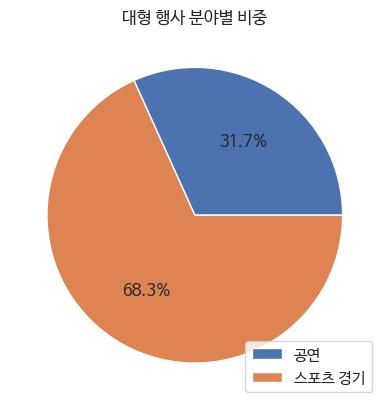

In [ ]:
plt.pie(
    ratio.values,
    autopct='%.1f%%'
)

plt.title('대형 행사 분야별 비중')
plt.legend(ratio.index)
plt.show()

#### 요일별 대형 행사 진행건수

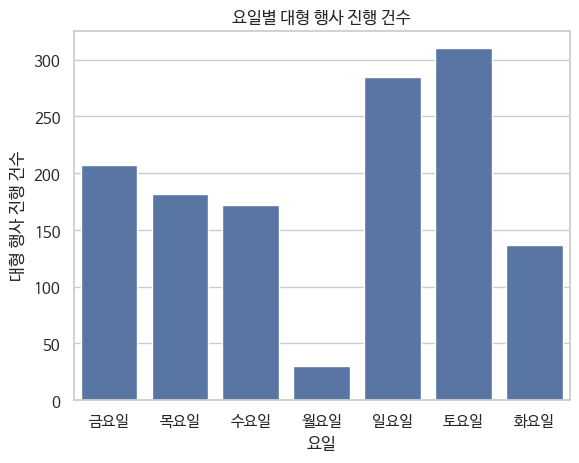

In [ ]:
day_of_week = big_event_df.groupby('요일')['제목'].count().reset_index()

sns.barplot(
    data=day_of_week,
    x='요일',
    y='제목'
)
plt.title('요일별 대형 행사 진행 건수')
plt.ylabel('대형 행사 진행 건수')
plt.show()

In [ ]:
week = big_event_df.groupby('평일/주말')['제목'].count().reset_index()
week

,평일/주말,제목
0,주말,595
1,평일,728


## 2020-2025년까지 서울 교통공사 지하철 데이터 + 종합운동장역 기초 EDA

### 연도별 데이터 범위 확인

In [ ]:
year_summary = (
    seoul_subway_clean_df.groupby('연도')
    .agg(
        행수=('연번', 'size'),
        시작일=('수송일자', 'min'),
        종료일=('수송일자', 'max'),
        날짜수=('수송일자', 'nunique'),
        역수=('역ID', 'nunique'),
        총승하차=('합계', 'sum')
    )
    .reset_index()
)

year_summary['일평균승하차'] = (
    year_summary['총승하차'] / year_summary['날짜수']
)

year_summary

,연도,행수,시작일,종료일,날짜수,역수,총승하차,일평균승하차
0,2020,202275,2020-01-01,2020-12-31,366,280,2564408395,7.006580e+06
1,2021,204374,2021-01-01,2021-12-31,365,284,2581848190,7.073557e+06
2,2022,199080,2022-01-01,2022-12-31,365,279,2835350063,7.768082e+06
3,2023,199270,2023-01-01,2023-12-31,365,282,3096242690,8.482857e+06
4,2024,199410,2024-01-01,2024-12-31,366,273,3193746993,8.726085e+06
5,2025,199290,2025-01-01,2025-12-31,365,273,3241663605,8.881270e+06


연도별 포함 역 수가 다르기 때문에 2020~2025년을 그대로 비교하면 역 추가, 제외 효과가 섞임 -> 모든 연도에 공통으로 있는 역 추출 필요

In [ ]:
station_year_count = (
    seoul_subway_clean_df[['역ID', '연도']]
    .drop_duplicates()
    .groupby('역ID')['연도']
    .nunique()
)

common_station_ids = station_year_count[
    station_year_count == seoul_subway_clean_df['연도'].nunique()
].index

len(common_station_ids)

268

In [ ]:
common_df = seoul_subway_clean_df[
    seoul_subway_clean_df['역ID'].isin(common_station_ids)
].copy()

### 연도별 일평균 승하차 추이

In [ ]:
daily_common = (
    common_df.groupby(['수송일자', '연도'])['합계']
    .sum()
    .reset_index()
)

annual_daily_average = (
    daily_common.groupby('연도')['합계']
    .mean()
    .reset_index(name='일평균승하차')
)

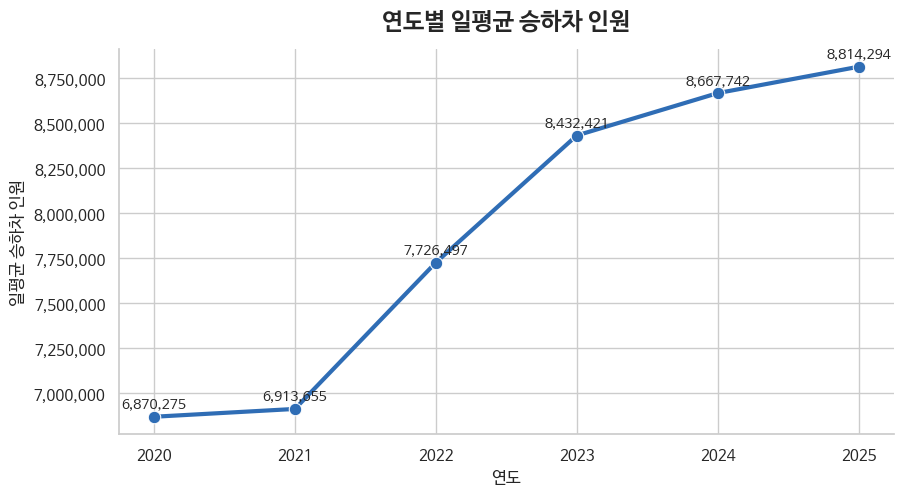

In [ ]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=annual_daily_average,
    x="연도",
    y="일평균승하차",
    marker="o",
    linewidth=3,
    markersize=9,
    color="#2F6DB5"
)

# 각 점 위에 값 표시
for x, y in zip(annual_daily_average["연도"],
                annual_daily_average["일평균승하차"]):
    ax.text(
        x, y + 50000,
        f"{y:,.0f}",
        ha="center",
        fontsize=10
    )

plt.title("연도별 일평균 승하차 인원", fontsize=17, weight="bold", pad=15)
plt.xlabel("연도", fontsize=12)
plt.ylabel("일평균 승하차 인원", fontsize=12)

# y축 천 단위 콤마
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
# 위, 오른쪽 테두리 제거
sns.despine()

plt.show()

### 평일, 토요일, 일요일 비교.

In [ ]:
daytype_average = (
    seoul_subway_clean_df
    .groupby(['수송일자', '연도', '요일구분'], as_index=False)['합계']
    .sum()
    .groupby(['연도', '요일구분'], as_index=False)['합계']
    .mean()
    .rename(columns={'합계': '일평균승하차'})
)

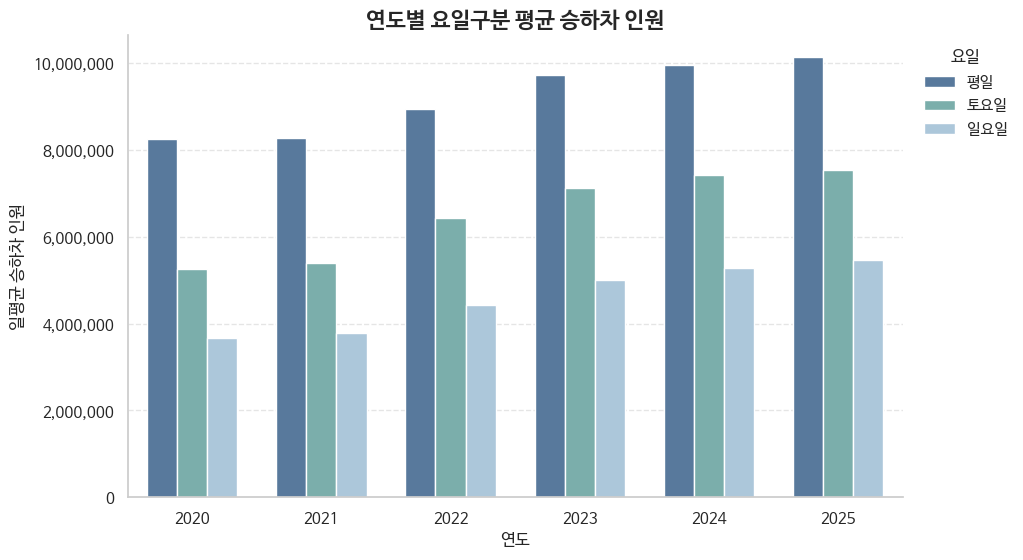

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=daytype_average,
    x="연도",
    y="일평균승하차",
    hue="요일구분",
    hue_order=["평일", "토요일", "일요일"],
    palette=["#4C78A8", "#72B7B2", "#A5C8E1"],
    width=0.7
)

plt.title("연도별 요일구분 평균 승하차 인원", fontsize=16, weight="bold")
plt.xlabel("연도", fontsize=12)
plt.ylabel("일평균 승하차 인원", fontsize=12)

# y축 천 단위 콤마
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

# 범례
ax.legend(
    title="요일",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# y축만 점선
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', visible=False)

sns.despine()

plt.show()

### 시간대별 패턴 분석

In [ ]:
daily_hourly = (
    seoul_subway_clean_df.groupby(
        ['수송일자', '연도', '요일구분', '승하차구분']
    )[common_time_cols]
    .sum()
    .reset_index()
)

# 요일 구분별 평균

average_hourly = (
    daily_hourly.groupby(
        ['연도', '요일구분', '승하차구분']
    )[common_time_cols]
    .mean()
    .reset_index()
)

In [ ]:
hourly_long = average_hourly.melt(
    id_vars=['연도', '요일구분', '승하차구분'],
    value_vars=common_time_cols,
    var_name='시간대',
    value_name='평균인원'
)

hourly_long['시간대'] = pd.Categorical(
    hourly_long['시간대'],
    categories=common_time_cols,
    ordered=True
)

25년의 승하차가 최댓값 2025년에 대한 그래프만 그려봄.

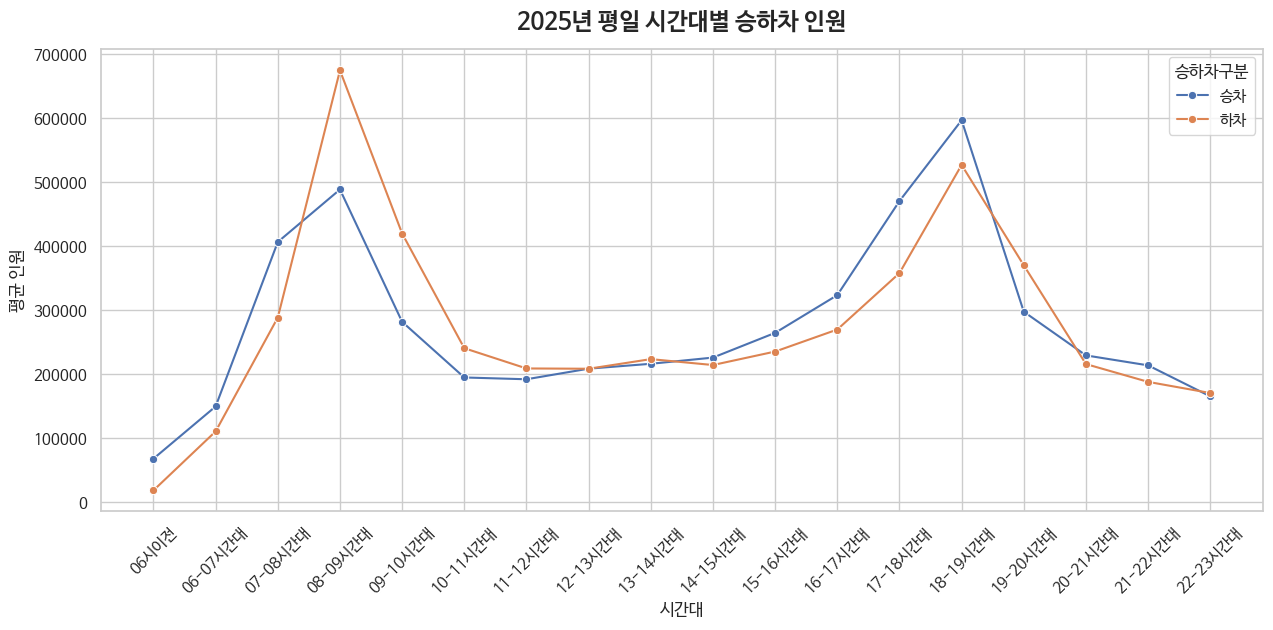

In [ ]:
hourly_2025_weekday = hourly_long[
    (hourly_long['연도'] == 2025) &
    (hourly_long['요일구분'] == '평일')
]

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=hourly_2025_weekday,
    x='시간대',
    y='평균인원',
    hue='승하차구분',
    marker='o'
)

plt.title('2025년 평일 시간대별 승하차 인원', fontsize=17, weight="bold", pad=15 )
plt.xlabel('시간대')
plt.ylabel('평균 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

### 종합운동장역에 대한 EDA

In [ ]:
stadium_df = seoul_subway_clean_df[
    (seoul_subway_clean_df['연도'] >= 2020) &
    (seoul_subway_clean_df['연도'] <= 2025) &
    (seoul_subway_clean_df['호선'] == '2호선') &
    (seoul_subway_clean_df['역명_표준'] == '종합운동장') &
    (seoul_subway_clean_df['승하차구분'] == '승차')
].copy()

In [ ]:
stadium_df[
    ['호선', '역번호', '역ID', '역명_표준']
].drop_duplicates()

,호선,역번호,역ID,역명_표준
54,2호선,218,2호선_218,종합운동장


In [ ]:
seoul_subway_clean_df['역명_표준'] = seoul_subway_clean_df['역명_표준'].astype('string').str.strip()

stadium_df = seoul_subway_clean_df[
    (seoul_subway_clean_df['연도'].between(2020, 2025)) &
    (seoul_subway_clean_df['호선'] == '2호선') &
    (seoul_subway_clean_df['역명_표준'] == '종합운동장') &
    (seoul_subway_clean_df['승하차구분'] == '승차')
].copy()

In [ ]:
evening_cols = [
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대',
    '23시 이후_통합'
]

In [ ]:
for col in evening_cols:
    stadium_df[col] = pd.to_numeric(
        stadium_df[col],
        errors='coerce'
    )

In [ ]:
# 날짜별 야간 승차 인원
stadium_day = stadium_df[
    [
        '수송일자',
        '연도',
        '요일구분'
    ] + evening_cols
].copy()

In [ ]:
stadium_day['18시이후승차'] = (
    stadium_day[evening_cols].sum(axis=1)
)

#### 연도별 야간추이

In [ ]:
stadium_year_average = (
    stadium_day.groupby('연도')['18시이후승차']
    .mean()
    .reset_index(name='일평균_18시이후승차')
)

stadium_year_average

,연도,일평균_18시이후승차
0,2020,1586.199454
1,2021,1726.882192
2,2022,4881.813699
3,2023,5232.331507
4,2024,5664.784153
5,2025,6294.517808


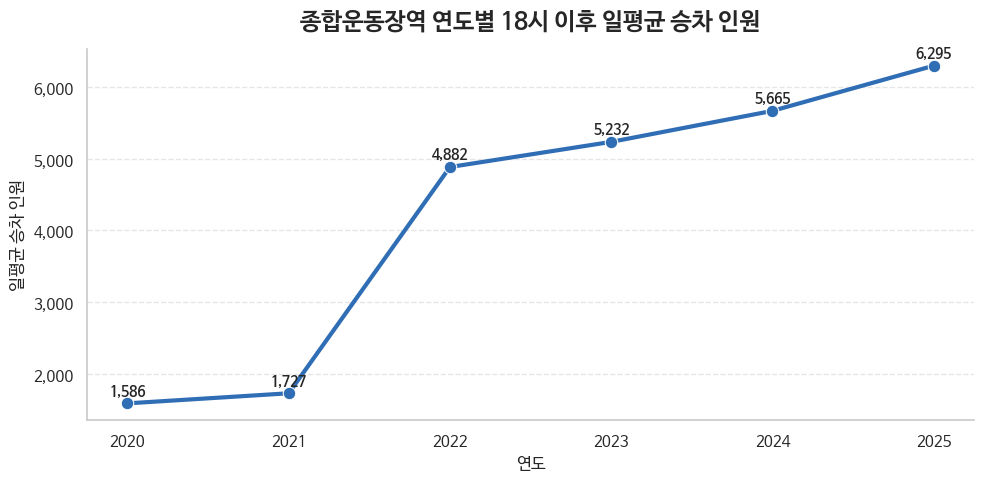

In [ ]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=stadium_year_average,
    x="연도",
    y="일평균_18시이후승차",
    marker="o",
    linewidth=3,
    markersize=9,
    color="#2F6DB5"
)

# 값 표시
for x, y in zip(
    stadium_year_average["연도"],
    stadium_year_average["일평균_18시이후승차"]
):
    ax.text(
        x,
        y + 120,
        f"{y:,.0f}",
        ha="center",
        fontsize=10,
        weight="bold"
    )

plt.title(
    "종합운동장역 연도별 18시 이후 일평균 승차 인원",
    fontsize=17,
    weight="bold",
    pad=15
)

plt.xlabel("연도", fontsize=12)
plt.ylabel("일평균 승차 인원", fontsize=12)

# y축 천 단위 콤마
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

# x축을 연도만 표시
plt.xticks(stadium_year_average["연도"])

# y축만 점선
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', visible=False)

# 위·오른쪽 테두리 제거
sns.despine()

plt.tight_layout()
plt.show()

#### 연도별 시간대 패턴 확인

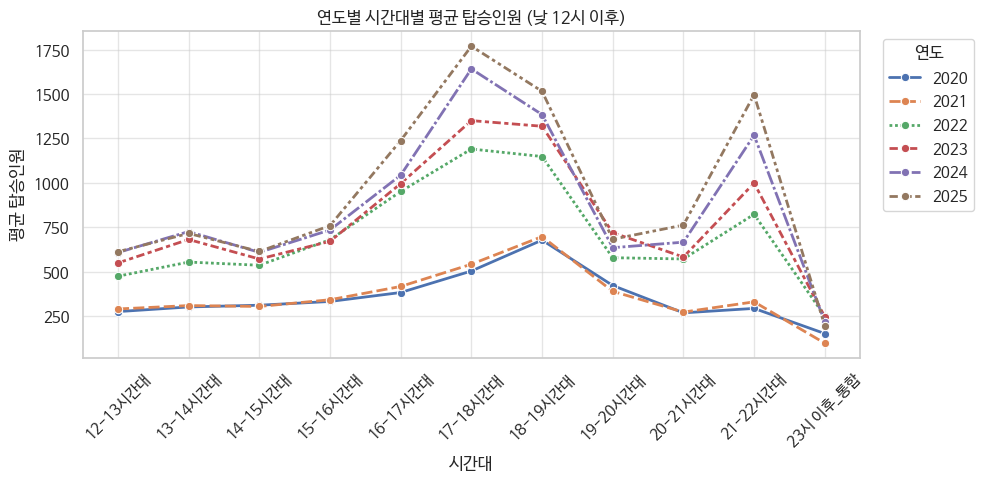

In [ ]:
# 연도별 시간대별 평균 탑승인원 (낮 12시 이후)
time_cols2 = [f"{i:02d}-{i+1:02d}시간대" for i in range(12, 22)] + ['23시 이후_통합']

# 연도별 시간대별 평균 구하기
yearly_time_mean = jonghab_df.groupby('연도')[time_cols2].mean()

# 행에 시간대, 열에 연도가 오도록 뒤집기
plot_df = yearly_time_mean.T

plt.figure(figsize=(10, 5))

sns.lineplot(data=plot_df, marker='o', linewidth=2)

plt.title('연도별 시간대별 평균 탑승인원 (낮 12시 이후)')
plt.xlabel('시간대')
plt.ylabel('평균 탑승인원')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.legend(title='연도', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
stadium_hour = stadium_day.melt(
    id_vars=[
        '수송일자',
        '연도',
        '요일구분'
    ],
    value_vars=evening_cols,
    var_name='시간대',
    value_name='승차인원'
)
stadium_hour['시간대'] = pd.Categorical(
    stadium_hour['시간대'],
    categories=evening_cols,
    ordered=True
)

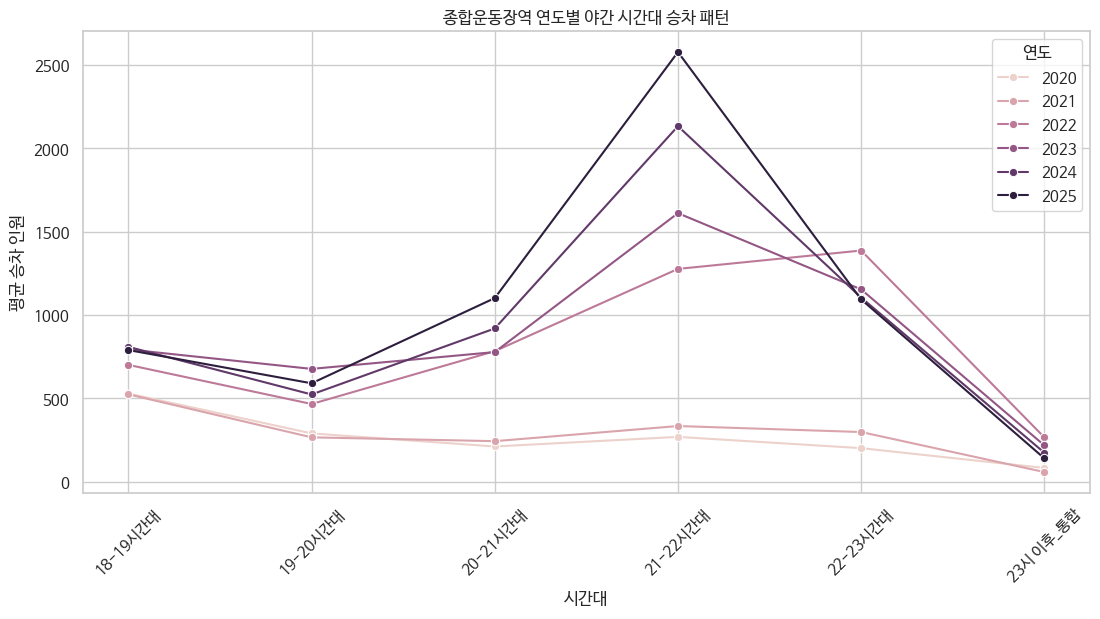

In [ ]:
stadium_year_hour = (
    stadium_hour.groupby(
        ['연도', '시간대'],
        observed=True
    )['승차인원']
    .mean()
    .reset_index(name='평균승차인원')
)
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=stadium_year_hour,
    x='시간대',
    y='평균승차인원',
    hue='연도',
    marker='o'
)

plt.title('종합운동장역 연도별 야간 시간대 승차 패턴')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### 시간대별

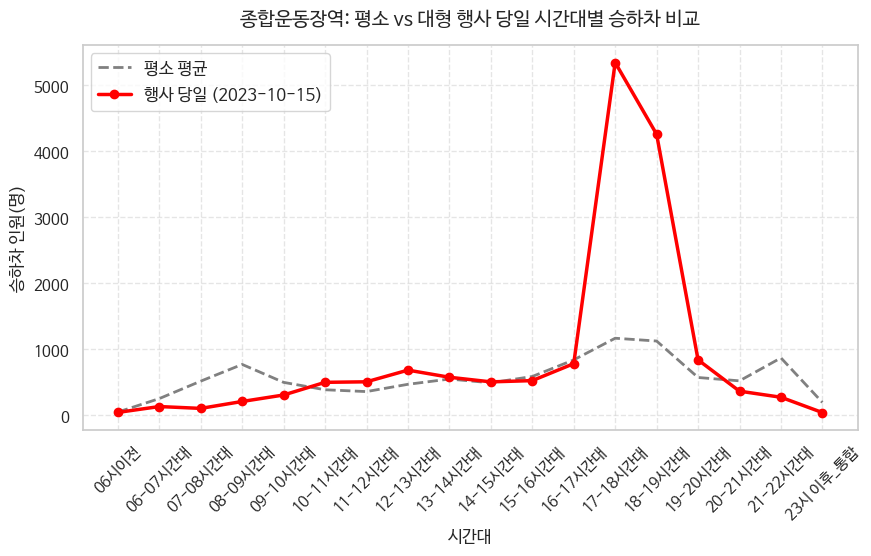

In [ ]:
# 1. 시간대 컬럼 목록
time_cols = ['06시이전'] + [f"{i:02d}-{i+1:02d}시간대" for i in range(6, 22)] + ['23시 이후_통합']

# 2. 평소(전체 기간) 시간대별 평균 구하기
normal_mean = jonghab_df[time_cols].mean()

# 3. 콘서트/행사가 있던 특정 날짜 데이터 추출(임시로 2023-10-15를 입력)
event_day = jonghab_df[jonghab_df['수송일자'] == '2023-10-15'].iloc[0]

# 4. 비교 시각화
plt.figure(figsize=(10, 5))

# (1) 평소 평균 (기준선 - 회색 점선)
plt.plot(time_cols, normal_mean[time_cols], label='평소 평균', color='gray', linestyle='--', linewidth=2)

# (2) 행사 당일 (강조선 - 빨간색)
plt.plot(time_cols, event_day[time_cols], label='행사 당일 (2023-10-15)', color='red', marker='o', linewidth=2.5)

plt.title('종합운동장역: 평소 vs 대형 행사 당일 시간대별 승하차 비교', fontsize=14, pad=15)
plt.xlabel('시간대')
plt.ylabel('승하차 인원(명)')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### 평일, 토요일, 일요일 비교

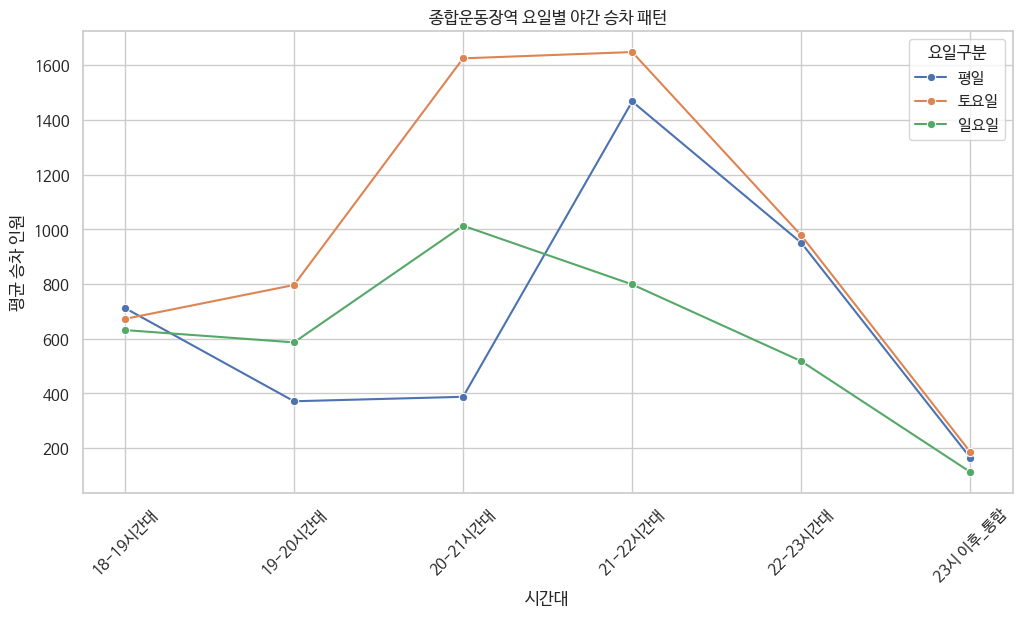

In [ ]:

stadium_daytype_hour = (
    stadium_hour.groupby(
        ['요일구분', '시간대'],
        observed=True
    )['승차인원']
    .mean()
    .reset_index(name='평균승차인원')
)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=stadium_daytype_hour,
    x='시간대',
    y='평균승차인원',
    hue='요일구분',
    hue_order=['평일', '토요일', '일요일'],
    marker='o'
)

plt.title('종합운동장역 요일별 야간 승차 패턴')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### 시간대별 요일별

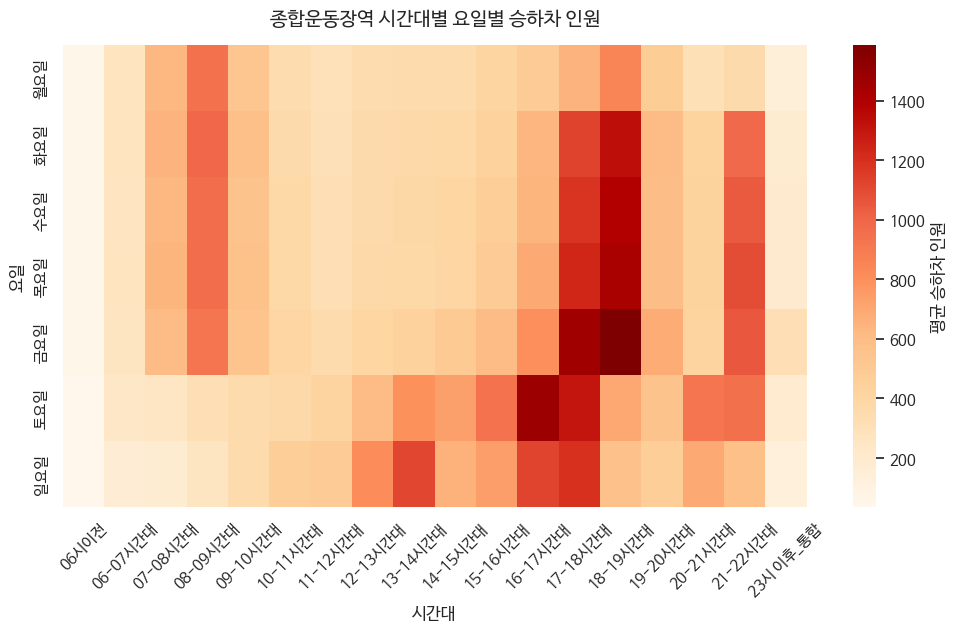

In [ ]:
# 시간대별 요일별 평균 승하차인원 히트맵
heatmap_data = jonghab_df.groupby('요일')[time_cols].mean()

day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='OrRd', annot=False, fmt='.0f', cbar_kws={'label': '평균 승하차 인원'})

plt.title('종합운동장역 시간대별 요일별 승하차 인원', fontsize=14, pad=15)
plt.xlabel('시간대')
plt.ylabel('요일')
plt.xticks(rotation=45)
plt.show()

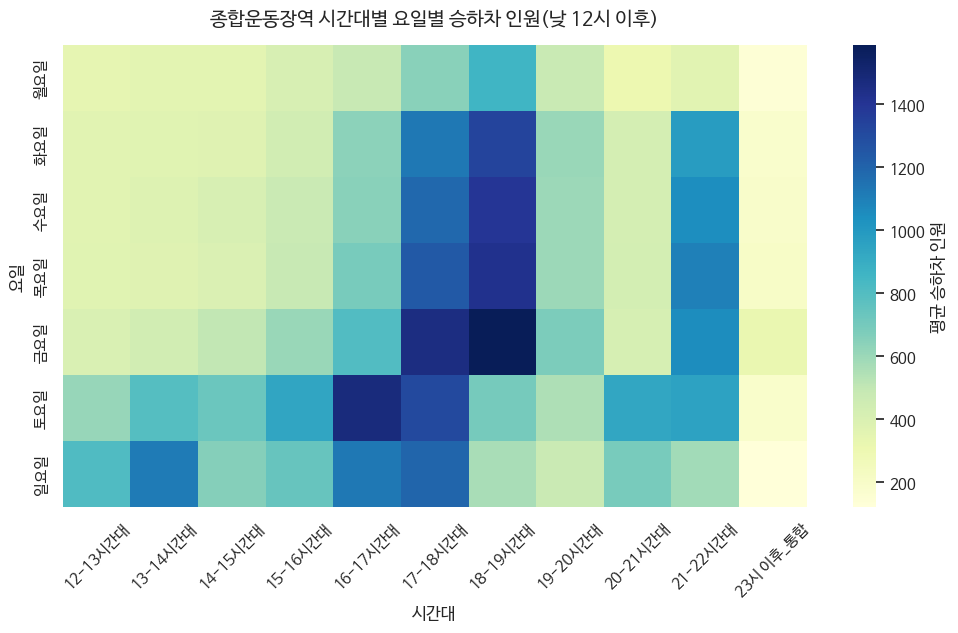

In [ ]:
# 시간대별 요일별 평균 승하차인원 히트맵 (낮 12시 이후)
time_cols2 = [f"{i:02d}-{i+1:02d}시간대" for i in range(12, 22)] + ['23시 이후_통합']

heatmap_data = jonghab_df.groupby('요일')[time_cols2].mean()

day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
jonghab_df['요일'] = pd.Categorical(jonghab_df['요일'], categories=day_order, ordered=True)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt='.0f', cbar_kws={'label': '평균 승하차 인원'})

plt.title('종합운동장역 시간대별 요일별 승하차 인원(낮 12시 이후)', fontsize=14, pad=15)
plt.xlabel('시간대')
plt.ylabel('요일')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_146190/2231516528.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_m = df_month.groupby('요일')[time_cols3].mean()
/tmp/ipykernel_146190/2231516528.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_m = df_month.groupby('요일')[time_cols3].mean()
/tmp/ipykernel_146190/2231516528.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_m = df_month.groupby('요일')[time_cols3].mean()
/tmp/ipyke

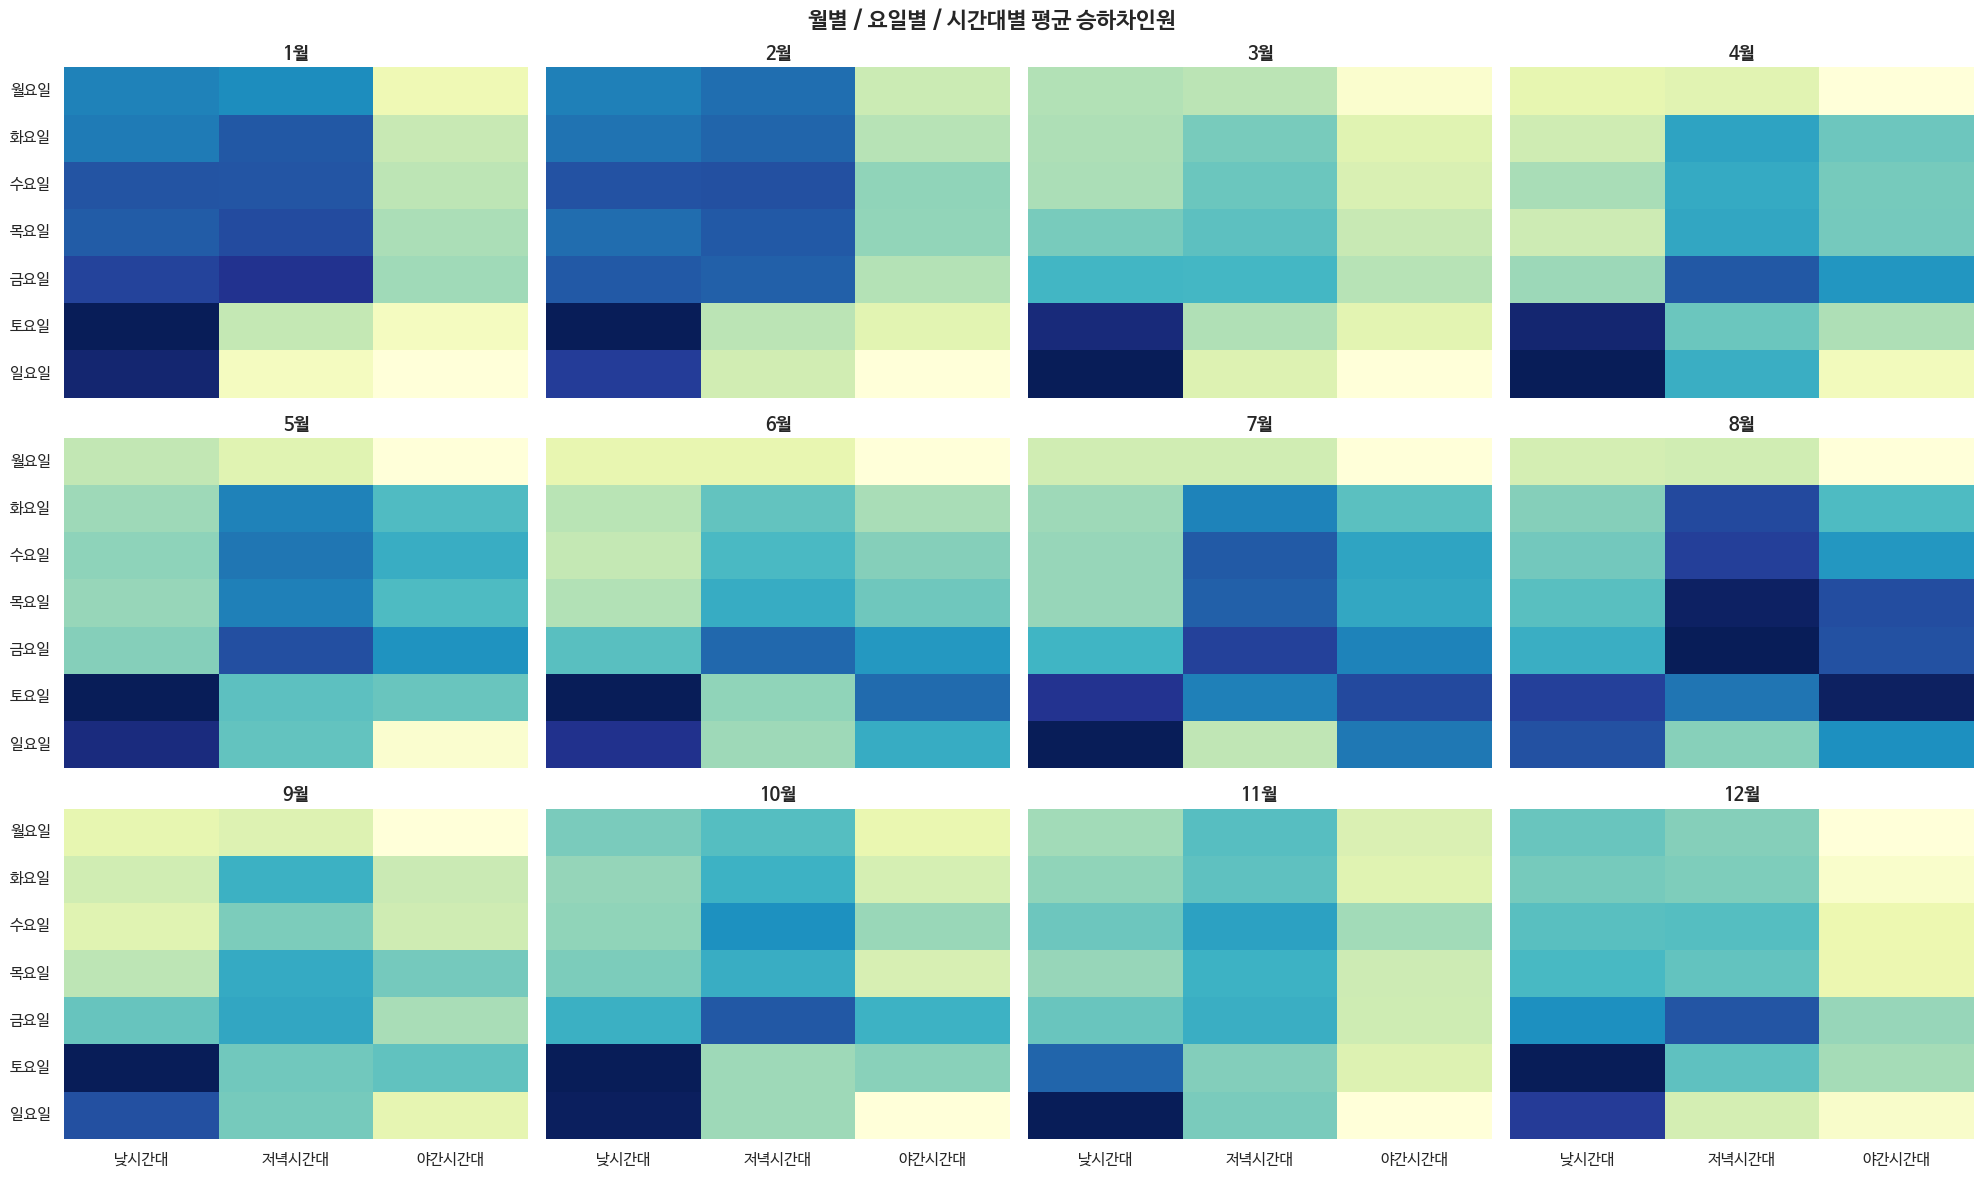

In [ ]:
# 시간대별 요일별 평균 승하차 인원의 월별 히트맵(서브플롯)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

time_cols3 = ['낮시간대', '저녁시간대', '야간시간대']

# 1월부터 12월까지 반복문 돌며 히트맵 그리기
for m in range(1, 13):
    ax = axes[m-1]

    # 해당 월 데이터만 추출 후 (요일 x 시간구분) 평균 집계
    df_month = jonghab_df[jonghab_df['월'] == m]

    pivot_m = df_month.groupby('요일')[time_cols3].mean()

    sns.heatmap(pivot_m, cmap='YlGnBu', ax=ax, cbar=False, annot=False)
    ax.set_title(f'{m}월', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('월별 / 요일별 / 시간대별 평균 승하차인원', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 해석: 모든 연도 1월의 모든 월요일의 낮시간대 평균 승하차인원

#### 날짜별 평시 기준 계산

In [ ]:
stadium_baseline = (
    stadium_hour.groupby(
        ['연도', '요일구분', '시간대'],
        observed=True
    )['승차인원']
    .median()
    .reset_index(name='평시승차인원')
)
stadium_compare = stadium_hour.merge(
    stadium_baseline,
    on=[
        '연도',
        '요일구분',
        '시간대'
    ],
    how='left'
)

In [ ]:
# 평소 대비 증가 인원과 증가율 계산
stadium_compare['증가인원'] = (
    stadium_compare['승차인원'] -
    stadium_compare['평시승차인원']
)
stadium_compare['증가율'] = np.where(
    stadium_compare['평시승차인원'] > 0,
    (
        stadium_compare['승차인원'] /
        stadium_compare['평시승차인원']
    ) - 1,
    np.nan
)
stadium_compare['증가율_pct'] = (
    stadium_compare['증가율'] * 100
)
stadium_compare['초과승차인원'] = (
    stadium_compare['증가인원'].clip(lower=0)
)

In [ ]:
# 날짜별 야간 초과 수요 계산
stadium_day_result = (
    stadium_compare.groupby(
        [
            '수송일자',
            '연도',
            '요일구분'
        ]
    )
    .agg(
        실제승차인원=('승차인원', 'sum'),
        평시승차인원=('평시승차인원', 'sum'),
        초과승차인원=('초과승차인원', 'sum')
    )
    .reset_index()
)

#날짜별 전체 증가율 계산
stadium_day_result['전체증가율'] = np.where(
    stadium_day_result['평시승차인원'] > 0,
    (
        stadium_day_result['실제승차인원'] /
        stadium_day_result['평시승차인원']
    ) - 1,
    np.nan
)

stadium_day_result['전체증가율_pct'] = (
    stadium_day_result['전체증가율'] * 100
)

In [ ]:
# 날짜별 최대 증가 시간대 계산
stadium_peak_hour = (
    stadium_compare.loc[
        stadium_compare.groupby('수송일자')['증가인원'].idxmax(),
        [
            '수송일자',
            '시간대',
            '승차인원',
            '평시승차인원',
            '증가인원',
            '증가율_pct'
        ]
    ]
    .reset_index(drop=True)
)
stadium_peak_hour = stadium_peak_hour.rename(
    columns={
        '시간대': '최대증가시간대',
        '승차인원': '최대시간대승차인원',
        '평시승차인원': '최대시간대평시인원',
        '증가인원': '최대시간대증가인원',
        '증가율_pct': '최대시간대증가율_pct'
    }
)
stadium_eda_result = stadium_day_result.merge(
    stadium_peak_hour,
    on='수송일자',
    how='left'
)

In [ ]:
# 평소보다 수요가 초과한 날짜 확인
stadium_eda_result[
    [
        '수송일자',
        '연도',
        '요일구분',
        '실제승차인원',
        '평시승차인원',
        '초과승차인원',
        '전체증가율_pct',
        '최대증가시간대',
        '최대시간대증가인원',
        '최대시간대증가율_pct'
    ]
].sort_values(
    '초과승차인원',
    ascending=False
)

,수송일자,연도,요일구분,실제승차인원,평시승차인원,초과승차인원,전체증가율_pct,최대증가시간대,최대시간대증가인원,최대시간대증가율_pct
1263,2023-06-17,2023,토요일,35278.0,3074.0,32204.0,1047.625244,22-23시간대,12906.0,4676.086957
1264,2023-06-18,2023,일요일,33666.0,1676.0,31990.0,1908.711217,22-23시간대,16326.0,14074.137931
927,2022-07-16,2022,토요일,33549.0,3132.0,30571.0,971.168582,22-23시간대,18476.0,5940.836013
990,2022-09-17,2022,토요일,32495.0,3132.0,29363.0,937.515964,22-23시간대,18587.0,5976.527331
1276,2023-06-30,2023,평일,30738.0,2345.0,28393.0,1210.788913,22-23시간대,18754.0,8846.226415
...,...,...,...,...,...,...,...,...,...,...
1803,2024-12-08,2024,일요일,927.0,1450.0,0.0,-36.068966,21-22시간대,0.0,0.000000
1802,2024-12-07,2024,토요일,1200.0,3071.0,0.0,-60.924780,23시 이후_통합,-21.0,-25.301205
1801,2024-12-06,2024,평일,1669.0,1929.5,0.0,-13.500907,23시 이후_통합,-5.5,-5.069124
1800,2024-12-05,2024,평일,1512.0,1929.5,0.0,-21.637730,22-23시간대,-30.0,-18.987342


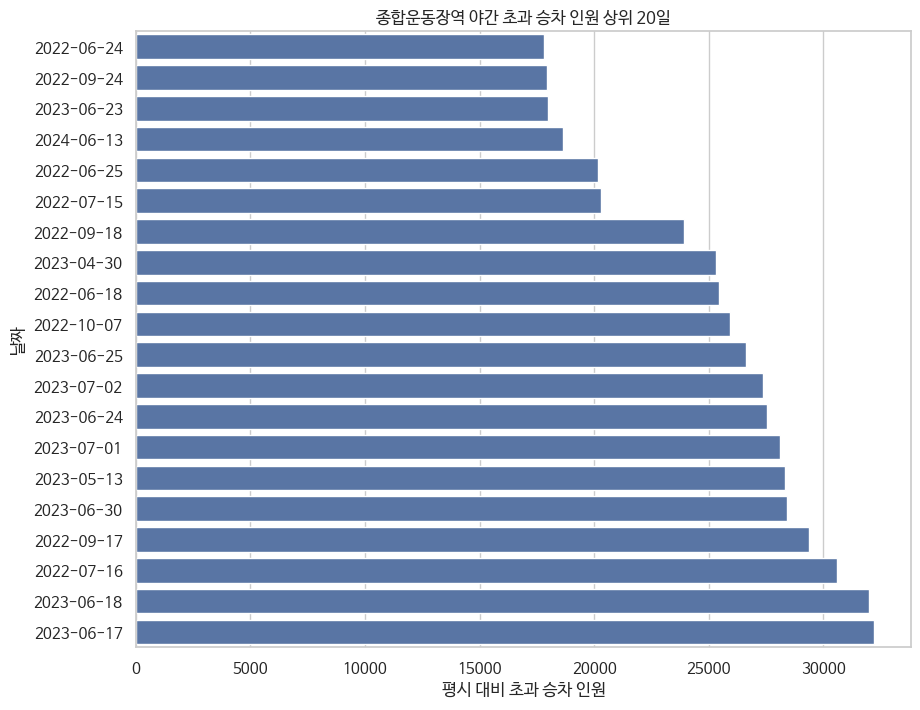

In [ ]:
top20_stadium_days = (
    stadium_eda_result
    .sort_values('초과승차인원', ascending=False)
    .head(20)
    .sort_values('초과승차인원')
)
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20_stadium_days,
    x='초과승차인원',
    y='수송일자'
)

plt.title('종합운동장역 야간 초과 승차 인원 상위 20일')
plt.xlabel('평시 대비 초과 승차 인원')
plt.ylabel('날짜')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

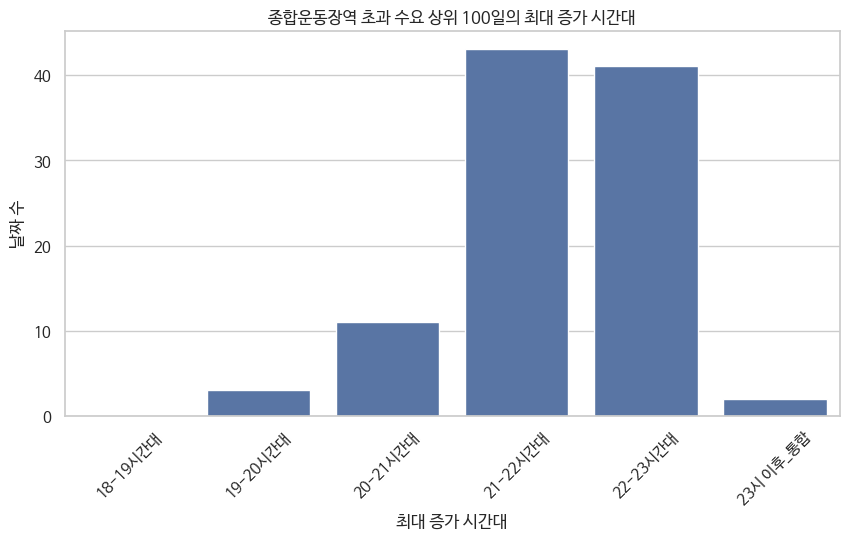

In [ ]:
# 최대 증가 시간대 분포 확인

top100_stadium_days = (
    stadium_eda_result
    .sort_values('초과승차인원', ascending=False)
    .head(100)
)

peak_hour_count = (
    top100_stadium_days['최대증가시간대']
    .value_counts()
    .reindex(evening_cols, fill_value=0)
    .reset_index()
)

peak_hour_count.columns = ['최대증가시간대', '날짜수']

peak_hour_count

plt.figure(figsize=(10, 5))

sns.barplot(
    data=peak_hour_count,
    x='최대증가시간대',
    y='날짜수'
)

plt.title('종합운동장역 초과 수요 상위 100일의 최대 증가 시간대')
plt.xlabel('최대 증가 시간대')
plt.ylabel('날짜 수')
plt.xticks(rotation=45)
plt.show()

## 혼잡도 기초 EDA

연도별 시간대 평균 혼잡도

In [ ]:
subway_long.groupby(
    ["연도", "시간대"]
)["혼잡도"].mean()

연도    시간대        
2020  12:00~12:59    21.775000
      13:00~13:59    23.587500
      14:00~14:59    22.593750
      15:00~15:59    24.718750
      16:00~16:59    28.156250
                       ...    
2025  19:00~19:59    35.129688
      20:00~20:59    34.110937
      21:00~21:59    39.775000
      22:00~22:59    31.757812
      23:00~23:59    17.995313
Name: 혼잡도, Length: 72, dtype: float64

요일별 시간대 평균 혼잡도

In [ ]:
subway_long.groupby(
    ["요일구분", "시간대"]
)["혼잡도"].mean()

요일구분  시간대        
주말    12:00~12:59    32.231250
      13:00~13:59    34.713542
      14:00~14:59    33.376042
      15:00~15:59    35.587500
      16:00~16:59    39.487500
      17:00~17:59    40.564583
      18:00~18:59    35.828125
      19:00~19:59    28.396875
      20:00~20:59    30.884375
      21:00~21:59    30.179167
      22:00~22:59    25.308333
      23:00~23:59    15.667708
평일    12:00~12:59    29.968750
      13:00~13:59    31.008333
      14:00~14:59    30.579167
      15:00~15:59    36.985417
      16:00~16:59    42.068750
      17:00~17:59    51.256250
      18:00~18:59    61.562500
      19:00~19:59    37.683333
      20:00~20:59    30.652083
      21:00~21:59    41.081250
      22:00~22:59    36.850000
      23:00~23:59    19.729167
Name: 혼잡도, dtype: float64

상하구분별 시간대 평균 혼잡도

In [ ]:
subway_long.groupby(
    ["상하구분", "시간대"]
)["혼잡도"].mean()

상하구분  시간대        
내선    12:00~12:59    31.366667
      13:00~13:59    32.052083
      14:00~14:59    29.850000
      15:00~15:59    31.469792
      16:00~16:59    33.968750
      17:00~17:59    36.178125
      18:00~18:59    34.486458
      19:00~19:59    24.687500
      20:00~20:59    25.751042
      21:00~21:59    29.296875
      22:00~22:59    24.486458
      23:00~23:59    13.237500
외선    12:00~12:59    30.833333
      13:00~13:59    33.669792
      14:00~14:59    34.105208
      15:00~15:59    41.103125
      16:00~16:59    47.587500
      17:00~17:59    55.642708
      18:00~18:59    62.904167
      19:00~19:59    41.392708
      20:00~20:59    35.785417
      21:00~21:59    41.963542
      22:00~22:59    37.671875
      23:00~23:59    22.159375
Name: 혼잡도, dtype: float64

In [ ]:
# 시간대별 평균 혼잡도 확인
# 저녁 시간대의 평균 혼잡도가 가장 높았으며, 야간보다 낮 시간대의 평균 혼잡도가 더 높게 나타남
# 저녁 > 낮 > 야간
time_mean = subway_long.groupby(
    "시간대구분"
)["혼잡도"].mean().reset_index()

time_mean

,시간대구분,혼잡도
0,낮,34.600625
1,야간,28.794010
2,저녁,42.548611


#### 시간대별 평균 혼잡도 확인
저녁 시간대의 평균 혼잡도가 가장 높았으며, 야간보다 낮 시간대의 평균 혼잡도가 더 높게 나타남
(저녁 > 낮 > 야간)

/tmp/ipykernel_146190/3537016850.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


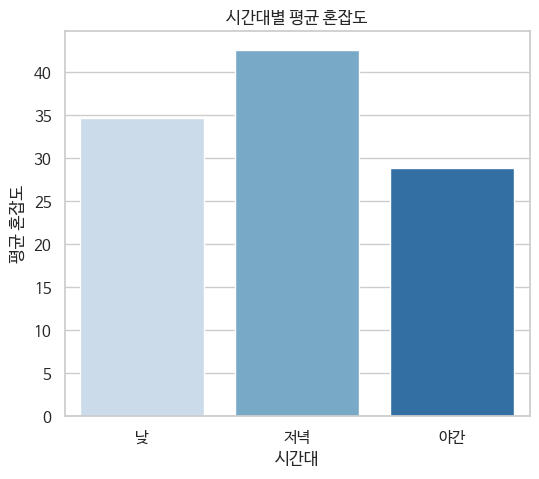

In [ ]:
time_mean = subway_long.groupby(
    "시간대구분"
)["혼잡도"].mean().reset_index()

plt.figure(figsize=(6, 5))

sns.barplot(
    data=time_mean,
    x="시간대구분",
    y="혼잡도",
    order=["낮", "저녁", "야간"],
    palette="Blues"
)

plt.xlabel("시간대")
plt.ylabel("평균 혼잡도")
plt.title("시간대별 평균 혼잡도")

plt.show()

#### 연도별 시간대 평균 혼잡도
모든 연도에서 저녁 시간대 혼잡도가 가장 높았으며, 낮, 저녁, 야간 모든 시간대에서 혼잡도가 증가하는 추세를 확인함

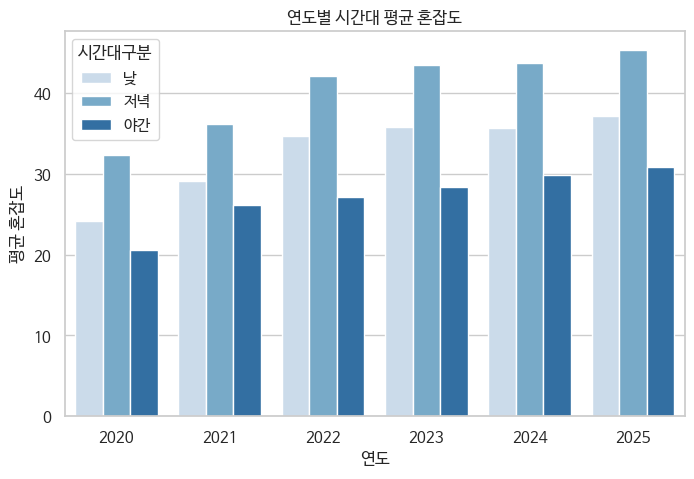

In [ ]:
year_time = subway_long.groupby(
    ["연도", "시간대구분"]
)["혼잡도"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=year_time,
    x="연도",
    y="혼잡도",
    hue="시간대구분",
    hue_order=["낮", "저녁", "야간"],
    palette="Blues"
)

plt.xlabel("연도")
plt.ylabel("평균 혼잡도")
plt.title("연도별 시간대 평균 혼잡도")

plt.show()

#### 요일별 시간대 평균 혼잡도
모든 요일에서 혼잡도가 전반적으로 증가하는 추세를 보였으며,
주말의 경우 2024년부터 혼잡도가 상대적으로 크게 증가함

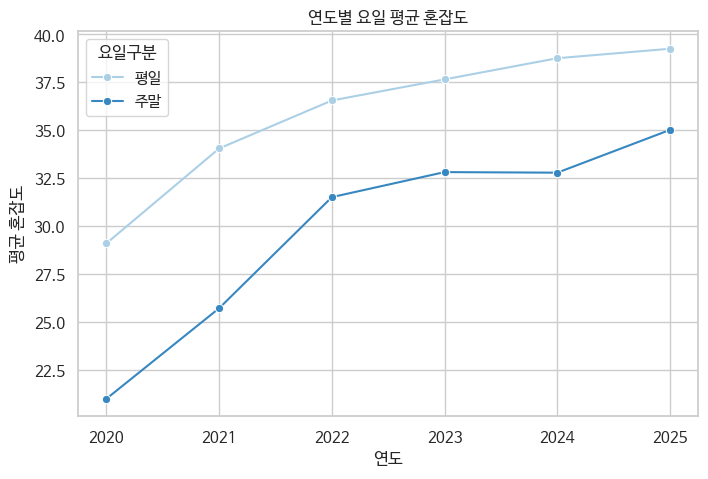

In [ ]:
year_weekday = subway_long.groupby(
    ["연도", "요일구분"]
)["혼잡도"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=year_weekday,
    x="연도",
    y="혼잡도",
    hue="요일구분",
    hue_order=["평일", "주말"],
    marker="o",
    palette="Blues"
)

plt.xlabel("연도")
plt.ylabel("평균 혼잡도")
plt.title("연도별 요일 평균 혼잡도")

plt.show()

#### 상하구분별 시간대 평균 혼잡도
외선이 내선보다 전반적으로 높은 혼잡도를 보였으며,
내선과 외선 모두 연도가 지날수록 혼잡도가 증가하는 추세를 확인함

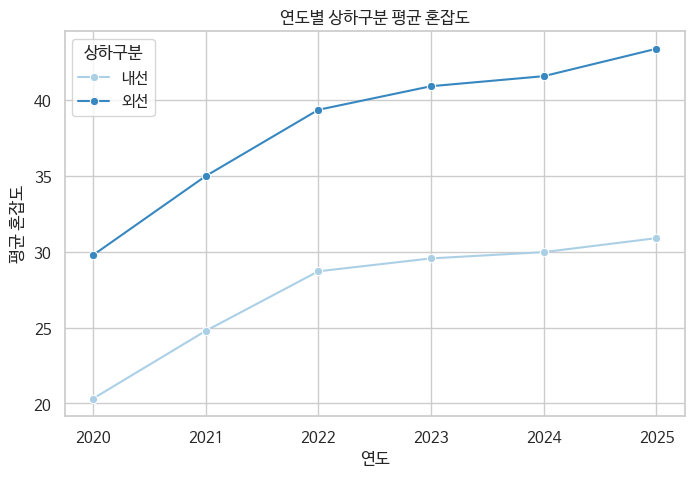

In [ ]:
year_direction = subway_long.groupby(
    ["연도", "상하구분"]
)["혼잡도"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=year_direction,
    x="연도",
    y="혼잡도",
    hue="상하구분",
    hue_order=["내선", "외선"],
    marker="o",
    palette="Blues"
)

plt.xlabel("연도")
plt.ylabel("평균 혼잡도")
plt.title("연도별 상하구분 평균 혼잡도")

plt.show()

#### 시간대별 상하구분 평균 혼잡도 확인
모든 시간대에서 외선의 평균 혼잡도가 내선보다 높게 나타났으며,
특히 저녁 시간대에 외선 혼잡도가 가장 높은 경향을 확인함


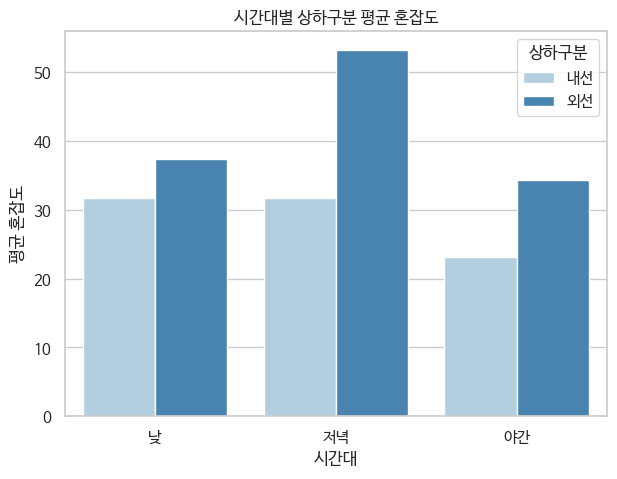

In [ ]:
time_direction = subway_long.groupby(
    ["시간대구분", "상하구분"]
)["혼잡도"].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=time_direction,
    x="시간대구분",
    y="혼잡도",
    hue="상하구분",
    order=["낮", "저녁", "야간"],
    hue_order=["내선", "외선"],
    palette="Blues"
)

plt.xlabel("시간대")
plt.ylabel("평균 혼잡도")
plt.title("시간대별 상하구분 평균 혼잡도")

plt.show()

## 혼잡도 통합 기초 EDA

혼잡도_통합.csv파일을 다시 확인해보니 24, 25년이 2호선이 분기별로 들어간 것을 확인하고 나중에 계산할 때 4배로 가중치가 적용되어서 영향이 커질 수도 있어 연간단위로 수정.


```
yearly_congestion = (
    congestion_df
    .groupby(['연도', '역명', '요일구분', '호선', '일반급행구분', '상하구분', '시간대'])['혼잡도']
    .mean()
    .reset_index()
)
```
---
이후 혼잡도_통합_v2.csv 파일을 사용.


In [ ]:
congestion_df = pd.read_csv(f"{base_path}/data/혼잡도_통합_v2.csv")

#### 시간대별 혼잡도

In [ ]:
# 시간대 순서 지정
time_order = [
    "12:00~12:59",
    "13:00~13:59",
    "14:00~14:59",
    "15:00~15:59",
    "16:00~16:59",
    "17:00~17:59",
    "18:00~18:59",
    "19:00~19:59",
    "20:00~20:59",
    "21:00~21:59",
    "22:00~22:59",
    "23:00~23:59",
    "00:00~00:59"
]

congestion_df["시간대"] = pd.Categorical(
    congestion_df["시간대"],
    categories=time_order,
    ordered=True
)

congestion_df = congestion_df.sort_values("시간대")

In [ ]:
# 평균 혼잡도
peak = (congestion_df.groupby(["시간대", "요일구분"])["혼잡도"].mean().reset_index())

/tmp/ipykernel_146190/2362859424.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak = (congestion_df.groupby(["시간대", "요일구분"])["혼잡도"].mean().reset_index())


In [ ]:
pivot = peak.pivot(
    index="시간대",
    columns="요일구분",
    values="혼잡도"
)

pivot

요일구분,주말,평일
시간대,,
12:00~12:59,26.796575,23.308981
13:00~13:59,28.678887,24.380633
14:00~14:59,28.261866,23.761180
15:00~15:59,30.223234,27.706816
16:00~16:59,34.640439,33.885059
17:00~17:59,34.231373,44.767670
18:00~18:59,28.778455,57.216551
19:00~19:59,22.613128,34.259464
20:00~20:59,25.333386,24.775817


In [ ]:
median_peak = congestion_df.groupby("시간대")["혼잡도"].median().sort_index()

median_peak

/tmp/ipykernel_146190/127125268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_peak = congestion_df.groupby("시간대")["혼잡도"].median().sort_index()


,혼잡도
시간대,
12:00~12:59,24.872500
13:00~13:59,26.075000
14:00~14:59,24.631000
15:00~15:59,30.262500
16:00~16:59,34.915625
17:00~17:59,39.426432
18:00~18:59,35.378750
19:00~19:59,25.582500
20:00~20:59,24.840000


In [ ]:
# 평일/주말 시간대별 최대 혼잡도
max_pivot = congestion_df.groupby(
    ["요일구분", "시간대"]
)["혼잡도"].max().reset_index()

max_pivot = max_pivot.pivot(
    index="시간대",
    columns="요일구분",
    values="혼잡도"
)

max_pivot

/tmp/ipykernel_146190/3284485599.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_pivot = congestion_df.groupby(


요일구분,주말,평일
시간대,,
12:00~12:59,48.990000,37.1410
13:00~13:59,47.332500,36.3900
14:00~14:59,46.102500,33.6875
15:00~15:59,54.402500,43.8375
16:00~16:59,54.127500,53.7250
17:00~17:59,52.137500,69.4625
18:00~18:59,43.706250,89.4375
19:00~19:59,37.010000,56.2750
20:00~20:59,47.797500,45.8080


#### 평일/주말 시간대별 평균 혼잡도

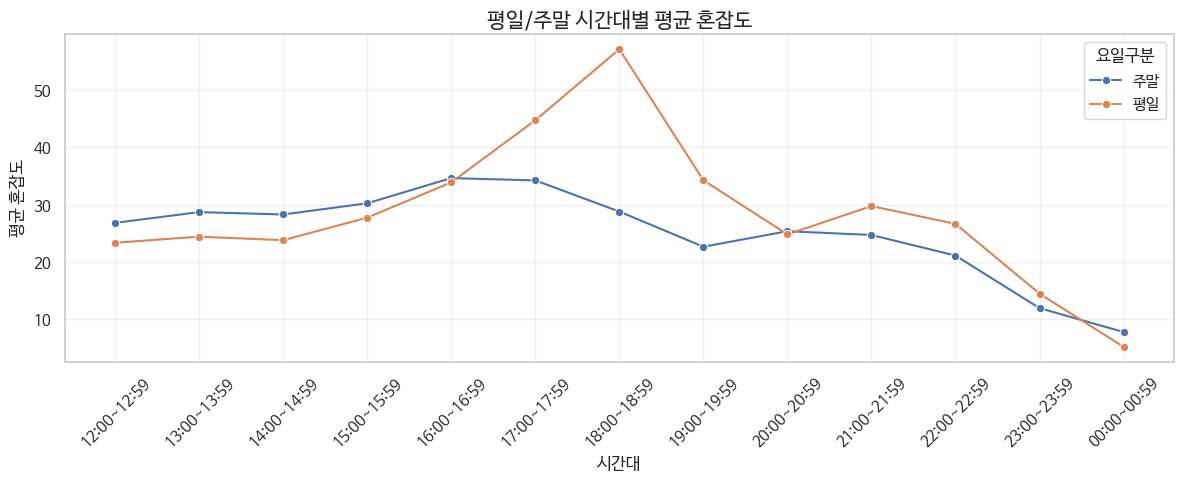

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=peak,
    x="시간대",
    y="혼잡도",
    hue="요일구분",
    marker="o"
)

plt.title("평일/주말 시간대별 평균 혼잡도", fontsize=15)
plt.xlabel("시간대")
plt.ylabel("평균 혼잡도")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
sports_df = congestion_df[congestion_df['역명'] == '종합운동장']

/tmp/ipykernel_146190/2812095808.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_146190/2812095808.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_146190/2812095808.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  congestion_df.groupby(['시간대', '정렬순서', '요일구분'])['혼잡도']
/tmp/ipykernel_146190/2812095808.py:99: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed

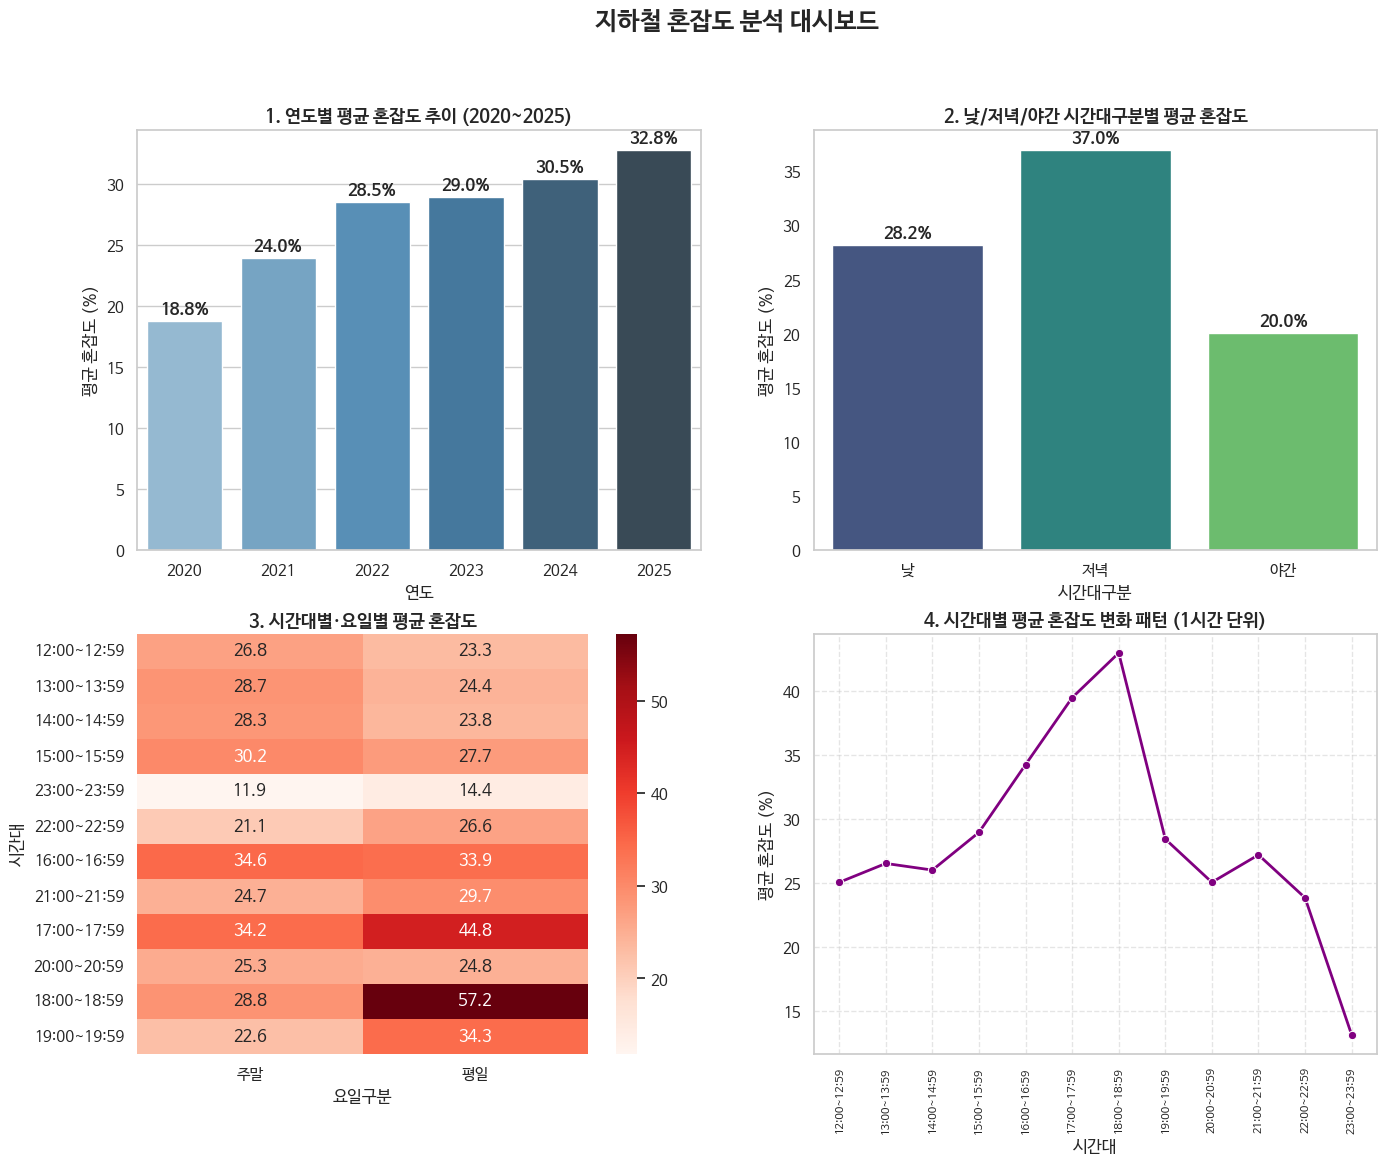

In [ ]:
# 시간대 정렬용 순서 정의 (12:00 ~ 00:00 순서)
time_order = {
    '12:00~12:59': 1,
    '13:00~13:59': 2,
    '14:00~14:59': 3,
    '15:00~15:59': 4,
    '16:00~16:59': 5,
    '17:00~17:59': 6,
    '18:00~18:59': 7,
    '19:00~19:59': 8,
    '20:00~20:59': 9,
    '21:00~21:59': 10,
    '22:00~22:59': 11,
    '23:00~23:59': 12,
}

congestion_df['정렬순서'] = congestion_df['시간대'].map(time_order)
sports_df['정렬순서'] = sports_df['시간대'].map(time_order)

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "지하철 혼잡도 분석 대시보드", fontsize=18, fontweight='bold', y=0.98
)

# 1. 연도별 평균 혼잡도 추이 (막대 그래프)
sns.barplot(
    data=congestion_df,
    x='연도',
    y='혼잡도',
    ax=axes[0, 0],
    palette='Blues_d',
    errorbar=None,
)
axes[0, 0].set_title(
    "1. 연도별 평균 혼잡도 추이 (2020~2025)", fontsize=13, fontweight='bold'
)
axes[0, 0].set_xlabel("연도")
axes[0, 0].set_ylabel("평균 혼잡도 (%)")

# 수치 텍스트 표기
for p in axes[0, 0].patches:
  axes[0, 0].annotate(
      f'{p.get_height():.1f}%',
      (p.get_x() + p.get_width() / 2., p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 8),
      textcoords='offset points',
      fontweight='bold',
  )


# 2. 시간대구분(낮/저녁/야간)별 평균 혼잡도
cat_order = ['낮', '저녁', '야간']
cat_avg = (
    sports_df.groupby('시간대구분')['혼잡도']
    .mean()
    .reindex(cat_order)
    .reset_index()
)

ax2 = axes[0, 1]
bars = sns.barplot(
    data=cat_avg,
    x='시간대구분',
    y='혼잡도',
    order=cat_order,
    palette='viridis',
    errorbar=None,
    ax=ax2,
)

for p in ax2.patches:
  ax2.annotate(
      f'{p.get_height():.1f}%',
      (p.get_x() + p.get_width() / 2., p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 8),
      textcoords='offset points',
      fontweight='bold',
  )

ax2.set_title(
    "2. 낮/저녁/야간 시간대구분별 평균 혼잡도", fontsize=13, fontweight='bold'
)
ax2.set_xlabel("시간대구분")
ax2.set_ylabel("평균 혼잡도 (%)")
ax2.grid(False)


# 3. 시간대별, 요일별 평균 혼잡도 히트맵 (정렬 적용)
heatmap_data = (
    congestion_df.groupby(['시간대', '정렬순서', '요일구분'])['혼잡도']
    .mean()
    .reset_index()
)
heatmap_pivot = heatmap_data.sort_values('정렬순서').pivot_table(
    index='시간대', columns='요일구분', values='혼잡도', sort=False
)

sns.heatmap(heatmap_pivot, cmap='Reds', annot=True, fmt='.1f', ax=axes[1, 0])
axes[1, 0].set_title(
    "3. 시간대별·요일별 평균 혼잡도", fontsize=13, fontweight='bold'
)
axes[1, 0].set_xlabel("요일구분")
axes[1, 0].set_ylabel("시간대")


# 4. 시간대별 평균 혼잡도 변화 패턴 (정렬 적용)
time_avg = (
    congestion_df.groupby(['시간대', '정렬순서'])['혼잡도']
    .mean()
    .reset_index()
    .sort_values('정렬순서')
)

sns.lineplot(
    data=time_avg,
    x='시간대',
    y='혼잡도',
    ax=axes[1, 1],
    marker='o',
    color='purple',
    linewidth=2,
    sort=False,
)
axes[1, 1].set_title(
    "4. 시간대별 평균 혼잡도 변화 패턴 (1시간 단위)", fontsize=13, fontweight='bold'
)
axes[1, 1].set_xlabel("시간대")
axes[1, 1].set_ylabel("평균 혼잡도 (%)")
axes[1, 1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.show()
plt.close()

/tmp/ipykernel_146190/108010696.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_146190/108010696.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sports_df.groupby(['시간대', '정렬순서', '요일구분'])['혼잡도']
/tmp/ipykernel_146190/108010696.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sports_df.groupby(['시간대', '정렬순서', '상하구분'])['혼잡도']


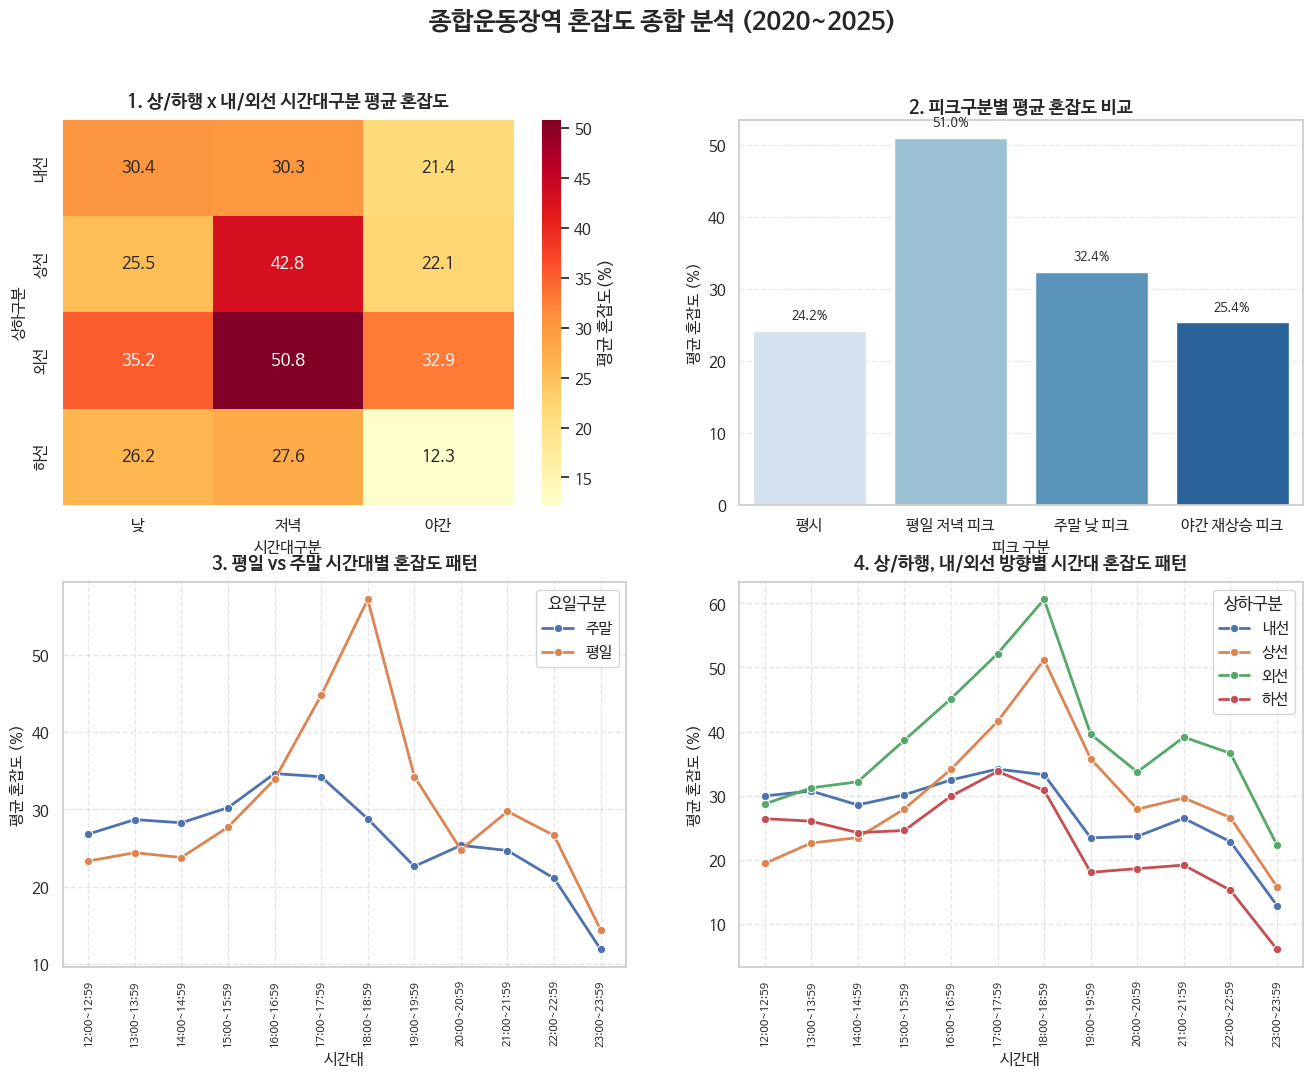

In [ ]:
# 2x2 서브플롯 틀 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "종합운동장역 혼잡도 종합 분석 (2020~2025)",
    fontsize=18,
    fontweight='bold',
    y=0.98,
)

# 1. 상/하행 방향별 x 시간대구분 히트맵
cat_order = ['낮', '저녁', '야간']  # 시간대구분 순서 정의
pivot = sports_df.pivot_table(
    index='상하구분', columns='시간대구분', values='혼잡도', aggfunc='mean'
)

# 존재하지 않는 컬럼 예외 처리 및 순서 지정
cat_order_exist = [c for c in cat_order if c in pivot.columns]
pivot = pivot[cat_order_exist]

ax1 = axes[0, 0]
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax1,
    cbar_kws={'label': '평균 혼잡도(%)'},
)
ax1.set_title(
    "1. 상/하행 x 내/외선 시간대구분 평균 혼잡도", fontsize=13, fontweight='bold', pad=10
)
ax1.set_xlabel("시간대구분", fontsize=11)
ax1.set_ylabel("상하구분", fontsize=11)


# 2. 피크구분별 평균 혼잡도
peak_avg = (
    congestion_df
    .groupby('피크구분')['혼잡도']
    .mean()
    .reindex(['평시', '평일 저녁 피크', '주말 낮 피크', '야간 재상승 피크'])
    .reset_index()
)

sns.barplot(
    data=peak_avg,
    x='피크구분',
    y='혼잡도',
    ax=axes[0, 1],
    palette='Blues'
)

axes[0, 1].set_title(
    "2. 피크구분별 평균 혼잡도 비교",
    fontsize=13,
    fontweight='bold'
)
axes[0, 1].set_xlabel("피크 구분", fontsize=11)
axes[0, 1].set_ylabel("평균 혼잡도 (%)", fontsize=11)

# 값 표시
for p in axes[0, 1].patches:
    axes[0, 1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 5),
        textcoords='offset points'
    )

axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)



# 3. 평일 vs 주말 시간대별 패턴
wd_time = (
    sports_df.groupby(['시간대', '정렬순서', '요일구분'])['혼잡도']
    .mean()
    .reset_index()
)
wd_time = wd_time.sort_values('정렬순서')

ax3 = axes[1, 0]
sns.lineplot(
    data=wd_time,
    x='시간대',
    y='혼잡도',
    hue='요일구분',
    marker='o',
    linewidth=2,
    ax=ax3,
    sort=False,
)
ax3.set_title(
    "3. 평일 vs 주말 시간대별 혼잡도 패턴", fontsize=13, fontweight='bold', pad=10
)
ax3.set_xlabel("시간대", fontsize=11)
ax3.set_ylabel("평균 혼잡도 (%)", fontsize=11)
ax3.tick_params(axis='x', rotation=90, labelsize=8)
ax3.grid(True, linestyle='--', alpha=0.5)


# 4. 상/하행 방향별 시간대 혼잡도
dir_time = (
    sports_df.groupby(['시간대', '정렬순서', '상하구분'])['혼잡도']
    .mean()
    .reset_index()
)
dir_time = dir_time.sort_values('정렬순서')

ax4 = axes[1, 1]
sns.lineplot(
    data=dir_time,
    x='시간대',
    y='혼잡도',
    hue='상하구분',
    marker='o',
    linewidth=2,
    ax=ax4,
    sort=False,
)
ax4.set_title(
    "4. 상/하행, 내/외선 방향별 시간대 혼잡도 패턴", fontsize=13, fontweight='bold', pad=10
)
ax4.set_xlabel("시간대", fontsize=11)
ax4.set_ylabel("평균 혼잡도 (%)", fontsize=11)
ax4.tick_params(axis='x', rotation=90, labelsize=8)
ax4.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 가설 검증을 위한 2차 EDA

## 가설1

### 행사일은 동일 요일의 비행사일보다 행사 전후 시간대에 종합운동장역 승하차 인원이 많을 것이다.

### 분석 내용

대규모 행사 종료 직후 종합운동장역의 승차 인원이 평소보다 증가하는지 확인한다. 행사일과 비행사일의 승차 수요 차이를 탐색적으로 비교한다.



In [ ]:
# 4차 통합 파일
integration_df = pd.read_csv(f'{base_path}/data/4차통합.csv')
# 혼잡도 파일
congestion_df = pd.read_csv(f'{base_path}/data/혼잡도_통합_v2.csv')

/tmp/ipykernel_146190/1434107963.py:2: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  integration_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


In [ ]:
# 두개의 나눠져 있는 파일의 코드가 꼬여서 변수 새로 생성.
comb_df = pd.read_csv(f'{base_path}/data/4차통합.csv')
cong_df = pd.read_csv(f'{base_path}/data/혼잡도_통합_v2.csv')

/tmp/ipykernel_146190/1356948300.py:2: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  comb_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


#### 전처리

In [ ]:
# 불필요한 컬럼 삭제
integration_df = integration_df.drop(columns=['Unnamed: 0'])

In [ ]:
# 코로나 시기로 2020, 2021년은 포함하지 않기로 했지만 비교를 위해서 dataframe 추가 생성.
# integration_df : 코로나 포함 integration_covid_x_df: 미포함
integration_covid_x_df = integration_df[integration_df['연도'].between(2022, 2025)].copy()

comb_df2 = comb_df.loc[comb_df['연도'] > 2021]

In [ ]:
integration_covid_x_df.columns

Index(['통합연번', '수송일자', '연도', '호선', '역번호', '역명', '승하차구분', '역ID', '역명_표준',
       '음수이상치여부', '월', '일', '요일번호', '요일', '공휴일여부', '요일구분', '시간대', '승하차인원',
       '피크타임', '시간대구분', '측정시작시간', '측정종료시간', '날짜', '제목', '분야명', '최초시작시간',
       '최종종료시간', '행사수'],
      dtype='object')

In [ ]:
# 수송일자 타입 변경
integration_df['수송일자'] = pd.to_datetime(integration_df['수송일자'])
integration_covid_x_df['수송일자'] = pd.to_datetime(integration_covid_x_df['수송일자'])

In [ ]:
event_columns = ['수송일자', '제목', '분야명', '최초시작시간', '최종종료시간', '행사수']

event_info = integration_covid_x_df[integration_covid_x_df['제목'].notna()][event_columns].drop_duplicates('수송일자').copy()

# 행사 시작, 종료 시각 생성

event_info['시작시'] = event_info['최초시작시간'].astype(str).str.split(':').str[0].astype(int)
event_info['종료시'] = event_info['최종종료시간'].astype(str).str.split(':').str[0].astype(int)
event_info['종료분'] = event_info['최종종료시간'].astype(str).str.split(':').str[1].astype(int)

event_info[['수송일자', '제목', '최초시작시간', '최종종료시간', '시작시', '종료시', '종료분']].head()

,수송일자,제목,최초시작시간,최종종료시간,시작시,종료시,종료분
80990,2022-11-05,태양의 써커스,12:30:00,14:40:00,12,14,40
81004,2022-11-12,태양의 써커스,12:30:00,14:40:00,12,14,40
81018,2022-11-19,태양의 써커스,12:30:00,14:40:00,12,14,40
81032,2022-11-26,태양의 써커스,12:30:00,14:40:00,12,14,40
81046,2022-12-03,태양의 써커스,12:30:00,14:40:00,12,14,40


In [ ]:
integration_covid_x_df = integration_covid_x_df.drop(columns=['제목', '분야명', '최초시작시간', '최종종료시간', '행사수'])
integration_covid_x_df = integration_covid_x_df.merge(event_info, on='수송일자', how='left')

In [ ]:
# 시간대 정렬
time_order = [
    '06시이전', '06-07시간대', '07-08시간대', '08-09시간대',
    '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
    '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대',
    '17-18시간대', '18-19시간대', '19-20시간대', '20-21시간대',
    '21-22시간대', '22-23시간대', '23-24시간대', '24시이후'
]

time_hour = {
    '06시이전': 5,
    '06-07시간대': 6,
    '07-08시간대': 7,
    '08-09시간대': 8,
    '09-10시간대': 9,
    '10-11시간대': 10,
    '11-12시간대': 11,
    '12-13시간대': 12,
    '13-14시간대': 13,
    '14-15시간대': 14,
    '15-16시간대': 15,
    '16-17시간대': 16,
    '17-18시간대': 17,
    '18-19시간대': 18,
    '19-20시간대': 19,
    '20-21시간대': 20,
    '21-22시간대': 21,
    '22-23시간대': 22,
    '23-24시간대': 23,
    '24시이후': 24
}

comb_df['시간대'] = pd.Categorical(comb_df['시간대'], categories=time_order, ordered=True)
comb_df2['시간대'] = pd.Categorical(comb_df2['시간대'], categories=time_order, ordered=True)


integration_df['시간대'] = pd.Categorical(
    integration_df['시간대'], categories=time_order, ordered=True)
integration_covid_x_df['시간대'] = pd.Categorical(
    integration_covid_x_df['시간대'], categories=time_order, ordered=True)

integration_df['시간대시작'] = integration_df['시간대'].map(time_hour)
integration_covid_x_df['시간대시작'] = integration_covid_x_df['시간대'].map(time_hour)



/tmp/ipykernel_146190/457428231.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comb_df2['시간대'] = pd.Categorical(comb_df2['시간대'], categories=time_order, ordered=True)


In [ ]:
# 요일 정렬
day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

integration_df['요일'] = pd.Categorical(
    integration_df['요일'], categories=day_order, ordered=True)

integration_covid_x_df['요일'] = pd.Categorical(
    integration_covid_x_df['요일'], categories=day_order, ordered=True)

comb_df['요일'] = pd.Categorical(comb_df['요일'], categories=day_order, ordered=True)
comb_df2['요일'] = pd.Categorical(comb_df2['요일'], categories=day_order, ordered=True)

/tmp/ipykernel_146190/703559127.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comb_df2['요일'] = pd.Categorical(comb_df2['요일'], categories=day_order, ordered=True)


In [ ]:
# 행사여부 컬럼 생성
integration_df['행사여부'] = np.where(integration_df['제목'].notna(), '행사일', '비행사일')
integration_covid_x_df['행사여부'] = np.where(integration_covid_x_df['제목'].notna(), '행사일', '비행사일')

comb_df['행사여부'] = np.where(comb_df['제목'].notna(), '행사일', '비행사일')
comb_df2['행사여부'] = np.where(comb_df2['제목'].notna(), '행사일', '비행사일')

/tmp/ipykernel_146190/2014829006.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comb_df2['행사여부'] = np.where(comb_df2['제목'].notna(), '행사일', '비행사일')


In [ ]:
# 코로나 포함 o
group_df = comb_df.groupby(['날짜', '요일', '행사여부', '시간대', '호선'], dropna=False).agg({'승하차인원': 'mean'}).reset_index()
# 코로나 포함 x
group_df2 = comb_df2.groupby(['날짜', '요일', '행사여부', '시간대', '호선'], dropna=False).agg({'승하차인원': 'mean'}).reset_index()

/tmp/ipykernel_146190/3065698710.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_df = comb_df.groupby(['날짜', '요일', '행사여부', '시간대', '호선'], dropna=False).agg({'승하차인원': 'mean'}).reset_index()
/tmp/ipykernel_146190/3065698710.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_df2 = comb_df2.groupby(['날짜', '요일', '행사여부', '시간대', '호선'], dropna=False).agg({'승하차인원': 'mean'}).reset_index()


#### 연도별 행사/비행사 수 확인

In [ ]:
date_count = (
    integration_covid_x_df[['수송일자', '연도', '행사여부']]
    .drop_duplicates()
    .groupby(['연도', '행사여부'], observed=True)
    .size()
    .unstack(fill_value=0)
)

date_count

행사여부,비행사일,행사일
연도,,
2022,152,213
2023,148,217
2024,148,218
2025,150,215


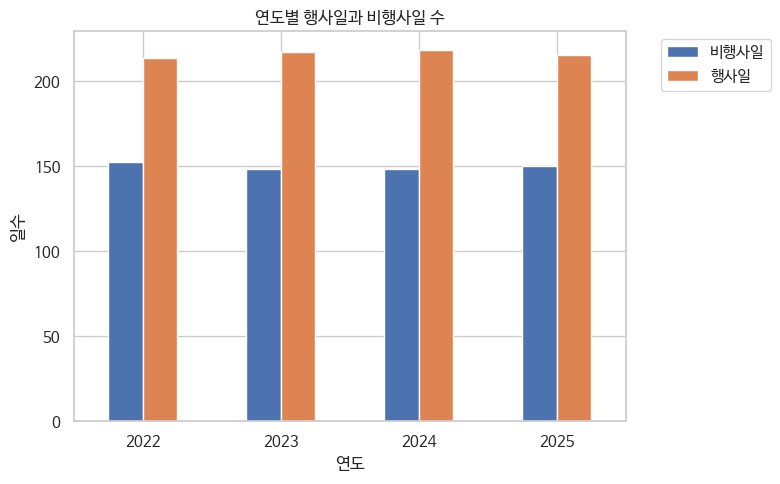

In [ ]:
date_count.plot(kind='bar', figsize=(8, 5))

plt.title('연도별 행사일과 비행사일 수')
plt.xlabel('연도')
plt.ylabel('일수')
plt.xticks(rotation=0)
plt.legend(title='', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#### 요일별/시간대별 2호선 평균 승하차량

/tmp/ipykernel_146190/4256477124.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2_thu = group_df2[(group_df['요일'] == '목요일') & (group_df2['호선'] == '2호선')]
/tmp/ipykernel_146190/4256477124.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2_fri = group_df2[(group_df['요일'] == '금요일') & (group_df2['호선'] == '2호선')]
/tmp/ipykernel_146190/4256477124.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2_sat = group_df2[(group_df['요일'] == '토요일') & (group_df2['호선'] == '2호선')]
/tmp/ipykernel_146190/4256477124.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2_sun = group_df2[(group_df['요일'] == '일요일') & (group_df2['호선'] == '2호선')]


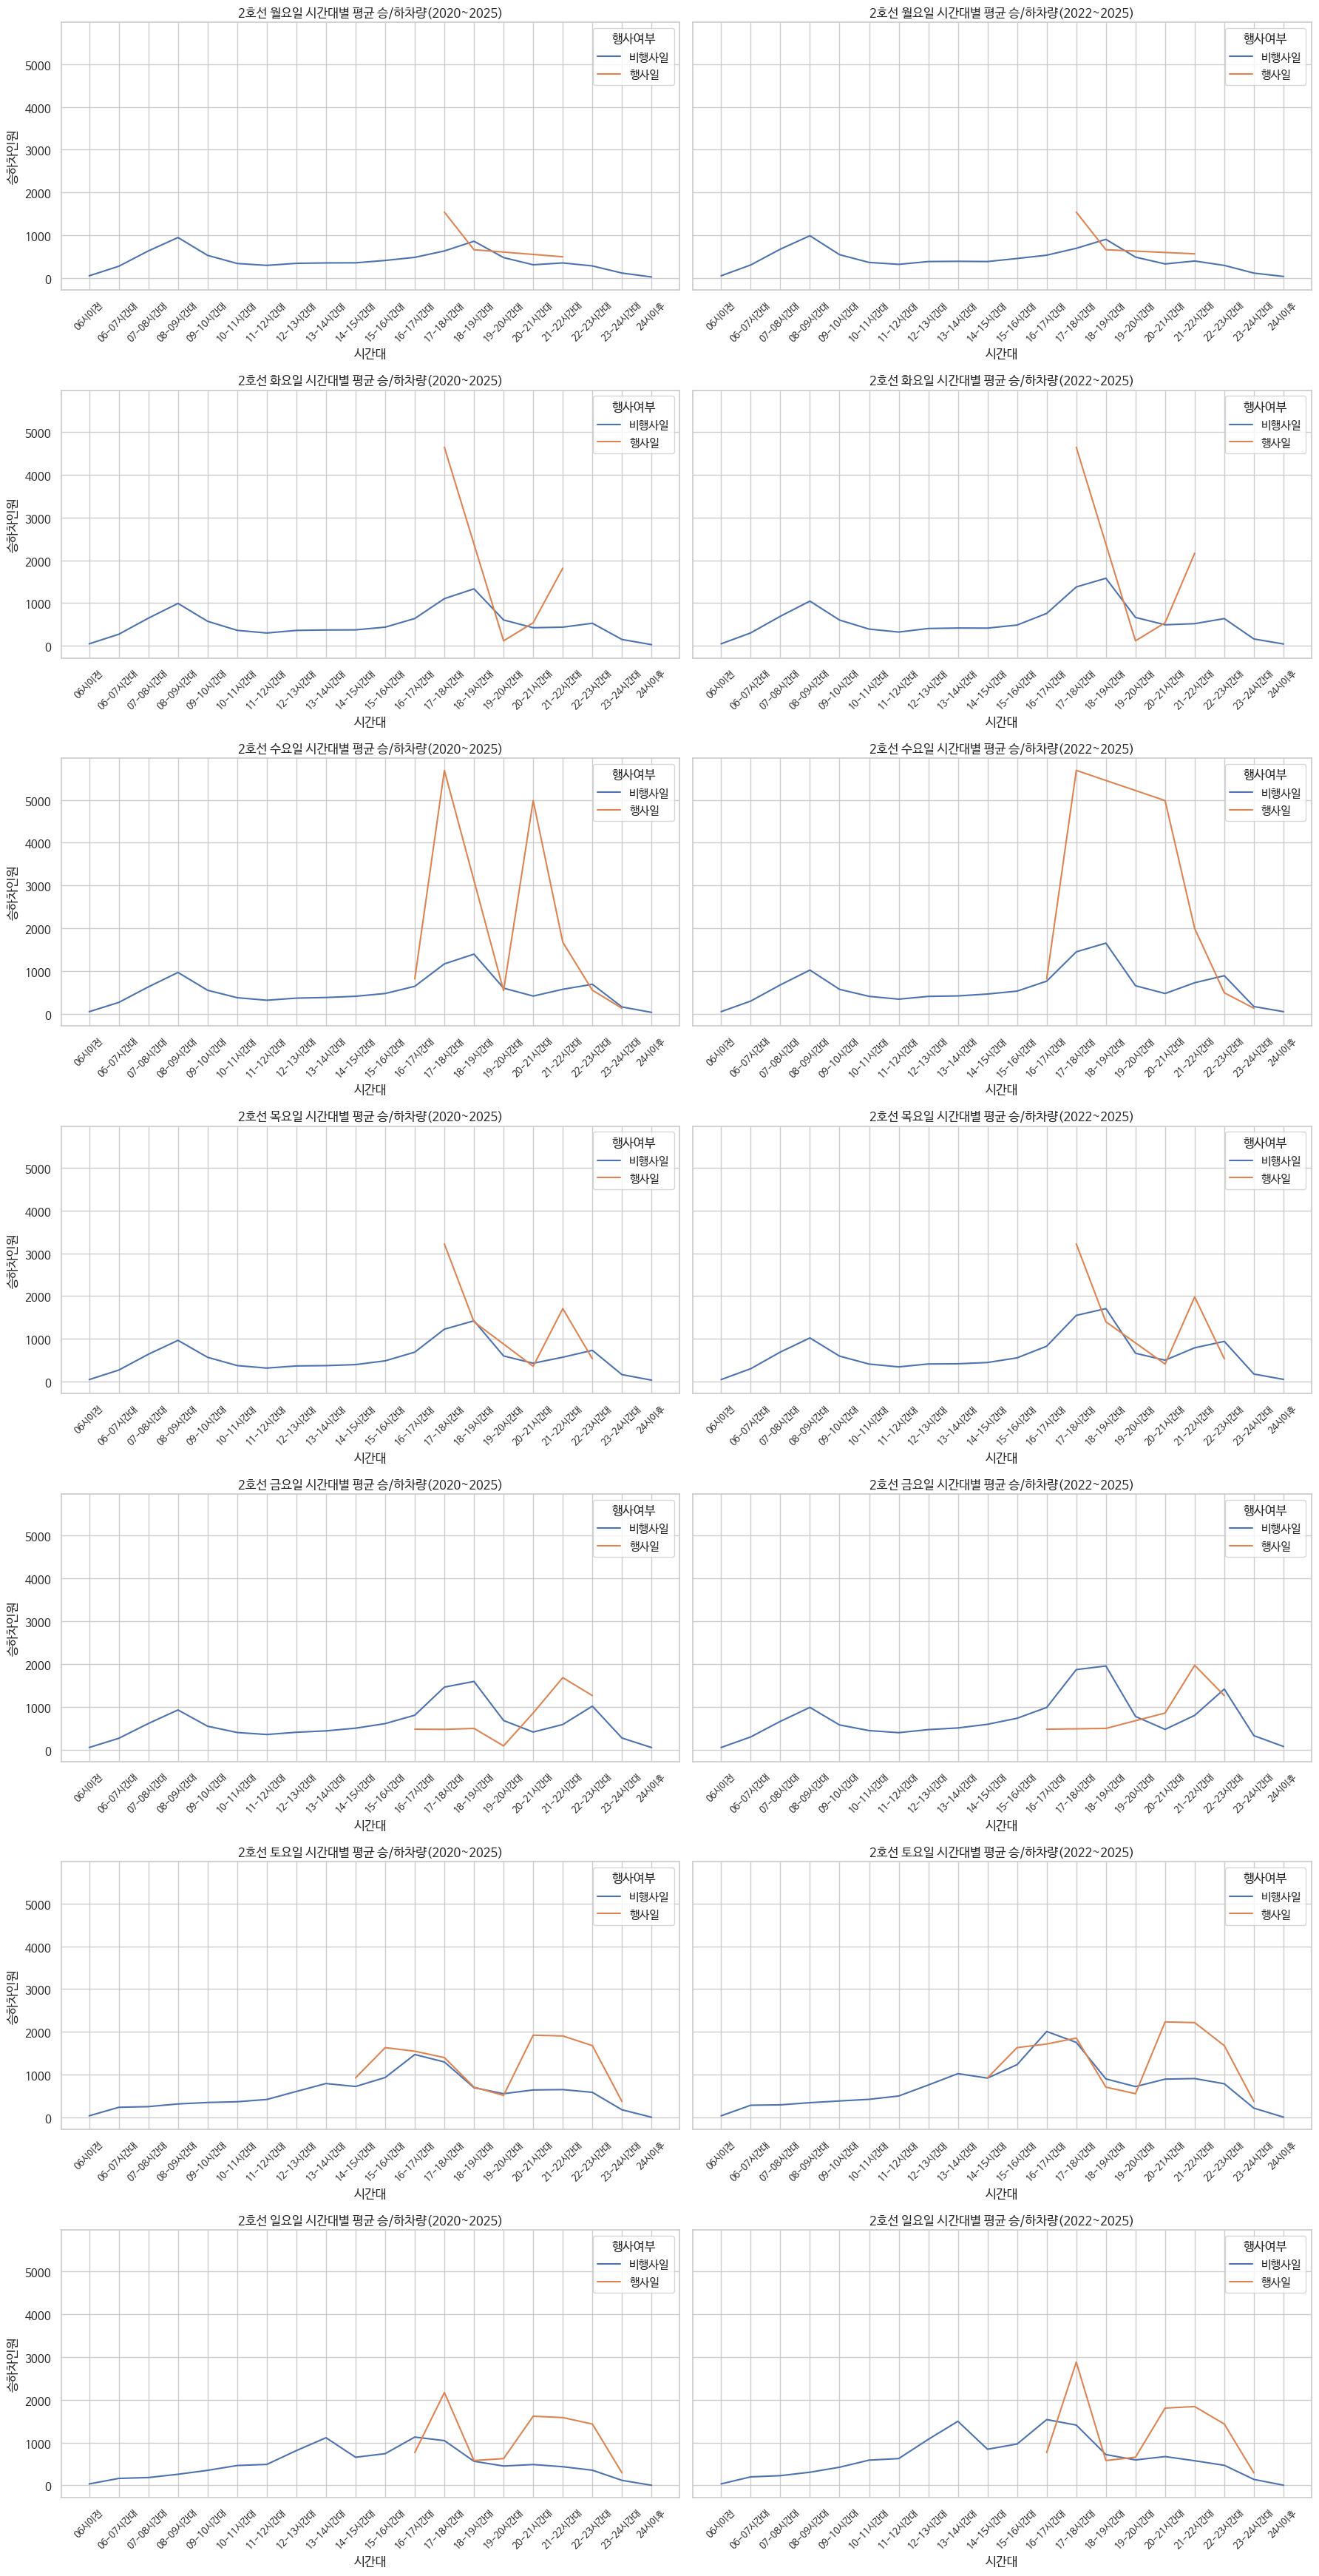

In [ ]:
fig, axes = plt.subplots(7, 2, figsize=(18, 35), sharey=True)

# 요일별 데이터 필터링
df_mon = group_df[(group_df['요일'] == '월요일') & (group_df['호선'] == '2호선')]
df_tue = group_df[(group_df['요일'] == '화요일') & (group_df['호선'] == '2호선')]
df_wed = group_df[(group_df['요일'] == '수요일') & (group_df['호선'] == '2호선')]
df_thu = group_df[(group_df['요일'] == '목요일') & (group_df['호선'] == '2호선')]
df_fri = group_df[(group_df['요일'] == '금요일') & (group_df['호선'] == '2호선')]
df_sat = group_df[(group_df['요일'] == '토요일') & (group_df['호선'] == '2호선')]
df_sun = group_df[(group_df['요일'] == '일요일') & (group_df['호선'] == '2호선')]

# 코로나 (2020~2021) 미포함
df2_mon = group_df2[(group_df2['요일'] == '월요일') & (group_df2['호선'] == '2호선')]
df2_tue = group_df2[(group_df2['요일'] == '화요일') & (group_df2['호선'] == '2호선')]
df2_wed = group_df2[(group_df2['요일'] == '수요일') & (group_df2['호선'] == '2호선')]
df2_thu = group_df2[(group_df['요일'] == '목요일') & (group_df2['호선'] == '2호선')]
df2_fri = group_df2[(group_df['요일'] == '금요일') & (group_df2['호선'] == '2호선')]
df2_sat = group_df2[(group_df['요일'] == '토요일') & (group_df2['호선'] == '2호선')]
df2_sun = group_df2[(group_df['요일'] == '일요일') & (group_df2['호선'] == '2호선')]

sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_mon, ax=axes[0,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_tue, ax=axes[1,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_wed, ax=axes[2,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_thu, ax=axes[3,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_fri, ax=axes[4,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_sat, ax=axes[5,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_sun, ax=axes[6,0], errorbar=None)

# 코로나 (2020~2021) 미포함
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_mon, ax=axes[0,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_tue, ax=axes[1,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_wed, ax=axes[2,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_thu, ax=axes[3,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_fri, ax=axes[4,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_sat, ax=axes[5,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_sun, ax=axes[6,1], errorbar=None)

axes[0,0].set_title('2호선 월요일 시간대별 평균 승/하차량(2020~2025)')
axes[1,0].set_title('2호선 화요일 시간대별 평균 승/하차량(2020~2025)')
axes[2,0].set_title('2호선 수요일 시간대별 평균 승/하차량(2020~2025)')
axes[3,0].set_title('2호선 목요일 시간대별 평균 승/하차량(2020~2025)')
axes[4,0].set_title('2호선 금요일 시간대별 평균 승/하차량(2020~2025)')
axes[5,0].set_title('2호선 토요일 시간대별 평균 승/하차량(2020~2025)')
axes[6,0].set_title('2호선 일요일 시간대별 평균 승/하차량(2020~2025)')

axes[0,1].set_title('2호선 월요일 시간대별 평균 승/하차량(2022~2025)')
axes[1,1].set_title('2호선 화요일 시간대별 평균 승/하차량(2022~2025)')
axes[2,1].set_title('2호선 수요일 시간대별 평균 승/하차량(2022~2025)')
axes[3,1].set_title('2호선 목요일 시간대별 평균 승/하차량(2022~2025)')
axes[4,1].set_title('2호선 금요일 시간대별 평균 승/하차량(2022~2025)')
axes[5,1].set_title('2호선 토요일 시간대별 평균 승/하차량(2022~2025)')
axes[6,1].set_title('2호선 일요일 시간대별 평균 승/하차량(2022~2025)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.show()

#### 요일별/시간대별 9호선 평균 승하차량

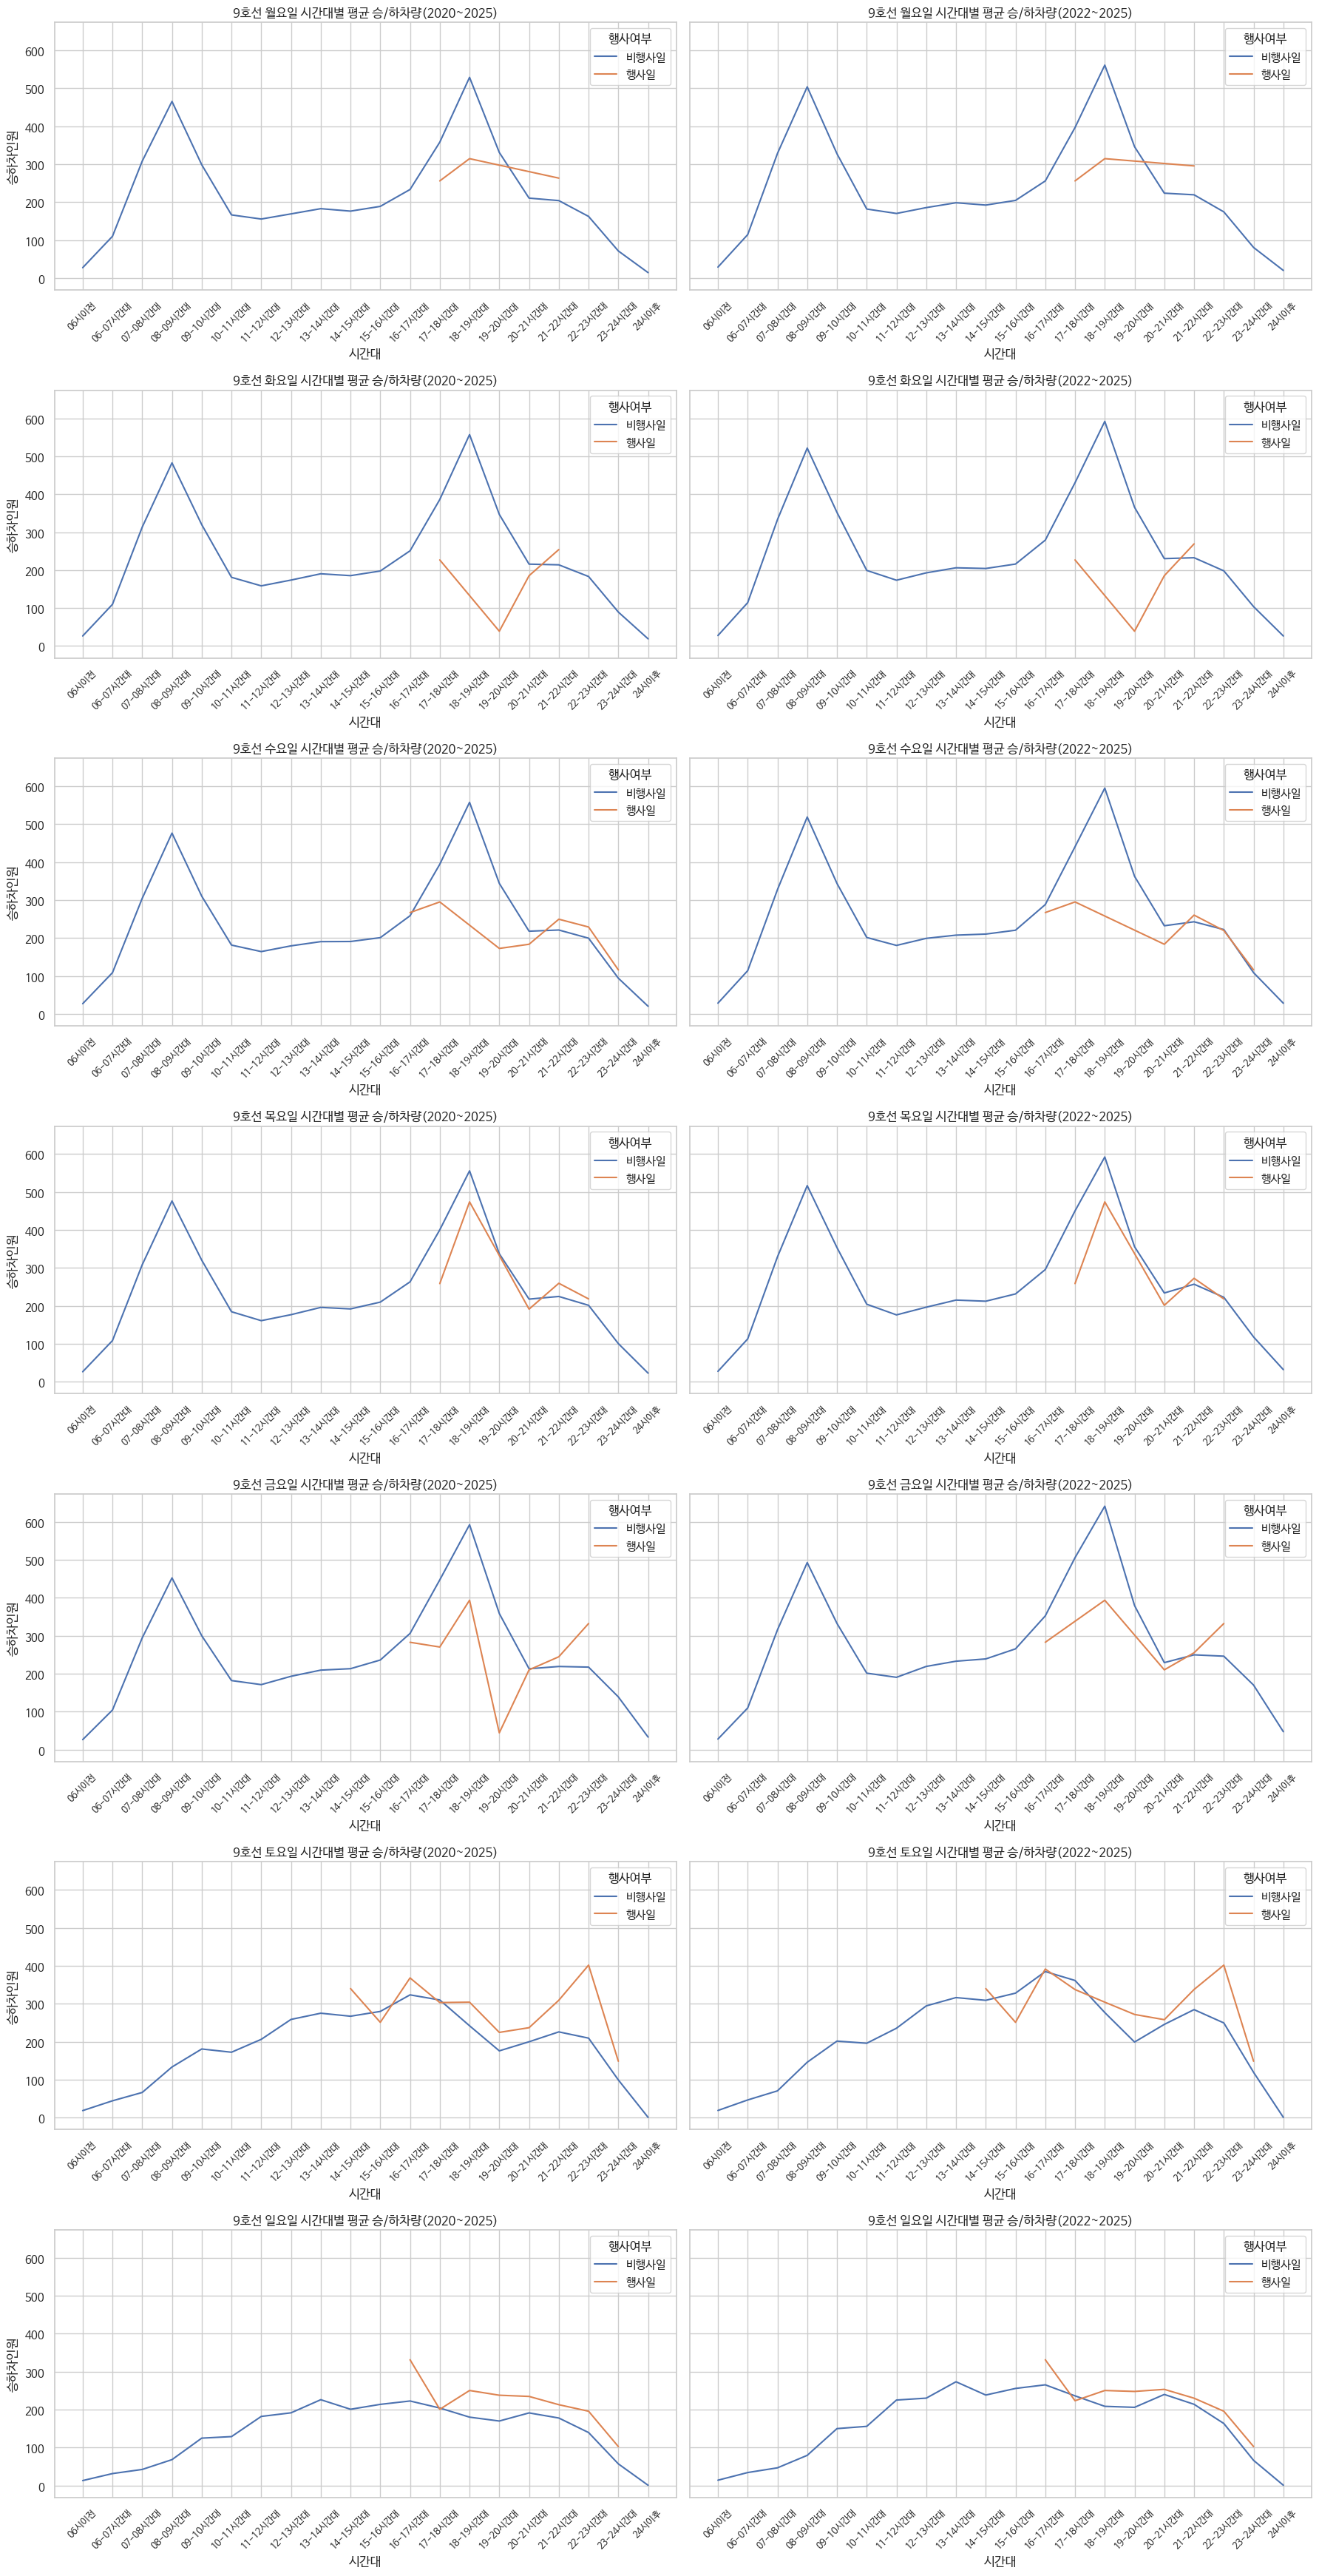

In [ ]:
fig, axes = plt.subplots(7, 2, figsize=(18, 35), sharey=True)

# 요일별 데이터 필터링
df_mon = group_df[(group_df['요일'] == '월요일') & (group_df['호선'] == '9호선')]
df_tue = group_df[(group_df['요일'] == '화요일') & (group_df['호선'] == '9호선')]
df_wed = group_df[(group_df['요일'] == '수요일') & (group_df['호선'] == '9호선')]
df_thu = group_df[(group_df['요일'] == '목요일') & (group_df['호선'] == '9호선')]
df_fri = group_df[(group_df['요일'] == '금요일') & (group_df['호선'] == '9호선')]
df_sat = group_df[(group_df['요일'] == '토요일') & (group_df['호선'] == '9호선')]
df_sun = group_df[(group_df['요일'] == '일요일') & (group_df['호선'] == '9호선')]

# 코로나 (2020~2021) 미포함
df2_mon = group_df2[(group_df2['요일'] == '월요일') & (group_df2['호선'] == '9호선')]
df2_tue = group_df2[(group_df2['요일'] == '화요일') & (group_df2['호선'] == '9호선')]
df2_wed = group_df2[(group_df2['요일'] == '수요일') & (group_df2['호선'] == '9호선')]
df2_thu = group_df2[(group_df2['요일'] == '목요일') & (group_df2['호선'] == '9호선')]
df2_fri = group_df2[(group_df2['요일'] == '금요일') & (group_df2['호선'] == '9호선')]
df2_sat = group_df2[(group_df2['요일'] == '토요일') & (group_df2['호선'] == '9호선')]
df2_sun = group_df2[(group_df2['요일'] == '일요일') & (group_df2['호선'] == '9호선')]

sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_mon, ax=axes[0,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_tue, ax=axes[1,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_wed, ax=axes[2,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_thu, ax=axes[3,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_fri, ax=axes[4,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_sat, ax=axes[5,0], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df_sun, ax=axes[6,0], errorbar=None)

# 코로나 (2020~2021) 미포함
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_mon, ax=axes[0,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_tue, ax=axes[1,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_wed, ax=axes[2,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_thu, ax=axes[3,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_fri, ax=axes[4,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_sat, ax=axes[5,1], errorbar=None)
sns.lineplot(x='시간대', y='승하차인원', hue='행사여부', data=df2_sun, ax=axes[6,1], errorbar=None)

axes[0,0].set_title('9호선 월요일 시간대별 평균 승/하차량(2020~2025)')
axes[1,0].set_title('9호선 화요일 시간대별 평균 승/하차량(2020~2025)')
axes[2,0].set_title('9호선 수요일 시간대별 평균 승/하차량(2020~2025)')
axes[3,0].set_title('9호선 목요일 시간대별 평균 승/하차량(2020~2025)')
axes[4,0].set_title('9호선 금요일 시간대별 평균 승/하차량(2020~2025)')
axes[5,0].set_title('9호선 토요일 시간대별 평균 승/하차량(2020~2025)')
axes[6,0].set_title('9호선 일요일 시간대별 평균 승/하차량(2020~2025)')

axes[0,1].set_title('9호선 월요일 시간대별 평균 승/하차량(2022~2025)')
axes[1,1].set_title('9호선 화요일 시간대별 평균 승/하차량(2022~2025)')
axes[2,1].set_title('9호선 수요일 시간대별 평균 승/하차량(2022~2025)')
axes[3,1].set_title('9호선 목요일 시간대별 평균 승/하차량(2022~2025)')
axes[4,1].set_title('9호선 금요일 시간대별 평균 승/하차량(2022~2025)')
axes[5,1].set_title('9호선 토요일 시간대별 평균 승/하차량(2022~2025)')
axes[6,1].set_title('9호선 일요일 시간대별 평균 승/하차량(2022~2025)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.show()

#### 요일별 행사 비중

In [ ]:
# 현재 호선, 승하차 구분 컬럼에 의해 '행사여부'의 컬럼이 4개로 늘어나는 경우가 존재 => drop_duplicate와 subset 인자를 이용하여 하루 1개의 데이터를 이용하여 비교
# 이 후, 행사여부가 O인 데이터들 불러오기
unique_comb_df = comb_df2.drop_duplicates(subset=['수송일자', '측정시작시간', '측정종료시간', '제목'])
unique_comb_df = unique_comb_df[unique_comb_df['행사여부'] == '행사일']

event_count = unique_comb_df.groupby('요일').agg({
    '제목' : 'count'
}).reset_index()
event_count

/tmp/ipykernel_146190/4283319072.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  event_count = unique_comb_df.groupby('요일').agg({


,요일,제목
0,월요일,22
1,화요일,104
2,수요일,131
3,목요일,145
4,금요일,147
5,토요일,174
6,일요일,167


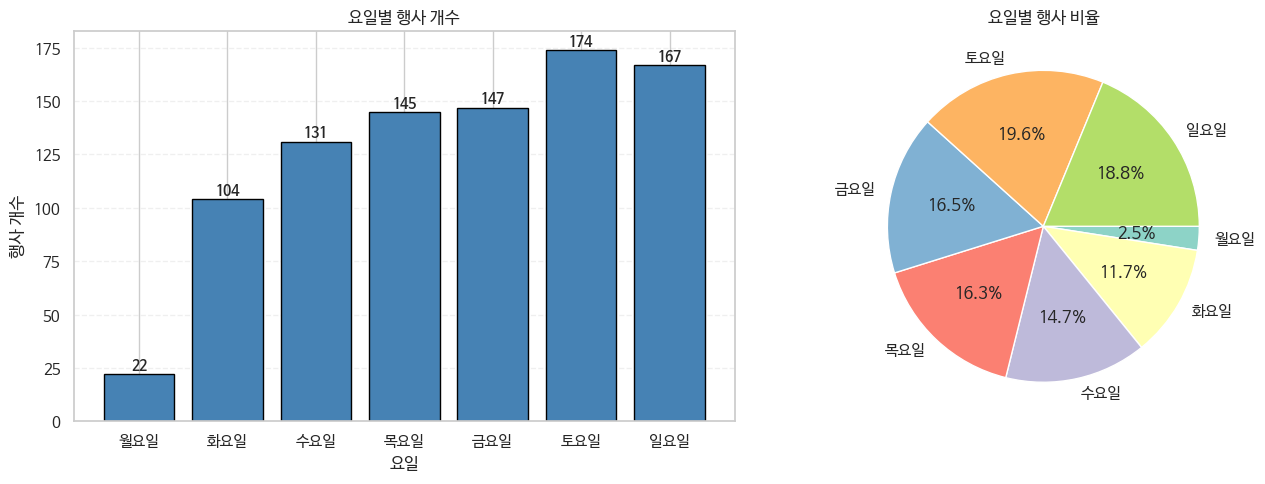

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bars = ax[0].bar(
    event_count['요일'],
    event_count['제목'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(bar.get_height())}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax[0].set_title('요일별 행사 개수')
ax[0].set_xlabel('요일')
ax[0].set_ylabel('행사 개수')
ax[0].grid(axis='y', linestyle='--', alpha=0.3)



ax[1].pie(
    event_count['제목'],
    labels=event_count['요일'],
    autopct='%.1f%%',
    counterclock=False,
    colors=plt.cm.Set3.colors
)

ax[1].set_title('요일별 행사 비율')

plt.tight_layout()
plt.show()

#### 어느 시간대에 행사가 많이 종료할까?
kde plot 사용

<Axes: xlabel='시간대', ylabel='Count'>

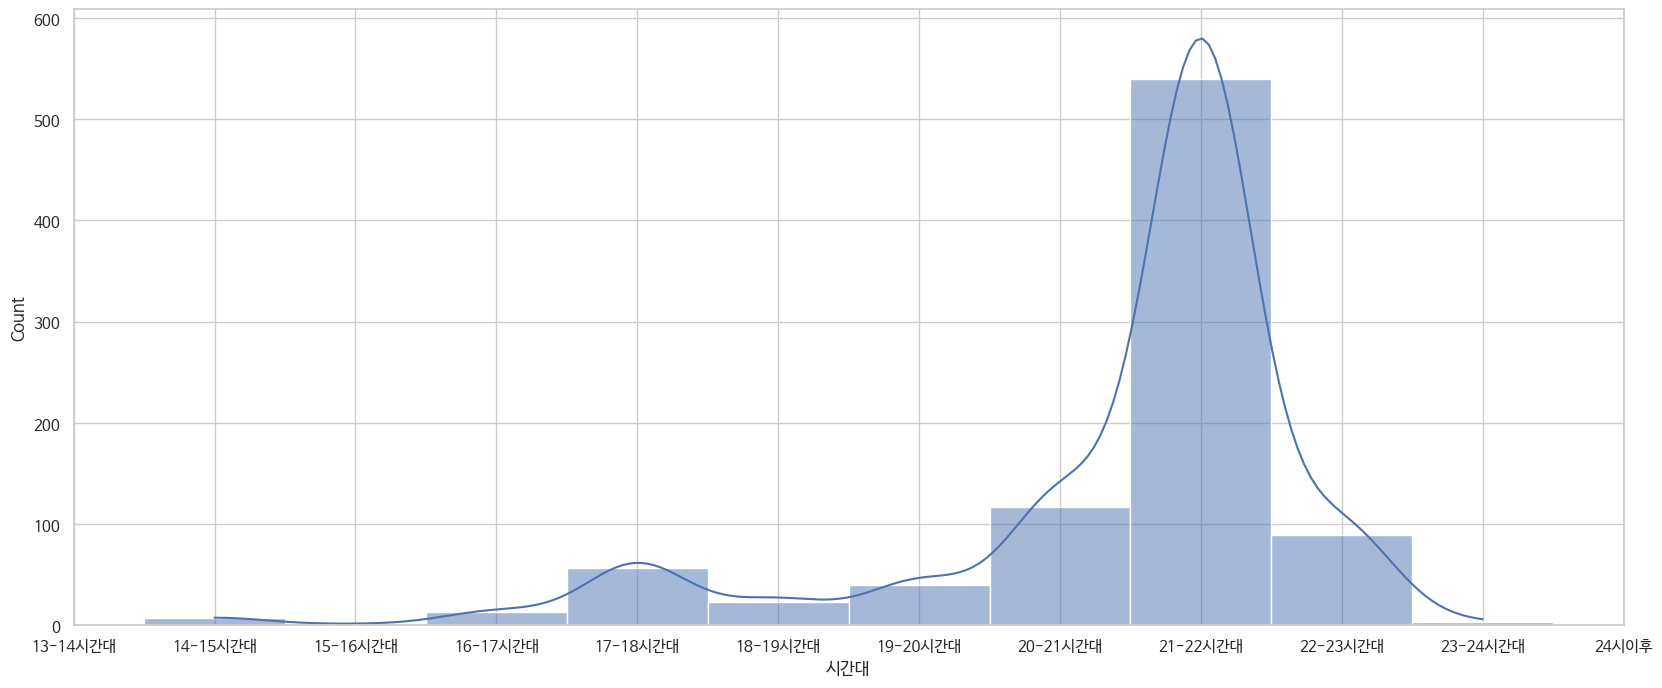

In [ ]:
plt.figure(figsize=(20,8))
sns.histplot(kde=True, data=unique_comb_df, x='시간대')

/tmp/ipykernel_146190/1297750808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_avg = integration_covid_x_df.groupby('요일')['승하차인원'].mean().reindex(['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'])


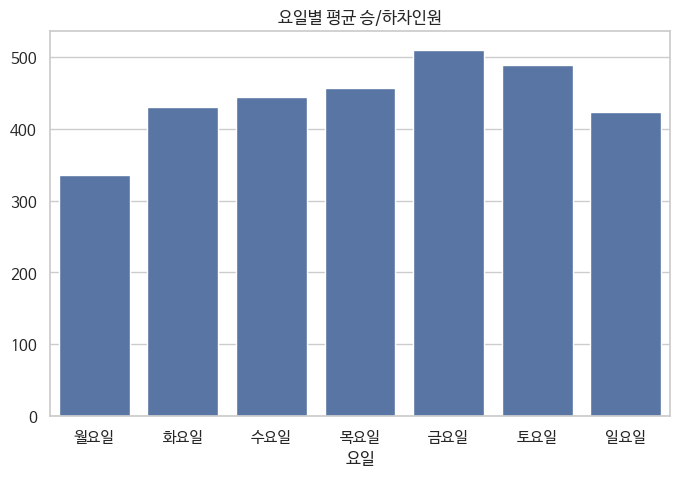

In [ ]:
daily_avg = integration_covid_x_df.groupby('요일')['승하차인원'].mean().reindex(['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'])

plt.figure(figsize=(8, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values)
plt.title('요일별 평균 승/하차인원')
plt.show()

#### 시간대별 행사일·비행사일 2호선 평균 승/하차 인원

In [ ]:
# 전체 시간대별 행사일/비행사일 평균 승하차 고객 수 비교
hourly_average = (
    integration_covid_x_df.groupby(
        ['시간대', '호선', '승하차구분', '행사여부'],
        observed=True
    )['승하차인원']
    .mean()
    .reset_index(name='평균인원')
)
hourly_average

,시간대,호선,승하차구분,행사여부,평균인원
0,06시이전,2호선,승차,비행사일,57.025084
1,06시이전,2호선,승차,행사일,54.118192
2,06시이전,2호선,하차,비행사일,38.361204
3,06시이전,2호선,하차,행사일,37.500579
4,06시이전,9호선,승차,비행사일,43.849498
...,...,...,...,...,...
155,24시이후,2호선,하차,행사일,57.531866
156,24시이후,9호선,승차,비행사일,13.697324
157,24시이후,9호선,승차,행사일,17.711472
158,24시이후,9호선,하차,비행사일,29.732441


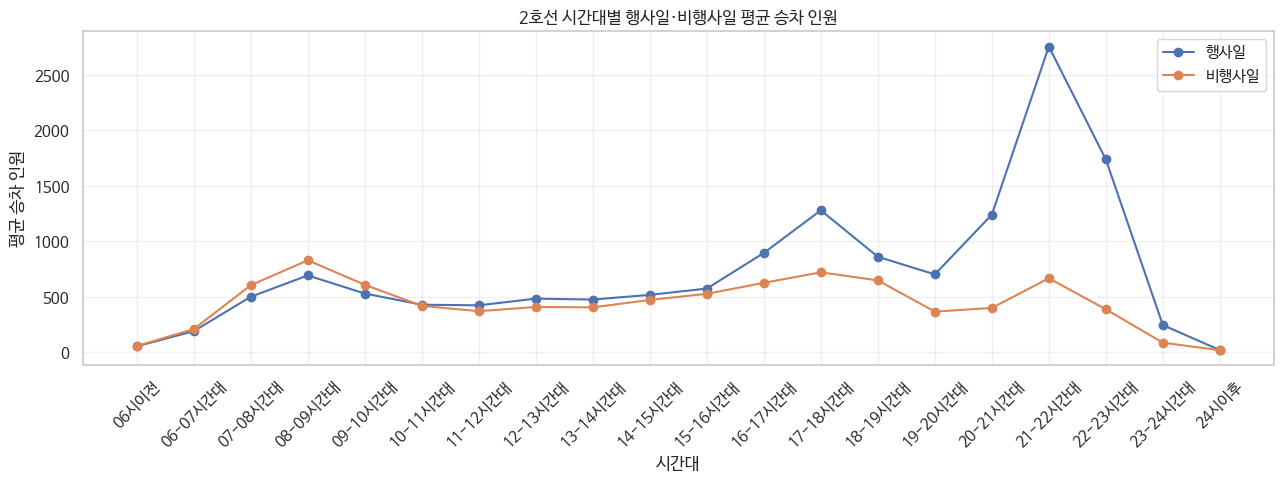

In [ ]:
# 2호선 승차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '2호선') &
    (hourly_average['승하차구분'] == '승차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('2호선 시간대별 행사일·비행사일 평균 승차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

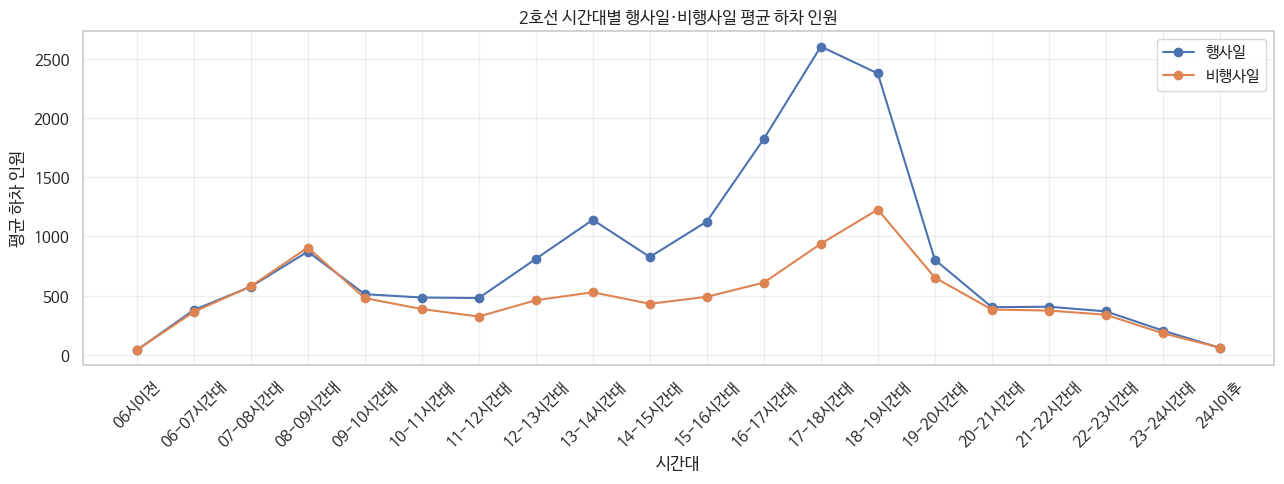

In [ ]:
# 2호선 하차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '2호선') &
    (hourly_average['승하차구분'] == '하차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('2호선 시간대별 행사일·비행사일 평균 하차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 하차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 시간대별 행사일·비행사일 9호선 평균 승/하차 인원

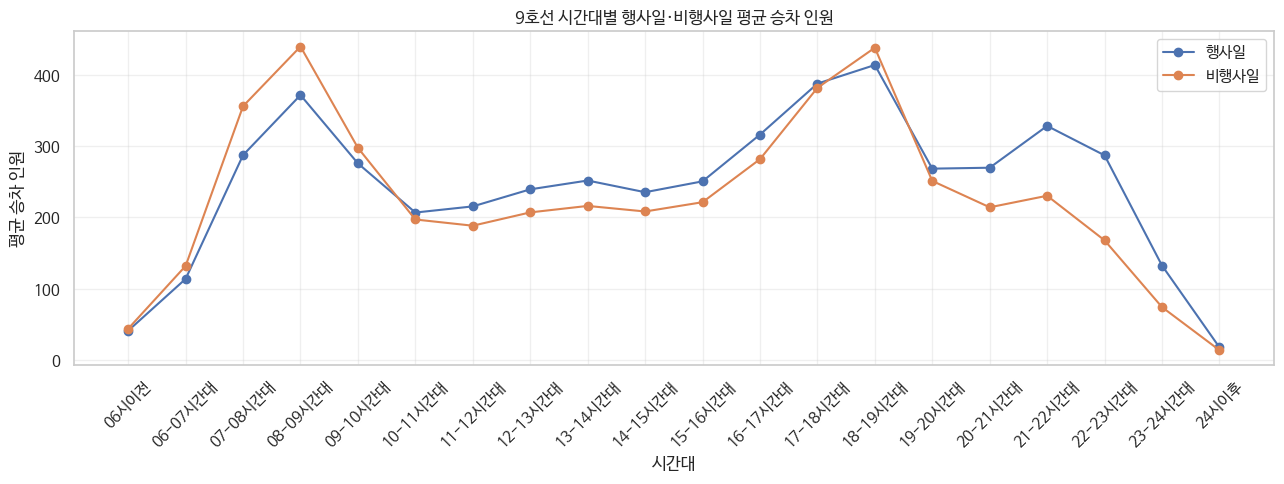

In [ ]:
# 9호선 승차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '9호선') &
    (hourly_average['승하차구분'] == '승차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('9호선 시간대별 행사일·비행사일 평균 승차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

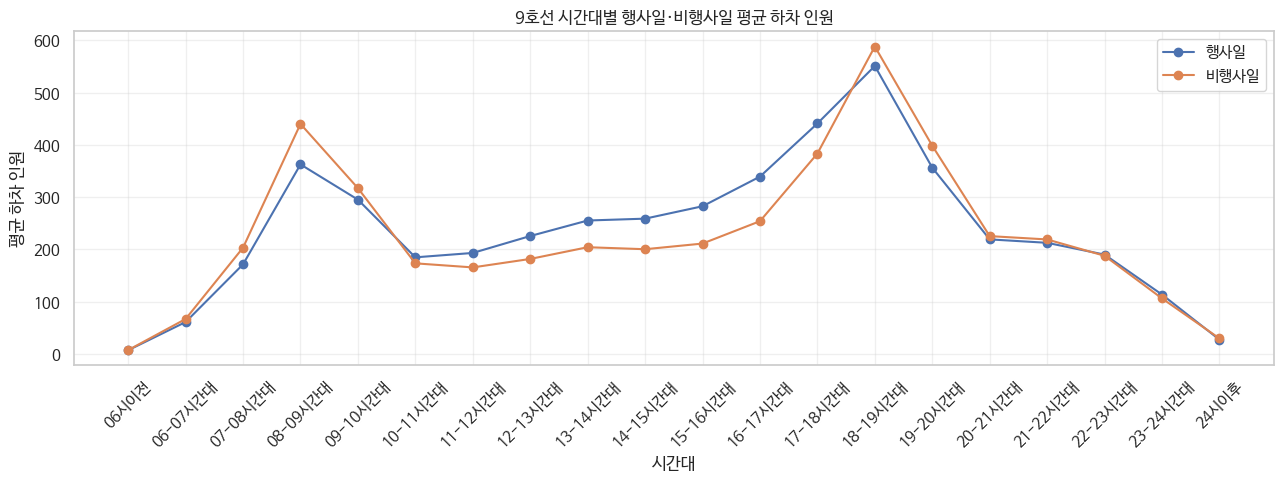

In [ ]:
# 9호선 하차 시각화

plot_data = hourly_average[
    (hourly_average['호선'] == '9호선') &
    (hourly_average['승하차구분'] == '하차')
]

plt.figure(figsize=(13, 5))

for event_type in ['행사일', '비행사일']:
    one = plot_data[plot_data['행사여부'] == event_type]

    plt.plot(
        one['시간대'].astype(str),
        one['평균인원'],
        marker='o',
        label=event_type
    )

plt.title('9호선 시간대별 행사일·비행사일 평균 하차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 하차 인원')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 행사 종료 시각 & 종료 후 한 시간 후 결합

In [ ]:
event_rows = integration_covid_x_df[integration_covid_x_df['행사여부'] == '행사일'].copy()
event_rows['상대시간대'] = None

event_rows.loc[event_rows['시간대시작'] == event_rows['종료시'], '상대시간대'] = '종료 포함 시간대'
event_rows.loc[event_rows['시간대시작'] == event_rows['종료시'] + 1, '상대시간대'] = '종료 후 1시간대'

event_window = event_rows[event_rows['상대시간대'].notna()].copy()

print(event_window['상대시간대'].value_counts())
print('분석에 포함된 행사일 수:', event_window['수송일자'].nunique())

상대시간대
종료 포함 시간대    3452
종료 후 1시간대    3452
Name: count, dtype: int64
분석에 포함된 행사일 수: 863


In [ ]:
# 비행사일 기준 평균

normal_days = integration_covid_x_df[integration_covid_x_df['행사여부'] == '비행사일'].copy()
baseline_keys = ['연도', '요일', '호선', '승하차구분', '시간대']
baseline = (
    normal_days.groupby(baseline_keys, observed=True)['승하차인원']
    .mean()
    .reset_index(name='비행사일평균')
)

In [ ]:
# 행사 종료 직후 데이터 + 비행사일 평균 조인

matched = event_window.merge(
    baseline,
    on=['연도', '요일', '호선', '승하차구분', '시간대'],
    how='left'
)

In [ ]:
# 행사/비행사 차이, 증가율 차이 확인

matched['차이'] = matched['승하차인원'] - matched['비행사일평균']

matched['증가율'] = np.where(
    matched['비행사일평균'] > 0,
    matched['차이'] / matched['비행사일평균'] * 100,
    np.nan
)
matched['행사일우위'] = matched['차이'] > 0

In [ ]:
# 호선/승하차/상대시간대별 결과

time_summary = (
    matched.groupby(
        ['호선', '승하차구분', '상대시간대'],
        observed=True
    )
    .agg(
        행사일평균=('승하차인원', 'mean'),
        비행사일평균=('비행사일평균', 'mean'),
        평균차이=('차이', 'mean'),
        평균증가율=('증가율', 'mean'),
        증가율중앙값=('증가율', 'median'),
        행사일우위비율=('행사일우위', 'mean'),
        표본수=('수송일자', 'count')
    )
    .reset_index()
)

time_summary['행사일우위비율'] = time_summary['행사일우위비율'] * 100
time_summary.round(2)

,호선,승하차구분,상대시간대,행사일평균,비행사일평균,평균차이,평균증가율,증가율중앙값,행사일우위비율,표본수
0,2호선,승차,종료 포함 시간대,3130.90,749.86,2381.05,445.20,157.11,74.62,863
1,2호선,승차,종료 후 1시간대,1844.66,436.66,1408.00,480.77,81.69,66.16,863
2,2호선,하차,종료 포함 시간대,472.49,392.88,79.62,22.75,14.87,76.13,863
3,2호선,하차,종료 후 1시간대,392.09,345.77,46.32,19.74,12.66,76.25,863
4,9호선,승차,종료 포함 시간대,317.69,232.21,85.48,43.46,9.42,65.35,863
5,9호선,승차,종료 후 1시간대,317.86,181.70,136.16,89.50,24.52,77.40,863
6,9호선,하차,종료 포함 시간대,220.71,216.01,4.69,4.59,3.74,60.02,863
7,9호선,하차,종료 후 1시간대,197.13,190.03,7.11,8.34,6.96,67.21,863


#### 행사/비행사 2호선 평균 승차 인원 비교

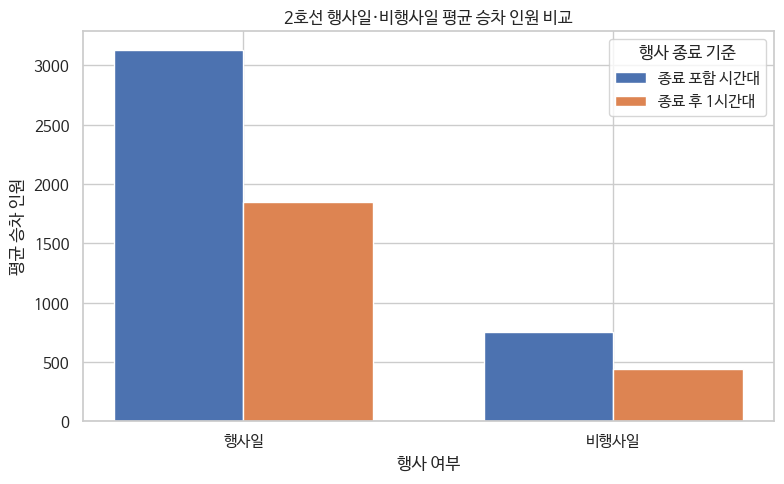

In [ ]:
# 2호선 행사/비행사 평균 승차 인원 비교

plot_data = time_summary[
    (time_summary['호선'] == '2호선') &
    (time_summary['승하차구분'] == '승차')
].copy()

end_time = plot_data[plot_data['상대시간대'] == '종료 포함 시간대'].iloc[0]
after_time = plot_data[plot_data['상대시간대'] == '종료 후 1시간대'].iloc[0]

x_labels = ['행사일', '비행사일']

end_values = [
    end_time['행사일평균'],
    end_time['비행사일평균']
]

after_values = [
    after_time['행사일평균'],
    after_time['비행사일평균']
]

x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    end_values,
    width=width,
    label='종료 포함 시간대'
)

plt.bar(
    x + width / 2,
    after_values,
    width=width,
    label='종료 후 1시간대'
)

plt.title('2호선 행사일·비행사일 평균 승차 인원 비교')
plt.xlabel('행사 여부')
plt.ylabel('평균 승차 인원')
plt.xticks(x, x_labels)
plt.legend(title='행사 종료 기준')
plt.tight_layout()
plt.show()

#### 행사/비행사 9호선 평균 승차 인원 비교

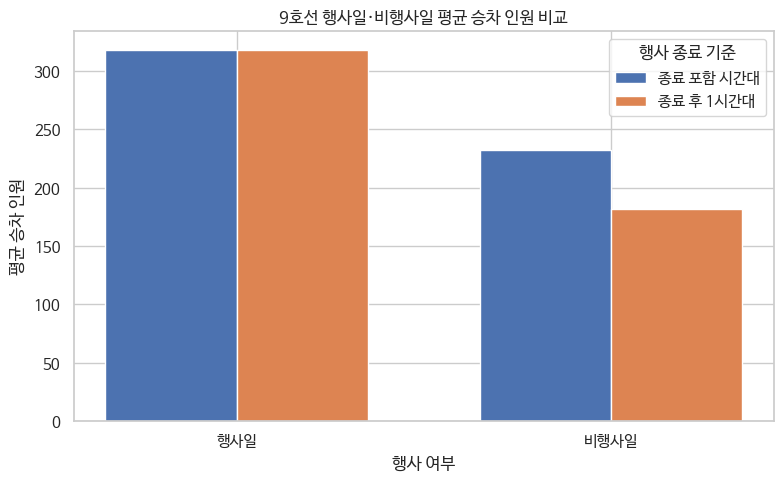

In [ ]:
# 9호선 행사/비행사 평균 승차 인원 비교

plot_data = time_summary[
    (time_summary['호선'] == '9호선') &
    (time_summary['승하차구분'] == '승차')
].copy()

end_time = plot_data[plot_data['상대시간대'] == '종료 포함 시간대'].iloc[0]
after_time = plot_data[plot_data['상대시간대'] == '종료 후 1시간대'].iloc[0]

x_labels = ['행사일', '비행사일']

end_values = [
    end_time['행사일평균'],
    end_time['비행사일평균']
]

after_values = [
    after_time['행사일평균'],
    after_time['비행사일평균']
]

x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    end_values,
    width=width,
    label='종료 포함 시간대'
)

plt.bar(
    x + width / 2,
    after_values,
    width=width,
    label='종료 후 1시간대'
)

plt.title('9호선 행사일·비행사일 평균 승차 인원 비교')
plt.xlabel('행사 여부')
plt.ylabel('평균 승차 인원')
plt.xticks(x, x_labels)
plt.legend(title='행사 종료 기준')
plt.tight_layout()
plt.show()


#### 행사 종료 직후 두 시간대 행사별 합

In [ ]:
# 행사 종료 직후 두 시간대 행사별 합

daily_result = (
    matched.groupby(
        ['수송일자', '연도', '월', '요일', '요일구분', '호선', '승하차구분'],
        observed=True
    )
    .agg(
        행사일인원=('승하차인원', 'sum'),
        비행사일기준=('비행사일평균', 'sum')
    )
    .reset_index()
)

daily_result

,수송일자,연도,월,요일,요일구분,호선,승하차구분,행사일인원,비행사일기준
0,2022-01-07,2022,1,금요일,평일,2호선,승차,605.0,2648.571429
1,2022-01-07,2022,1,금요일,평일,2호선,하차,815.0,846.071429
2,2022-01-07,2022,1,금요일,평일,9호선,승차,455.0,450.785714
3,2022-01-07,2022,1,금요일,평일,9호선,하차,436.0,385.000000
4,2022-01-09,2022,1,일요일,주말,2호선,승차,675.0,1498.000000
...,...,...,...,...,...,...,...,...,...
3447,2025-12-27,2025,12,토요일,주말,9호선,하차,434.0,359.333333
3448,2025-12-28,2025,12,일요일,주말,2호선,승차,2529.0,748.000000
3449,2025-12-28,2025,12,일요일,주말,2호선,하차,650.0,504.076923
3450,2025-12-28,2025,12,일요일,주말,9호선,승차,1488.0,463.307692


## 가설 2
### 행사 종료 시각이 포함된 시간대 또는 종료 직후 시간대에 종합운동장역 승차 인원이 가장 크게 증가할 것이다.

In [ ]:
# 4차 통합 파일
integration2_df = pd.read_csv(f'{base_path}/data/4차통합.csv')
# 혼잡도 파일
congestion2_df = pd.read_csv(f'{base_path}/data/혼잡도_통합_v2.csv')

/tmp/ipykernel_146190/3798144195.py:2: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  integration2_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


In [ ]:
# 코로나 시기 제외
integration2_df = integration2_df[integration2_df['연도'] >= 2022]

In [ ]:
# 행사 종료 시간에서 시(hour) 추출 및 숫자로 변환
integration2_df["종료시"] = (
    integration2_df["측정종료시간"]
    .str.split(":")
    .str[0]
    .astype(int)
)

#### 시간대 정렬

In [ ]:
daily_mean = (
    integration2_df.loc[(integration2_df['승하차구분'] == '승차')]
    .groupby(['연도', '수송일자', '호선', '요일구분' ,'시간대'])['승하차인원']
    .mean()
    .reset_index()
)

time_order = [
    '06시이전',
    '06-07시간대',
    '07-08시간대',
    '08-09시간대',
    '09-10시간대',
    '10-11시간대',
    '11-12시간대',
    '12-13시간대',
    '13-14시간대',
    '14-15시간대',
    '15-16시간대',
    '16-17시간대',
    '17-18시간대',
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대',
    '23-24시간대',
    '24시이후'
]

daily_mean['시간대'] = pd.Categorical(daily_mean['시간대'], categories=time_order, ordered=True)

daily_mean = daily_mean.sort_values('시간대')

### 모든 연도의 시간대별(12시 이후) 일평균 승차인원 추이 그래프

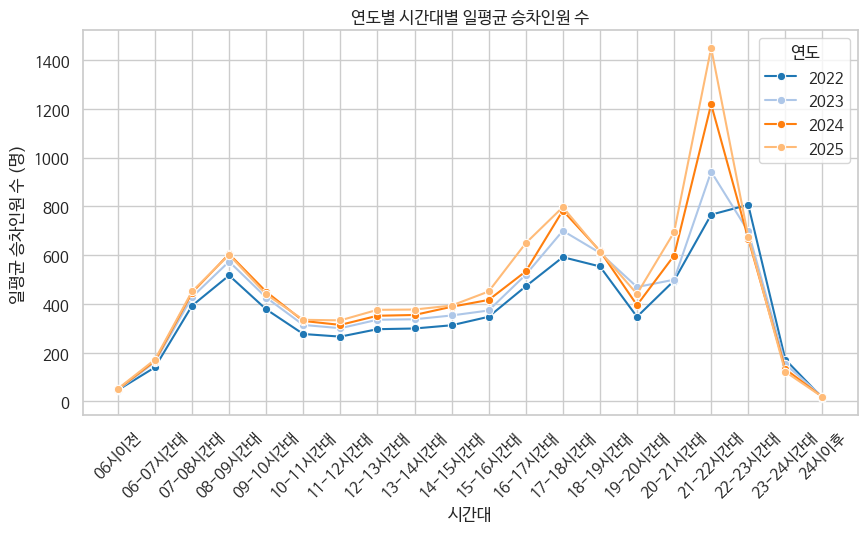

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=daily_mean, x='시간대', y='승하차인원', errorbar=None,
            marker='o', hue='연도', palette='tab20')

plt.title('연도별 시간대별 일평균 승차인원 수')
plt.xlabel('시간대')
plt.ylabel('일평균 승차인원 수 (명)')
plt.xticks(rotation=45)
plt.show()

### 행사 종료 시각별 평균 승차인원

#### 평일/주말

In [ ]:
# 행사 종료 시각별/요일별 평균 승차인원 계산
endtime_mean = (
    integration2_df.loc[integration2_df['승하차구분'] == '승차']
    .groupby(['수송일자', '요일구분', '최종종료시간'])['승하차인원']
    .mean()
    .reset_index()
)

# 최종종료시간을 기준으로 정렬
# 문자열을 datetime 형식으로 변환 후 정렬하여 x축 순서를 고정
endtime_mean['시간_sort'] = pd.to_datetime(
    endtime_mean['최종종료시간'], format='%H:%M:%S'
)
endtime_mean = endtime_mean.sort_values('시간_sort')
endtime_mean

,수송일자,요일구분,최종종료시간,승하차인원,시간_sort
176,2022-11-12,주말,14:40:00,634.50,1900-01-01 14:40:00
192,2022-12-03,주말,14:40:00,672.50,1900-01-01 14:40:00
171,2022-11-05,주말,14:40:00,543.00,1900-01-01 14:40:00
202,2022-12-17,주말,14:40:00,469.00,1900-01-01 14:40:00
181,2022-11-19,주말,14:40:00,384.00,1900-01-01 14:40:00
...,...,...,...,...,...
325,2023-07-22,주말,22:30:00,298.00,1900-01-01 22:30:00
427,2023-12-29,평일,22:30:00,1098.00,1900-01-01 22:30:00
154,2022-09-25,주말,23:00:00,2013.75,1900-01-01 23:00:00
153,2022-09-24,주말,23:00:00,2128.25,1900-01-01 23:00:00


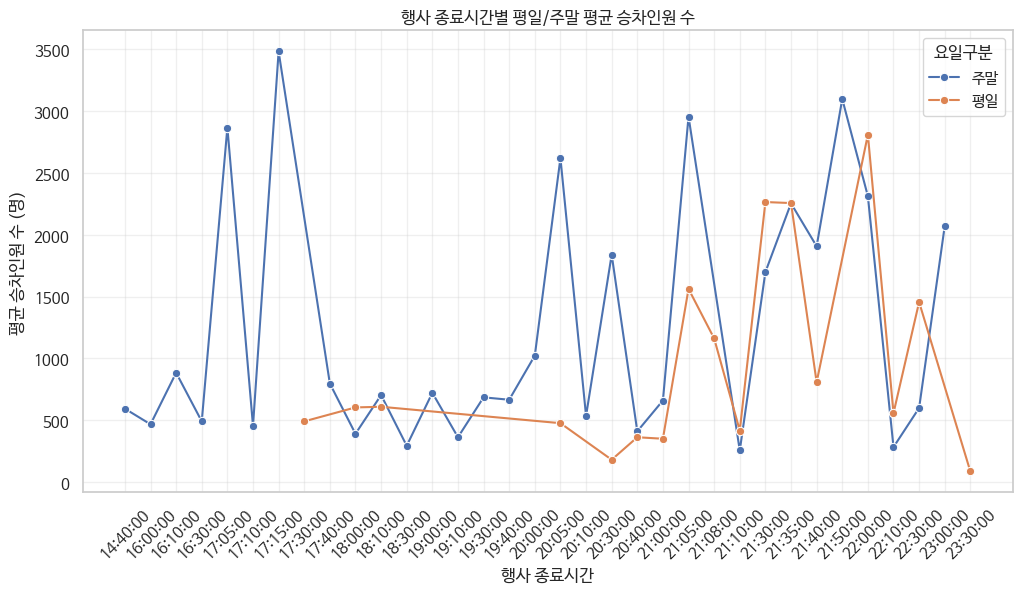

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=endtime_mean, x='최종종료시간', y='승하차인원',
    hue='요일구분',
    marker='o',
    errorbar=None
)

plt.title('행사 종료시간별 평일/주말 평균 승차인원 수')
plt.xlabel('행사 종료시간')
plt.ylabel('평균 승차인원 수 (명)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

### 시간대별 호선별 평일/주말 평균 승차인원 수 (전체 기간 동안 모든 평일/주말 승차인원)

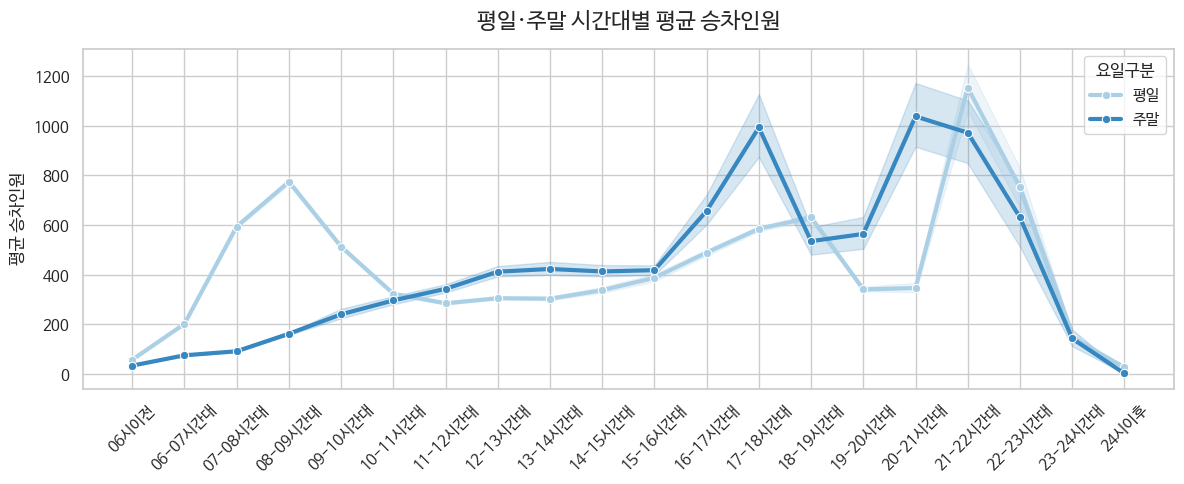

In [ ]:
# 일단 호선 제외
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_mean,
    x="시간대",
    y="승하차인원",
    hue="요일구분",
    marker="o",
    linewidth=3,
    palette="Blues"
)

plt.title(
    "평일·주말 시간대별 평균 승차인원",
    fontsize=16,
    pad=15
)

plt.xlabel("")
plt.ylabel("평균 승차인원")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



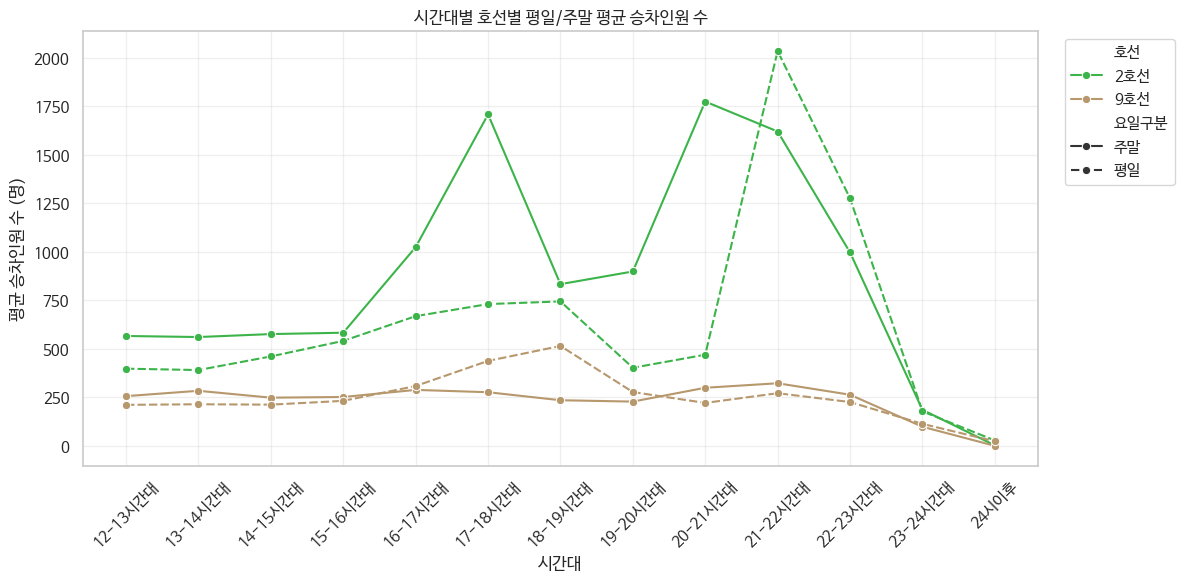

In [ ]:
# 위 그래프에서 호선 구분 추가 (시간대별 호선별 평일/주말 평균 승차인원)
add_line = (
    integration2_df.loc[(integration2_df['시간대'] >= '12-13시간대') & (integration2_df['승하차구분'] == '승차')]
    .groupby(['수송일자', '호선', '요일구분', '시간대'])['승하차인원']
    .mean()
    .reset_index()
)

# 호선별 색상 지정
line_colors = {
    '2호선': '#3CB44A',
    '9호선': '#B7976C'
}

# 위 두 그래프를 합쳐서 그릴 때
plt.figure(figsize=(12, 6))

# 호선별 색상 지정
line_colors = {
    '2호선': '#3CB44A',
    '9호선': '#B7976C'
}

sns.lineplot(
    data=add_line, x='시간대', y='승하차인원',
    hue='호선',  # 색상: 호선별
    style='요일구분',  # 선 모양: 평일(실선) / 주말(점선)
    marker='o', palette=line_colors,
    errorbar=None
)

plt.title('시간대별 호선별 평일/주말 평균 승차인원 수')
plt.xlabel('시간대')
plt.ylabel('평균 승차인원 수 (명)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 범례 위치를 그래프 오른쪽 바깥으로 이동
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 승차 데이터만 사용
ride_df = integration2_df[integration2_df["승하차구분"] == "승차"].copy()


# 요일별(평일/토요일/일요일) + 시간대별 + 호선별 평균 승차인원
line_time_result = (
    ride_df
    .groupby(["요일구분", "호선", "시간대"])["승하차인원"]
    .mean()
    .reset_index()
)

line_time_result

,요일구분,호선,시간대,승하차인원
0,주말,2호선,06-07시간대,104.987421
1,주말,2호선,06시이전,38.188679
2,주말,2호선,07-08시간대,121.549266
3,주말,2호선,08-09시간대,212.312369
4,주말,2호선,09-10시간대,317.098532
...,...,...,...,...
75,평일,9호선,20-21시간대,221.462398
76,평일,9호선,21-22시간대,271.467480
77,평일,9호선,22-23시간대,225.913618
78,평일,9호선,23-24시간대,113.446138


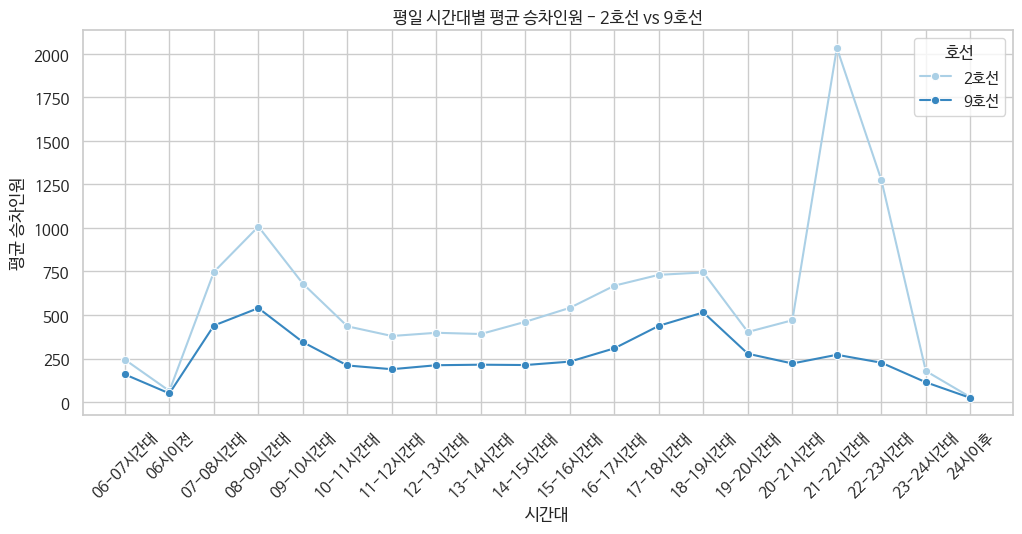

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=line_time_result[line_time_result["요일구분"]=="평일"],
    x="시간대",
    y="승하차인원",
    hue="호선",
    palette="Blues",
    marker="o"
)

plt.title("평일 시간대별 평균 승차인원 - 2호선 vs 9호선")
plt.xlabel("시간대")
plt.ylabel("평균 승차인원")
plt.xticks(rotation=45)
plt.show()

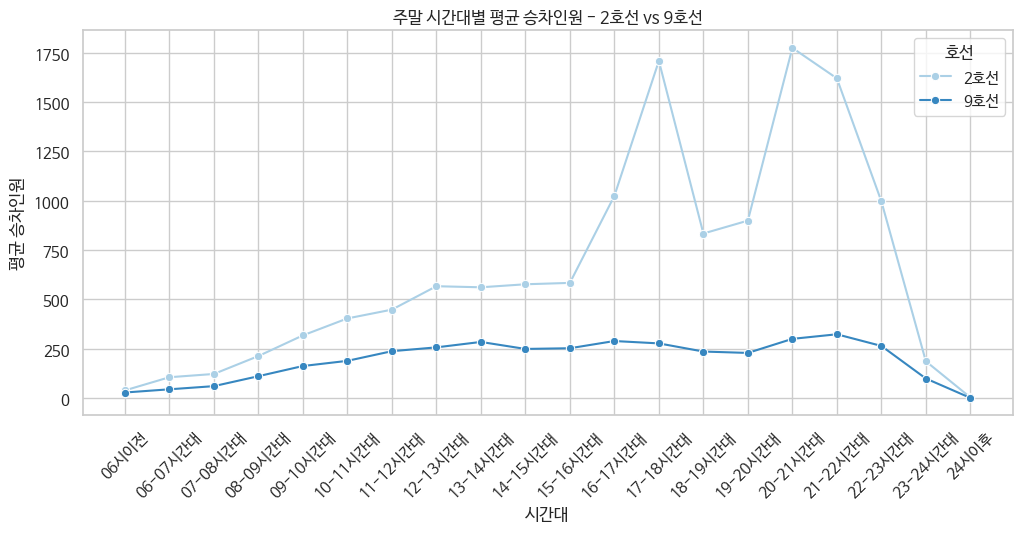

In [ ]:
line_time_result["시간대"] = pd.Categorical(
    line_time_result["시간대"],
    categories=time_order,
    ordered=True
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=line_time_result[line_time_result["요일구분"]=="주말"],
    x="시간대",
    y="승하차인원",
    hue="호선",
    palette="Blues",
    marker="o"
)

plt.title("주말 시간대별 평균 승차인원 - 2호선 vs 9호선")
plt.xlabel("시간대")
plt.ylabel("평균 승차인원")
plt.xticks(rotation=45)
plt.show()


### 피크타임별 평균 승차인원
주요 피크 구간별 평균 승차량 비교
가장 승차 수요가 높은 시간대를 확인하여 증편 대상 선정

#### 평일/주말

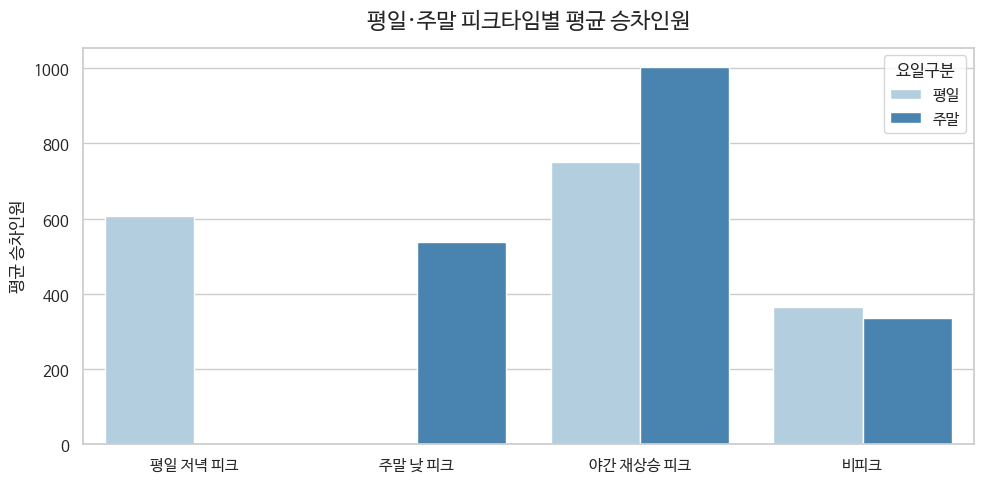

In [ ]:
peak_week = (
    integration2_df[integration2_df["승하차구분"] == "승차"]
    .groupby(["요일구분", "피크타임"])["승하차인원"]
    .mean()
    .reset_index()
)

peak_week["피크타임"] = peak_week["피크타임"].replace({
    "주말 낯 피크": "주말 낮 피크",
    "쾌적": "비피크"
})

peak_order = [
    "평일 저녁 피크",
    "주말 낮 피크",
    "야간 재상승 피크",
    "비피크"
]

peak_week["피크타임"] = pd.Categorical(
    peak_week["피크타임"],
    categories=peak_order,
    ordered=True
)

peak_week = peak_week.sort_values("피크타임")

plt.figure(figsize=(10,5))

sns.barplot(
    data=peak_week,
    x="피크타임",
    y="승하차인원",
    hue="요일구분",
    palette="Blues"
)

plt.title(
    "평일·주말 피크타임별 평균 승차인원",
    fontsize=16,
    pad=15
)

plt.xlabel("")
plt.ylabel("평균 승차인원")

plt.tight_layout()
plt.show()

# 결론:
# 야간 재상승 피크(20~22시) 구간의 승차량이 평일과 주말 모두 가장 높게 나타남
# 평일 저녁 피크와 주말 낮 피크보다 야간 시간대의 귀가 및 이동 수요가 더 크게 집중되는 것으로 확인됨
# 행사 종료 후 증편 우선 대상 시간대로 야간 재상승 피크 구간 검토가 필요할 것 같음

#### 연도별

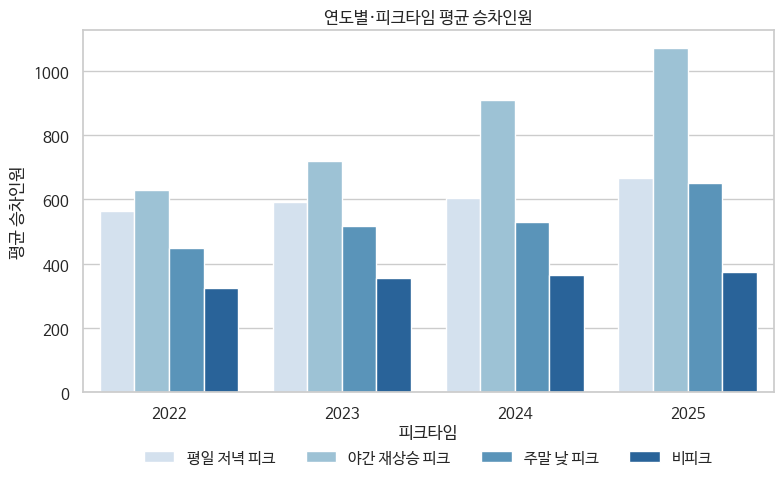

In [ ]:
# 목적:
# 연도별 피크타임 평균 승차인원 비교
# 연도에 따른 시간대별 승차 수요 변화 추이 확인
# 증편 필요 시간대가 연도별로 일관되게 나타나는지 확인

year_peak = (
    integration2_df[integration2_df["승하차구분"] == "승차"]
    .groupby(["연도","피크타임"])["승하차인원"]
    .mean()
    .reset_index()
)

year_peak["피크타임"] = year_peak["피크타임"].replace({
    "주말 낯 피크": "주말 낮 피크",
    "쾌적": "비피크"
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=year_peak,
    x="연도",
    y="승하차인원",
    hue="피크타임",
    hue_order=[
        "평일 저녁 피크",
        "야간 재상승 피크",
        "주말 낮 피크",
        "비피크"
    ],
    palette="Blues"
)

plt.legend(
    title="피크타임",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    frameon=False
)

plt.title("연도별·피크타임 평균 승차인원")
plt.ylabel("평균 승차인원")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 결론:
# 2022년부터 2025년까지 전반적인 평균 승차인원이 꾸준히 증가하는 모습을 보임
# 모든 연도에서 '야간 재상승 피크' 구간의 승차인원이 다른 시간대보다 가장 높게 나타남
# 특히 야간 재상승 피크는 연도가 지날수록 증가 폭이 커져 행사 종료 후 귀가 수요가 점차 증가하는 경향이 있음
# 따라서 야간 재상승 피크는 매년 반복적으로 높은 승차 수요가 나타나는 시간대로, 증편을 우선적으로 검토가 필요할 것 같음

## 가설 3
### 콘서트는 종료 직후 승차 수요가 특정 시간대에 집중되는 반면, 야구 경기는 경기 종료 전후 여러 시간대에 승차 수요가 분산될 것이다.

In [ ]:
# 4차 통합 파일
integration3_df = pd.read_csv(f'{base_path}/data/4차통합.csv')
# 혼잡도 파일
cong = pd.read_csv(f'{base_path}/data/상하행 내외선 방향별 혼잡도 패턴.csv')

/tmp/ipykernel_146190/1763207386.py:2: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  integration3_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


### 파일 전처리

In [ ]:
# 코로나 시기 제외
integration3_df = integration3_df[~integration3_df['연도'].isin([2020, 2021])]

In [ ]:
# datetime : 수송일자
integration3_df['수송일자'] = pd.to_datetime(integration3_df['수송일자'])

# 시간대는 시작시 컬럼을 추가한다.
def bucket_to_hour(bucket: str) -> int:
    if bucket == "06시이전":         # 02~06시 구간
        return 2
    if bucket == "24시이후":         # 24시 이후(자정 근접) 구간
        return 24
    return int(bucket.split("-")[0])  # 'HH-HH+1시간대' -> 'HH' 부분만 정수로 변환

integration3_df["시간대_시작시"] = integration3_df["시간대"].apply(bucket_to_hour)  # 각 행의 시간대를 숫자 시각으로 변환한 새 컬럼 생성

# 시간대 순서를 올바르게 정렬하기 위한 카테고리 순서 정의 (그래프 x축 정렬에 사용)
bucket_order = ["06시이전"] + [f"{h:02d}-{h+1:02d}시간대" for h in range(6, 24)] + ["24시이후"]

# 시간대구분
times = ['오전', '낮', '저녁', '야간']
integration3_df['시간대구분'] = pd.Categorical(integration3_df['시간대구분'], categories=times, ordered=True)


### 날짜별 행사 정보 요약
- 행사시작 시간이 포함된 행에만 행사 정보가 포함되어있어 같은 날짜의 다른 시간대 행에는 NaN 값.
- 분석 목적인 행사시간 전후 승차수요 확인을 위해서는 하루 전체 시간대별 승차인원 필요.
- 행사일 몇시 ~ 몇시에 있었는지 날짜 단위 정리 필요.

In [ ]:
# 시간이 분단위도 있어 반영해야함
def hms_to_float_hour(t):
    if pd.isna(t):
        return np.nan
    h, m, s = str(t).split(":")
    return int(h) + (int(m) / 60) # 초 단위는 모두 00 으로 표기. 생략함

# 분야명이 채워진 행만 골라 날짜별로 중복 없는 행사 정보만 추출
event_day_info = (
    integration3_df.loc[integration3_df["분야명"].notna()]
    .assign(
        수송일자=lambda d: pd.to_datetime(d["수송일자"]),
        행사시작_시각=lambda d: d["최초시작시간"].apply(hms_to_float_hour),
        행사종료_시각=lambda d: d["최종종료시간"].apply(hms_to_float_hour),
    )
    .groupby("수송일자")
    .agg(
        제목=("제목", lambda x: " / ".join(x.dropna().unique())),      # 여러 행사면 " / "로 나열
        분야명=("분야명", lambda x: " / ".join(x.dropna().unique())),
        행사수=("행사수", "first"),          # raw에 이미 계산돼 있으니 그대로 가져오기만
        행사시작_시각=("행사시작_시각", "first"),   # 날짜 내 값이 일관됨이 검증됐으니 first로 충분
        행사종료_시각=("행사종료_시각", "first"),
    )
)

### 행사일 분류
- 행사수 1개 인 데이터만 가지고 분석 진행.(행사가 여러개이면 행사유형별 승차수요 확인 어려움)
- 야구그룹 : 분야명 '스포츠 경기' & 제목 '프로야구'
- 콘서트 그룹: '분야명'공연' & 제목 ' 콘서트

In [ ]:
# 행사일이 1개인 날짜만 추출
pure_events = event_day_info[event_day_info['행사수'] == 1]

# 행사일 중 야구/콘서트 분류
# 야구
baseball_days = pure_events[
    (pure_events['분야명'] == '스포츠 경기') & (pure_events['제목'].str.contains('프로야구', na=False))
]
# 콘서트
concert_days = pure_events[
    (pure_events['분야명'] == '공연') & (pure_events['제목'].str.contains('콘서트', na=False))
]

# df에서 행사일에 속하는 시간대행 전체 추출
baseball_df = integration3_df[integration3_df['수송일자'].isin(baseball_days.index)].copy()
concert_df = integration3_df[integration3_df['수송일자'].isin(concert_days.index)].copy()

# 행사종료_시각을 df에 합치기
baseball_df = baseball_df.merge(
    event_day_info[['행사종료_시각']], left_on='수송일자', right_index=True, how='left'
)
concert_df = concert_df.merge(
    event_day_info[['행사종료_시각']], left_on='수송일자', right_index=True, how='left'
)

# 종료전/후 라벨 생성
baseball_df['종료후_여부'] = baseball_df['시간대_시작시'] >= baseball_df['행사종료_시각']
concert_df['종료후_여부'] = concert_df['시간대_시작시'] >= concert_df['행사종료_시각']

###노선의 [날짜 x 시간대] 승차인원 피벗 테이블 생성

In [ ]:
def build_daily_pivot(line):
    sub = integration3_df[integration3_df["호선"] == line]
    return sub.pivot_table(
        index="수송일자", columns="시간대_시작시", values="승하차인원", aggfunc="sum"
    )

daily_pivot_2 = build_daily_pivot("2호선")
daily_pivot_9 = build_daily_pivot("9호선")

### 상대시간 계산

In [ ]:
WINDOW = range(-3,4) # 행사종료 전후 3시간 승차비중 변화 확인
# 행사일 에서 각 날짜의 시간대별 승차 비중을 롱타입으로 정렬

def build_relative_share_long(event_days: pd.DataFrame, group_name: str, daily_pivot: pd.DataFrame):
    records = []
    for date, row in event_days.iterrows():
        if date not in daily_pivot.index:          # 승차 데이터가 없는 날짜는 건너뜀
            continue
        day_series = daily_pivot.loc[date]           # 그 날짜의 시간대별[0,1,2...] 승차인원
        total = day_series.sum()
        if not np.isfinite(total) or total == 0:     # 하루 총 승차인원이 0/결측이면 건너뜀
            continue
        share = day_series / total                    # 시간대별 승차 '비중'으로 정규화
        end_floor = int(np.floor(row["행사종료_시각"]))  # 종료시각이 포함된 시간대

        for offset in WINDOW:
            target_hour = end_floor + offset          # 상대시간(offset)에 대응하는 실제 시간대
            if target_hour in share.index:            # 해당 시간대가 그날 존재하면
                records.append({
                    "그룹": group_name,
                    "날짜": date,
                    "제목": row["제목"],
                    "상대시간": offset,
                    "승차비중": share[target_hour],
                })
    return pd.DataFrame(records)

result_baseball_2 = build_relative_share_long(baseball_days, "야구_2호선", daily_pivot_2)
result_baseball_9 = build_relative_share_long(baseball_days, "야구_9호선", daily_pivot_9)
result_concert_2  = build_relative_share_long(concert_days, "콘서트_2호선", daily_pivot_2)
result_concert_9  = build_relative_share_long(concert_days, "콘서트_9호선", daily_pivot_9)

all_results = pd.concat(
    [result_baseball_2, result_baseball_9, result_concert_2, result_concert_9],
    ignore_index=True
)

all_results[['행사유형', '호선']] = all_results['그룹'].str.split('_',expand=True)

### 현재 데이터는 행사일의 실제 종료시각이 정확히 기록되지 않아, 행사 유형별 평균 행사 시간을 적용해 종료시각을 도출했다.
실제 종료시각에 따른 시간대별 승차비중과 차이가 있는지 확인하기 위해 실제 종료시각 데이터를 이용하여 현재 데이터와 비교 하기로 하였다.

In [ ]:
# 1. 원본 행사 데이터 불러오기
event_raw = pd.read_csv(f"{base_path}/data/잠실행사데이터(종료시간x).csv", encoding="cp949")

In [ ]:
# 2. 실제 종료시각 확인 여부 플래그 생성
event_raw["실제종료여부"] = event_raw["종료시간"] != "미정"

# 3. 날짜 기준으로, 그 날짜에 실제 종료시각이 하나라도 있으면 True로 요약
event_raw["날짜"] = pd.to_datetime(event_raw["날짜"])
actual_end_flag = (
    event_raw.groupby("날짜")["실제종료여부"]
    .any()
    .rename("실제종료시각_확인")
)

event_day_info

,제목,분야명,행사수,행사시작_시각,행사종료_시각
수송일자,,,,,
2022-01-07,프로농구(삼성:가스공사),스포츠 경기,1.0,19.0,21.166667
2022-01-09,프로농구(삼성:DB),스포츠 경기,1.0,15.0,17.166667
2022-01-12,프로농구(삼성:모비스),스포츠 경기,1.0,19.0,21.166667
2022-01-29,프로농구(삼성:SK),스포츠 경기,1.0,15.0,17.166667
2022-02-01,프로농구(삼성:KT),스포츠 경기,1.0,17.0,19.166667
...,...,...,...,...,...
2025-12-24,태양의 써커스 (쿠자),공연,1.0,20.0,22.166667
2025-12-25,태양의 써커스 (쿠자),공연,1.0,20.0,22.166667
2025-12-26,태양의 써커스 (쿠자),공연,1.0,20.0,22.166667


In [ ]:
# 2. 실제 종료시각 확인 여부 플래그 생성
event_raw["실제종료여부"] = event_raw["종료시간"] != "미정"

# 3. 날짜 기준으로, 그 날짜에 실제 종료시각이 하나라도 있으면 True로 요약
event_raw["날짜"] = pd.to_datetime(event_raw["날짜"])
actual_end_flag = (
    event_raw.groupby("날짜")["실제종료여부"]
    .any()
    .rename("실제종료시각_확인")
)

# 4. event_day_info(날짜 인덱스)에 병합
event_day_info = event_day_info.merge(
    actual_end_flag, left_index=True, right_index=True, how="left"
)
event_day_info["실제종료시각_확인"] = event_day_info["실제종료시각_확인"].fillna(False)

baseball_days_actual = baseball_days[
    baseball_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]
concert_days_strict_actual = concert_days[
    concert_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]

In [ ]:
# 콘서트(넓은 정의) — 분야명이 '공연'인 날짜 전체
concert_days_broad = pure_events[
    pure_events['분야명'] == '공연'
]

# 실제값 확인 여부로 필터링
concert_days_broad_actual = concert_days_broad[
    concert_days_broad.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]

print("분야명'공연' - 실제값 확인된 날짜 수:", len(concert_days_broad_actual), "/ 전체:", len(concert_days_broad))

분야명'공연' - 실제값 확인된 날짜 수: 7 / 전체: 163


In [ ]:
baseball_days_actual = baseball_days[
    baseball_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]
concert_days_strict_actual = concert_days[
    concert_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]

result_baseball_2_actual = build_relative_share_long(baseball_days_actual, "야구_2호선_실제값만(48건)", daily_pivot_2)
result_baseball_2_all = build_relative_share_long(baseball_days, "야구_2호선_전체(추정포함, 418건)", daily_pivot_2)

compare_2 = pd.concat([result_baseball_2_actual, result_baseball_2_all], ignore_index=True)
summary_compare_2 = compare_2.groupby(["그룹", '상대시간'])["승차비중"].mean().unstack("그룹")

### 시각화

#### 노선별 승차비중

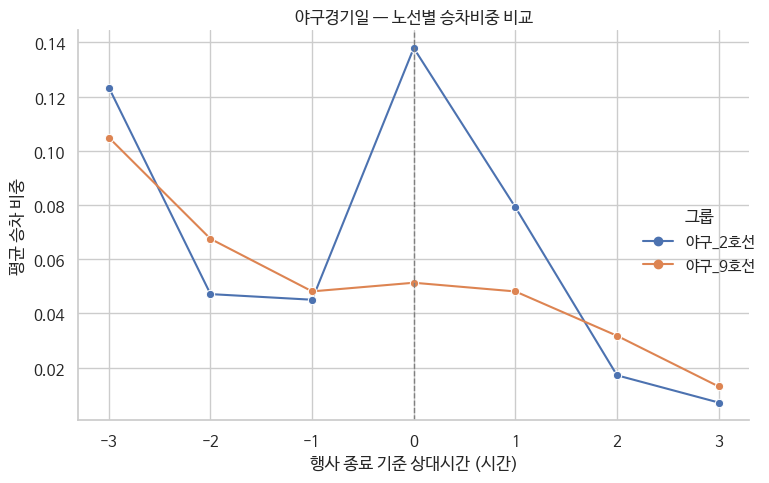

In [ ]:
baseball_only = pd.concat([result_baseball_2, result_baseball_9], ignore_index=True)

g = sns.relplot(
    data=baseball_only,
    x="상대시간", y="승차비중",
    hue="그룹",              # "야구_2호선" / "야구_9호선"이 그대로 hue 구분값이 됨
    kind="line", marker="o",
    errorbar=None,
    height=5, aspect=1.3,
)

g.set_axis_labels("행사 종료 기준 상대시간 (시간)", "평균 승차 비중")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("야구경기일 — 노선별 승차비중 비교")
plt.tight_layout()
plt.show()

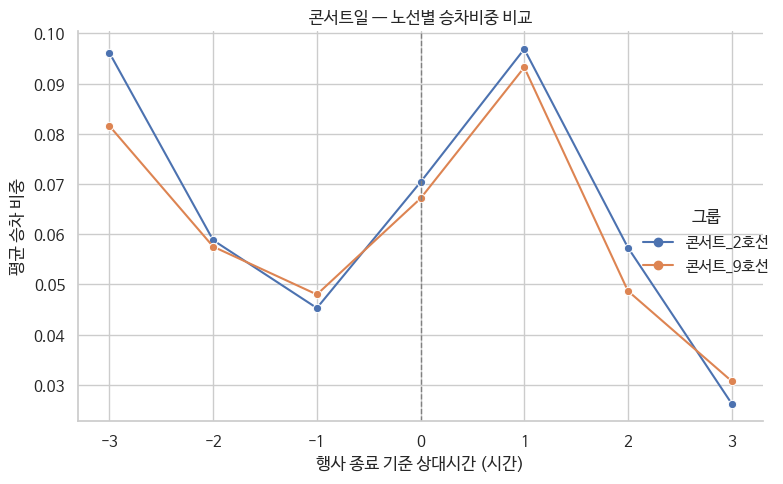

In [ ]:
concert_only = pd.concat([result_concert_2, result_concert_9], ignore_index=True)

g = sns.relplot(
    data=concert_only,
    x="상대시간", y="승차비중",
    hue="그룹",              # "콘서트_2호선" / "콘서트_9호선"이 그대로 hue 구분값이 됨
    kind="line", marker="o",
    errorbar=None,
    height=5, aspect=1.3,
)

g.set_axis_labels("행사 종료 기준 상대시간 (시간)", "평균 승차 비중")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("콘서트일 — 노선별 승차비중 비교")
plt.tight_layout()
plt.show()

#### 강건성 검증

In [ ]:
summary_compare_2

그룹,야구_2호선_실제값만(48건),"야구_2호선_전체(추정포함, 418건)"
상대시간,,
-3,0.101142,0.123324
-2,0.040936,0.047097
-1,0.055597,0.045014
0,0.144313,0.137918
1,0.079262,0.079154
2,0.018296,0.017120
3,0.005798,0.007072


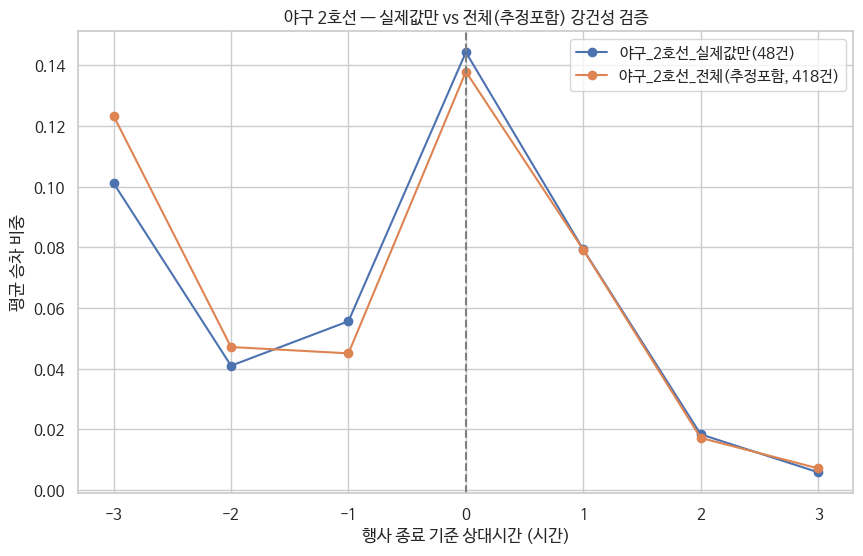

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for g in summary_compare_2.columns:
    ax.plot(summary_compare_2.index, summary_compare_2[g], marker="o", label=g)
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("야구 2호선 — 실제값만 vs 전체(추정포함) 강건성 검증")
ax.legend()
plt.show()

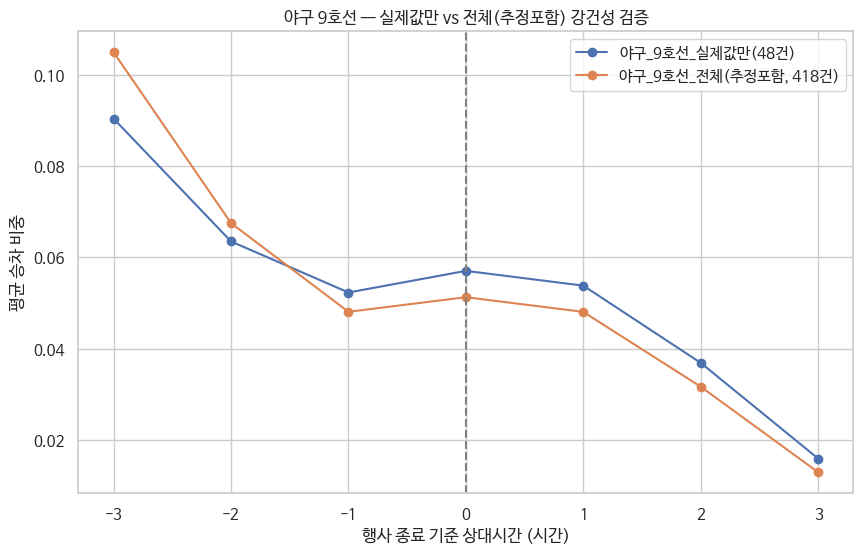

In [ ]:
result_baseball_9_actual = build_relative_share_long(baseball_days_actual, "야구_9호선_실제값만(48건)", daily_pivot_9)
result_baseball_9_all = build_relative_share_long(baseball_days, "야구_9호선_전체(추정포함, 418건)", daily_pivot_9)

compare_9 = pd.concat([result_baseball_9_actual, result_baseball_9_all], ignore_index=True)
summary_compare_9 = compare_9.groupby(["그룹", "상대시간"])["승차비중"].mean().unstack("그룹")
fig, ax = plt.subplots(figsize=(10, 6))
for g in summary_compare_9.columns:
    ax.plot(summary_compare_9.index, summary_compare_9[g], marker="o", label=g)
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("야구 9호선 — 실제값만 vs 전체(추정포함) 강건성 검증")
ax.legend()
plt.show()

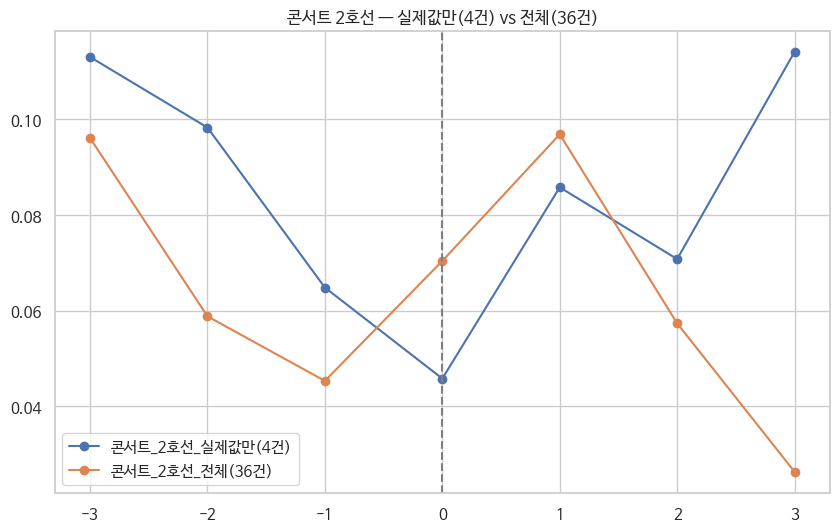

In [ ]:
concert_days_strict_actual = concert_days[
    concert_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]

result_concert_2_actual = build_relative_share_long(concert_days_strict_actual, "콘서트_2호선_실제값만(4건)", daily_pivot_2)
result_concert_2_all = build_relative_share_long(concert_days, "콘서트_2호선_전체(36건)", daily_pivot_2)

compare_concert = pd.concat([result_concert_2_actual, result_concert_2_all], ignore_index=True)
summary_compare_concert = compare_concert.groupby(["그룹", "상대시간"])["승차비중"].mean().unstack("그룹")

fig, ax = plt.subplots(figsize=(10, 6))
for g in summary_compare_concert.columns:
    ax.plot(summary_compare_concert.index, summary_compare_concert[g], marker="o", label=g)
ax.axvline(0, color="gray", linestyle="--")
ax.set_title("콘서트 2호선 — 실제값만(4건) vs 전체(36건)")
ax.legend()
plt.show()

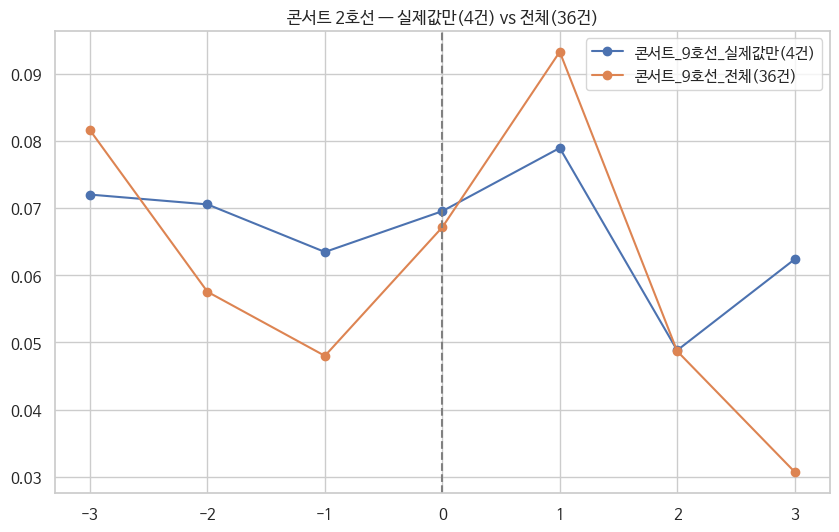

In [ ]:
concert_days_strict_actual = concert_days[
    concert_days.index.isin(event_day_info[event_day_info["실제종료시각_확인"]].index)
]

result_concert_9_actual = build_relative_share_long(concert_days_strict_actual, "콘서트_9호선_실제값만(4건)", daily_pivot_9)
result_concert_9_all = build_relative_share_long(concert_days, "콘서트_9호선_전체(36건)", daily_pivot_9)

compare_concert = pd.concat([result_concert_9_actual, result_concert_9_all], ignore_index=True)
summary_compare_concert = compare_concert.groupby(["그룹", "상대시간"])["승차비중"].mean().unstack("그룹")

fig, ax = plt.subplots(figsize=(10, 6))
for g in summary_compare_concert.columns:
    ax.plot(summary_compare_concert.index, summary_compare_concert[g], marker="o", label=g)
ax.axvline(0, color="gray", linestyle="--")
ax.set_title("콘서트 2호선 — 실제값만(4건) vs 전체(36건)")
ax.legend()
plt.show()

#### 민감도 분석

In [ ]:
# 행사종료_시각을 hours만큼 이동시킨 복사본 반환
def shift_end_time(days_df, hours):
    shifted = days_df.copy()
    shifted["행사종료_시각"] = shifted["행사종료_시각"] + hours
    return shifted

# 야구 그룹 (2호선) 기준으로 민감도 버전 생성
bb_original   = baseball_days
bb_plus30     = shift_end_time(baseball_days, 0.5)
bb_minus30    = shift_end_time(baseball_days, -0.5)
bb_plus1h     = shift_end_time(baseball_days, 1.0)
bb_minus1h    = shift_end_time(baseball_days, -1.0)

versions = {
    "원본": bb_original,
    "+30분": bb_plus30,
    "-30분": bb_minus30,
    "+1시간": bb_plus1h,
    "-1시간": bb_minus1h,
}

sensitivity_results = []
for label, data in versions.items():
    r = build_relative_share_long(data, label, daily_pivot_2)
    sensitivity_results.append(r)

sensitivity_all = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_summary = (
    sensitivity_all.groupby(["그룹", "상대시간"])["승차비중"]
    .mean()
    .unstack("그룹")
)



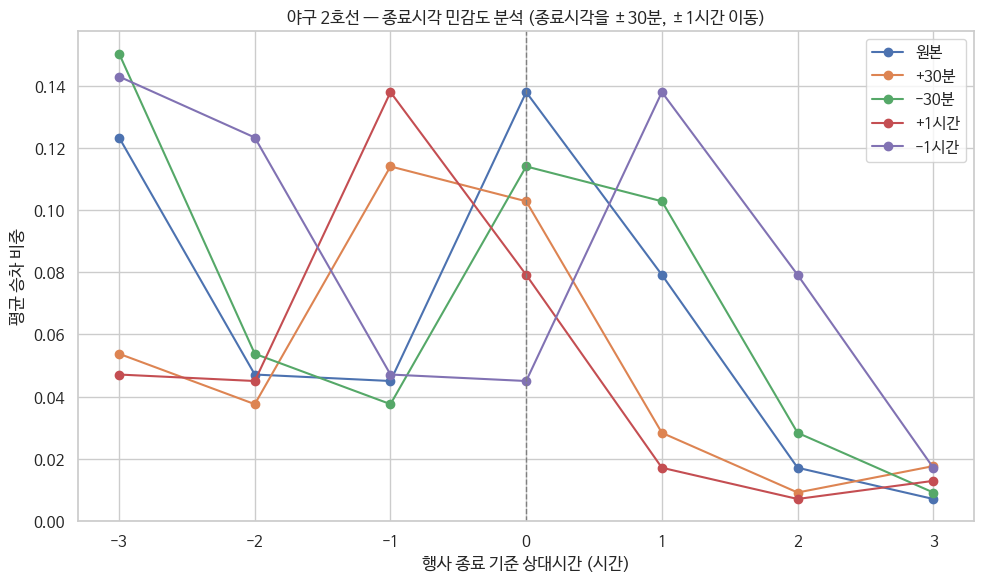

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
for label in versions.keys():
    ax.plot(sensitivity_summary.index, sensitivity_summary[label], marker="o", label=label)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("야구 2호선 — 종료시각 민감도 분석 (종료시각을 ±30분, ±1시간 이동)")
ax.legend()
plt.tight_layout()
plt.show()

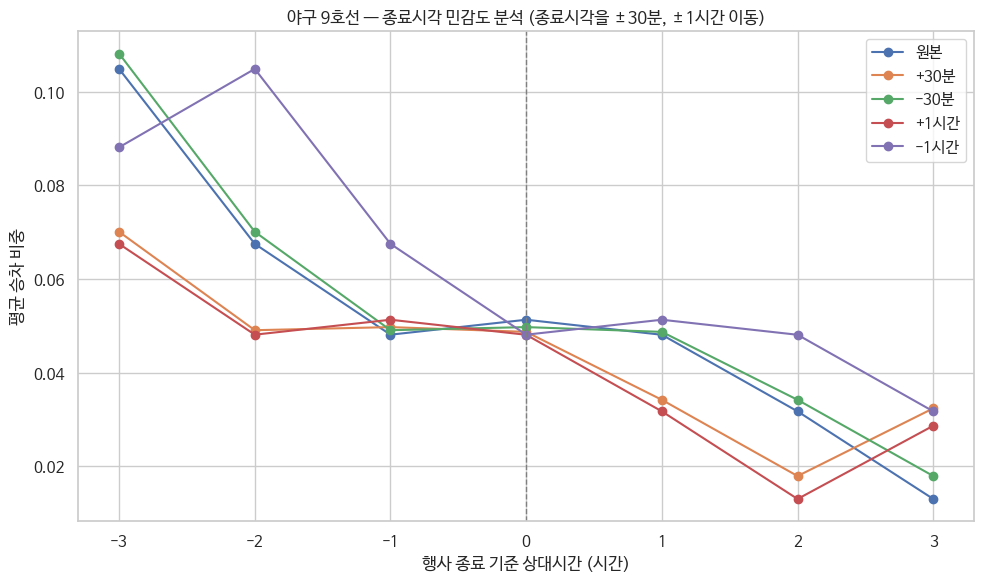

In [ ]:
# 야구 그룹 (9호선) 기준으로 민감도 버전 생성
bb_original   = baseball_days
bb_plus30     = shift_end_time(baseball_days, 0.5)
bb_minus30    = shift_end_time(baseball_days, -0.5)
bb_plus1h     = shift_end_time(baseball_days, 1.0)
bb_minus1h    = shift_end_time(baseball_days, -1.0)

versions = {
    "원본": bb_original,
    "+30분": bb_plus30,
    "-30분": bb_minus30,
    "+1시간": bb_plus1h,
    "-1시간": bb_minus1h,
}

sensitivity_results = []
for label, data in versions.items():
    r = build_relative_share_long(data, label, daily_pivot_9)
    sensitivity_results.append(r)

sensitivity_all = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_summary = (
    sensitivity_all.groupby(["그룹", "상대시간"])["승차비중"]
    .mean()
    .unstack("그룹")
)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
for label in versions.keys():
    ax.plot(sensitivity_summary.index, sensitivity_summary[label], marker="o", label=label)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("야구 9호선 — 종료시각 민감도 분석 (종료시각을 ±30분, ±1시간 이동)")
ax.legend()
plt.tight_layout()
plt.show()

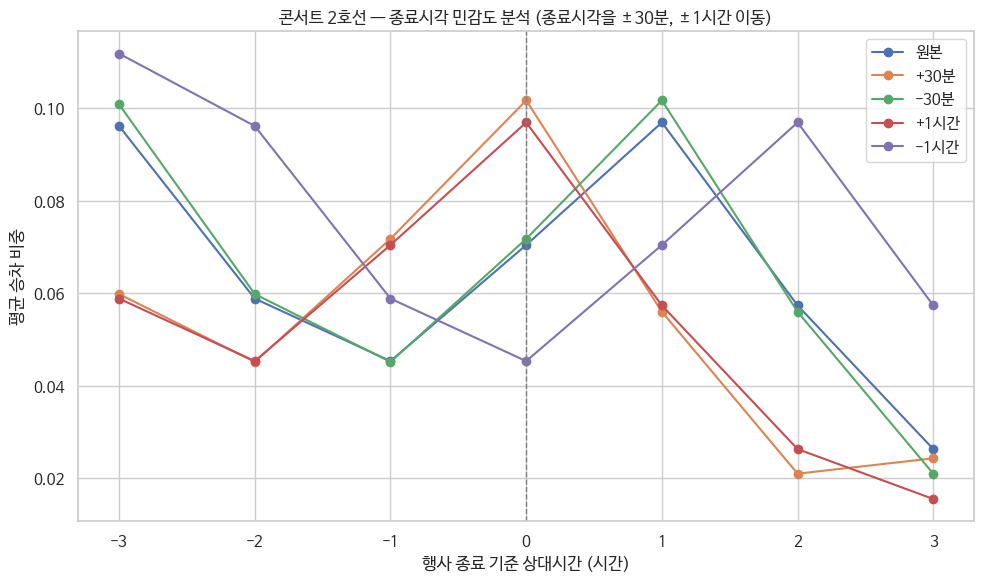

In [ ]:
# 콘서트 그룹 (2호선) 기준으로 민감도 버전 생성
con_original   = concert_days
con_plus30     = shift_end_time(concert_days, 0.5)
con_minus30    = shift_end_time(concert_days, -0.5)
con_plus1h     = shift_end_time(concert_days, 1.0)
con_minus1h    = shift_end_time(concert_days, -1.0)

versions = {
    "원본": con_original,
    "+30분": con_plus30,
    "-30분": con_minus30,
    "+1시간": con_plus1h,
    "-1시간": con_minus1h,
}

sensitivity_results = []
for label, data in versions.items():
    r = build_relative_share_long(data, label, daily_pivot_2)
    sensitivity_results.append(r)

sensitivity_all = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_summary = (
    sensitivity_all.groupby(["그룹", "상대시간"])["승차비중"]
    .mean()
    .unstack("그룹")
)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
for label in versions.keys():
    ax.plot(sensitivity_summary.index, sensitivity_summary[label], marker="o", label=label)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("콘서트 2호선 — 종료시각 민감도 분석 (종료시각을 ±30분, ±1시간 이동)")
ax.legend()
plt.tight_layout()
plt.show()

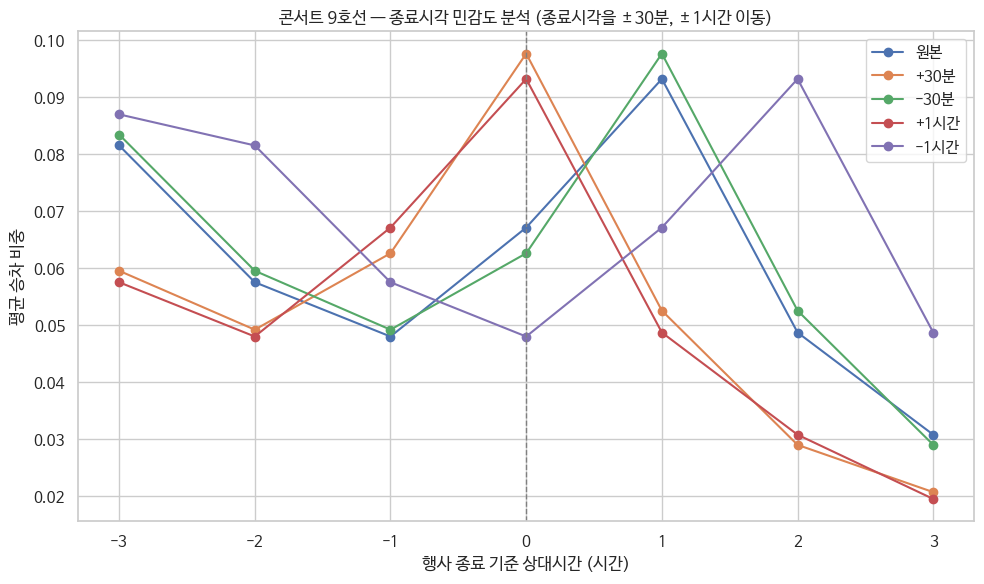

In [ ]:
# 콘서트 그룹 (9호선) 기준으로 민감도 버전 생성
con_original   = concert_days
con_plus30     = shift_end_time(concert_days, 0.5)
con_minus30    = shift_end_time(concert_days, -0.5)
con_plus1h     = shift_end_time(concert_days, 1.0)
con_minus1h    = shift_end_time(concert_days, -1.0)

versions = {
    "원본": con_original,
    "+30분": con_plus30,
    "-30분": con_minus30,
    "+1시간": con_plus1h,
    "-1시간": con_minus1h,
}

sensitivity_results = []
for label, data in versions.items():
    r = build_relative_share_long(data, label, daily_pivot_9)
    sensitivity_results.append(r)

sensitivity_all = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_summary = (
    sensitivity_all.groupby(["그룹", "상대시간"])["승차비중"]
    .mean()
    .unstack("그룹")
)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
for label in versions.keys():
    ax.plot(sensitivity_summary.index, sensitivity_summary[label], marker="o", label=label)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("행사 종료 기준 상대시간 (시간)")
ax.set_ylabel("평균 승차 비중")
ax.set_title("콘서트 9호선 — 종료시각 민감도 분석 (종료시각을 ±30분, ±1시간 이동)")
ax.legend()
plt.tight_layout()
plt.show()

#### 비행사일과 비교

In [ ]:
# 비행사일(대조군) 목록 = daily_pivot_2에는 있지만 event_day_info(행사 정보)에는 없는 날짜
non_event_dates_2 = daily_pivot_2.index.difference(event_day_info.index)
print("비행사일 날짜 수 (2호선 기준):", len(non_event_dates_2))

# 주어진 날짜 목록에 대해, 시간대별 평균 승차 비중을 계산한다(절대 시각 기준)
def average_share_by_hour(dates, daily_pivot) -> pd.Series:
    sub = daily_pivot.loc[daily_pivot.index.intersection(dates)]  # 해당 날짜들의 시간대별 승차인원
    share = sub.div(sub.sum(axis=1), axis=0)                       # 각 날짜를 하루 총합으로 나눠 비중으로 변환
    return share.mean(axis=0)                                       # 날짜들에 대해 평균낸 시간대별 비중

비행사일 날짜 수 (2호선 기준): 598


In [ ]:
# 비행사일(대조군) 목록 = daily_pivot_2에는 있지만 event_day_info(행사 정보)에는 없는 날짜
non_event_dates_2 = daily_pivot_2.index.difference(event_day_info.index)
print("비행사일 날짜 수 (2호선 기준):", len(non_event_dates_2))

# 주어진 날짜 목록에 대해, 시간대별 평균 승차 비중을 계산한다(절대 시각 기준)
def average_share_by_hour(dates, daily_pivot) -> pd.Series:
    sub = daily_pivot.loc[daily_pivot.index.intersection(dates)]  # 해당 날짜들의 시간대별 승차인원
    share = sub.div(sub.sum(axis=1), axis=0)                       # 각 날짜를 하루 총합으로 나눠 비중으로 변환
    return share.mean(axis=0)                                       # 날짜들에 대해 평균낸 시간대별 비중

비행사일 날짜 수 (2호선 기준): 598


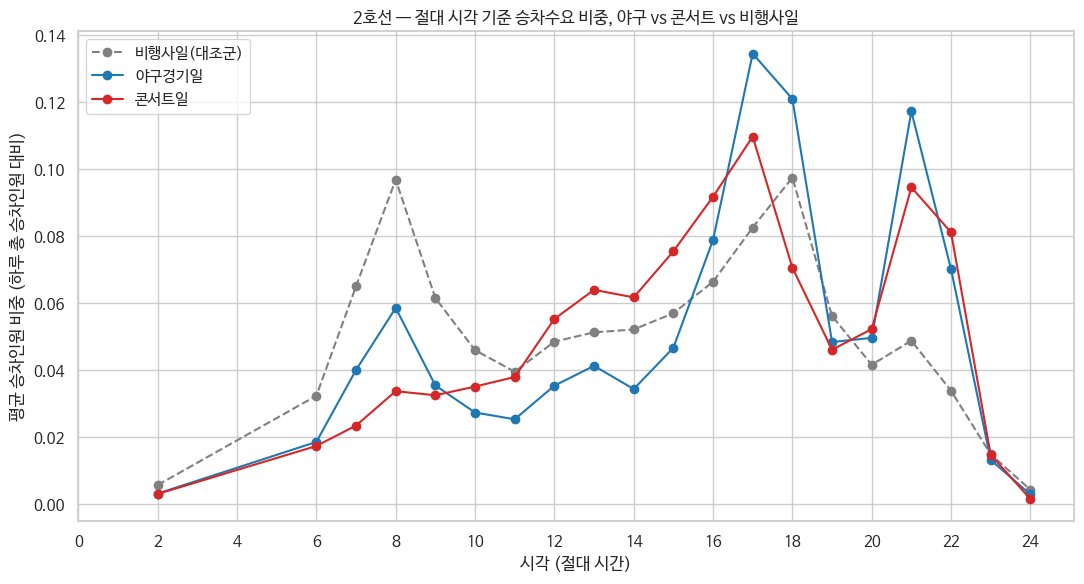

In [ ]:
# 2호선 기준 그룹별 평균 승차비중 계산
avg_non_event_2 = average_share_by_hour(non_event_dates_2, daily_pivot_2)
avg_baseball_2  = average_share_by_hour(baseball_days.index, daily_pivot_2)
avg_concert_2   = average_share_by_hour(concert_days.index, daily_pivot_2)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(avg_non_event_2.index, avg_non_event_2.values, marker="o", label="비행사일(대조군)", color="gray", linestyle="--")
ax.plot(avg_baseball_2.index, avg_baseball_2.values, marker="o", label="야구경기일", color="tab:blue")
ax.plot(avg_concert_2.index, avg_concert_2.values, marker="o", label="콘서트일", color="tab:red")

ax.set_xlabel("시각 (절대 시간)")
ax.set_ylabel("평균 승차인원 비중 (하루 총 승차인원 대비)")
ax.set_title("2호선 — 절대 시각 기준 승차수요 비중, 야구 vs 콘서트 vs 비행사일")
ax.set_xticks(range(0, 25, 2))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 비행사일(대조군) 목록 = daily_pivot_9에는 있지만 event_day_info(행사 정보)에는 없는 날짜
non_event_dates_9 = daily_pivot_9.index.difference(event_day_info.index)
print("비행사일(대조군) 날짜 수 (2호선 기준):", len(non_event_dates_9))

# 주어진 날짜 목록에 대해, 시간대별 평균 승차 비중을 계산한다(절대 시각 기준)
def average_share_by_hour(dates, daily_pivot) -> pd.Series:
    sub = daily_pivot.loc[daily_pivot.index.intersection(dates)]  # 해당 날짜들의 시간대별 승차인원
    share = sub.div(sub.sum(axis=1), axis=0)                       # 각 날짜를 하루 총합으로 나눠 비중으로 변환
    return share.mean(axis=0)                                       # 날짜들에 대해 평균낸 시간대별 비중

비행사일(대조군) 날짜 수 (2호선 기준): 598


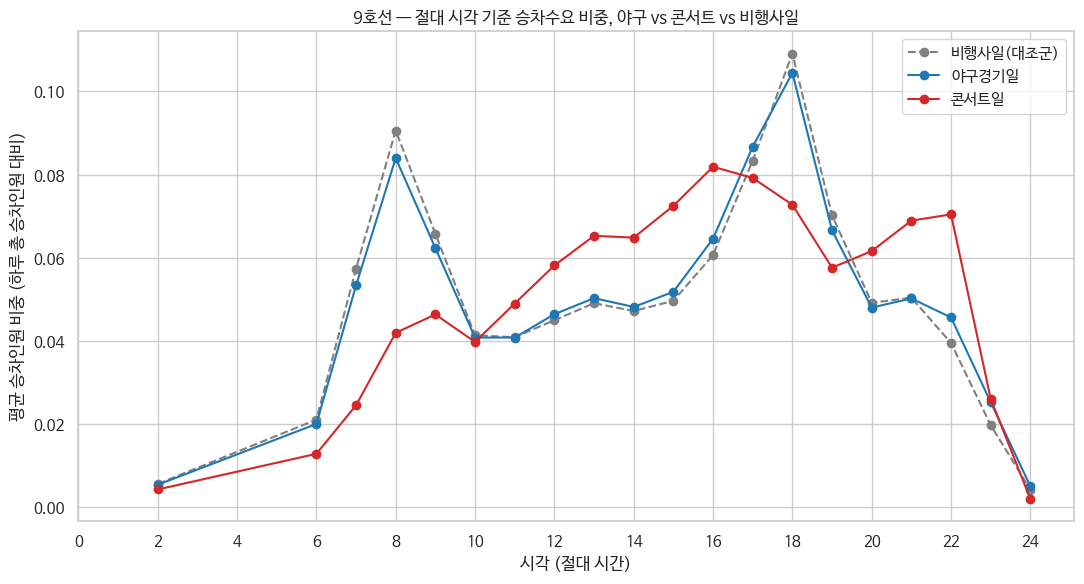

In [ ]:
# 9호선 기준 그룹별 평균 승차비중 계산
avg_non_event_9 = average_share_by_hour(non_event_dates_9, daily_pivot_9)
avg_baseball_9  = average_share_by_hour(baseball_days.index, daily_pivot_9)
avg_concert_9   = average_share_by_hour(concert_days.index, daily_pivot_9)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(avg_non_event_9.index, avg_non_event_9.values, marker="o", label="비행사일(대조군)", color="gray", linestyle="--")
ax.plot(avg_baseball_9.index, avg_baseball_9.values, marker="o", label="야구경기일", color="tab:blue")
ax.plot(avg_concert_9.index, avg_concert_9.values, marker="o", label="콘서트일", color="tab:red")

ax.set_xlabel("시각 (절대 시간)")
ax.set_ylabel("평균 승차인원 비중 (하루 총 승차인원 대비)")
ax.set_title("9호선 — 절대 시각 기준 승차수요 비중, 야구 vs 콘서트 vs 비행사일")
ax.set_xticks(range(0, 25, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 가설 4
### 행사 유형과 시간대에 따라 종합운동장역 2호선과 9호선의 승차량 증가율이 다르게 나타날 것이다.

In [ ]:
integration4_df = pd.read_csv(f'{base_path}/data/4차통합.csv')

# 필요없는 컬럼 제거
integration4_df.drop(['Unnamed: 0', '날짜'], axis=1, inplace=True)

/tmp/ipykernel_146190/3190065612.py:1: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  integration4_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


In [ ]:
# 종료시간 측정시작시간 측정종료시간 수송일자 컬럼의 데이터 타입을 datetime으로
integration4_df['최종종료시간'] = pd.to_datetime(integration4_df['최종종료시간'], errors='coerce',)
integration4_df['측정시작시간'] = pd.to_datetime(integration4_df['측정시작시간'], errors='coerce')
integration4_df['측정종료시간'] = pd.to_datetime(integration4_df['측정종료시간'], errors='coerce')
integration4_df['수송일자'] = pd.to_datetime(integration4_df['수송일자'], errors='coerce')

/tmp/ipykernel_146190/510070250.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  integration4_df['최종종료시간'] = pd.to_datetime(integration4_df['최종종료시간'], errors='coerce',)
/tmp/ipykernel_146190/510070250.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  integration4_df['측정시작시간'] = pd.to_datetime(integration4_df['측정시작시간'], errors='coerce')
/tmp/ipykernel_146190/510070250.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  integration4_df['측정종료시간'] = pd.to_datetime(integration4_df['측정종료시간'], errors='coerce')


In [ ]:
# 코로나시기는 아예 배제하고, 2022년부터 적용.
integration4_df = integration4_df[integration4_df['수송일자'].dt.year > 2021]

In [ ]:
# 행사 여부 체크
integration4_df['행사여부'] = integration4_df['제목'].notna().astype(bool)

In [ ]:
integration4_df['행사종료시'] = integration4_df['최종종료시간'].dt.strftime('%H:%M')

#### 행사종료시간 분포 확인

In [ ]:
event_df = integration4_df[integration4_df['행사여부']]

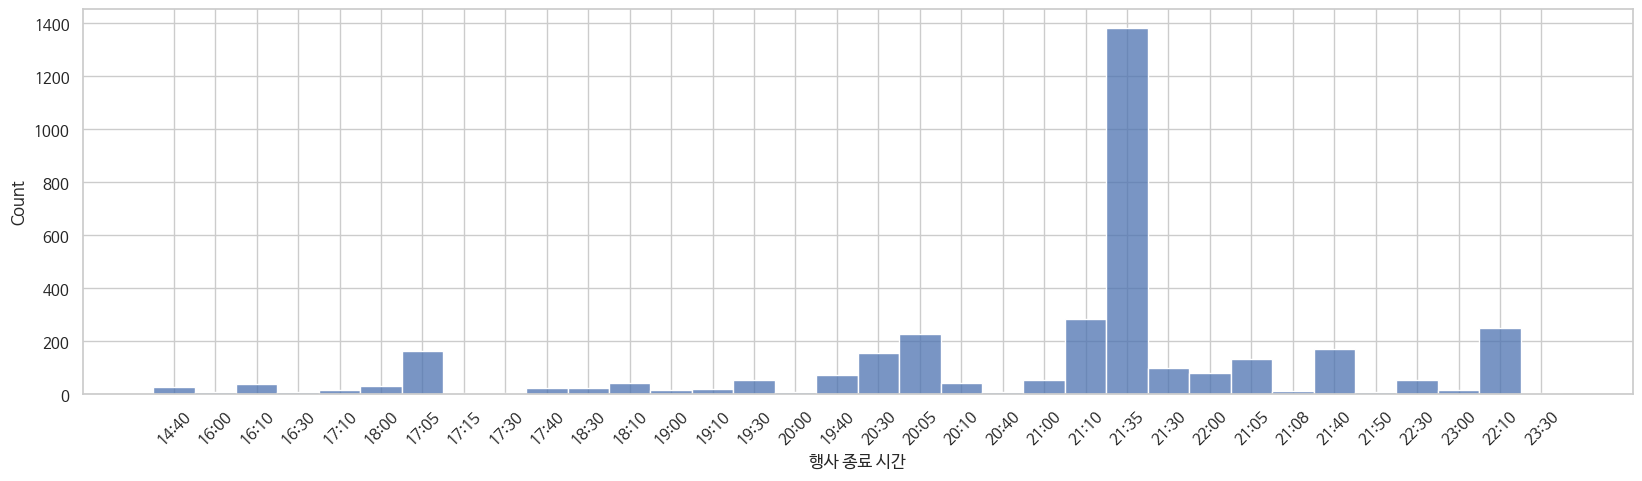

In [ ]:
plt.figure(figsize=(20,5))

sns.histplot(
    event_df['행사종료시'],
    bins=24
)
plt.xticks(rotation=45)
plt.xlabel('행사 종료 시간')
plt.show()

#### 행사가 있는날 vs 없는날 승차량 비교

In [ ]:
# 승차 데이터만 사용
ride_df = integration4_df[
    integration4_df['승하차구분'] == '승차'
].copy()

# 행사여부 컬럼 false = 비행사일 true는 행사일로 매핑
ride_df['행사여부'] = ride_df['행사여부'].map(
    {False: '비행사일', True: '행사일'}
    )

#### 행사 여부에 따른 호선별 승차인원 분포

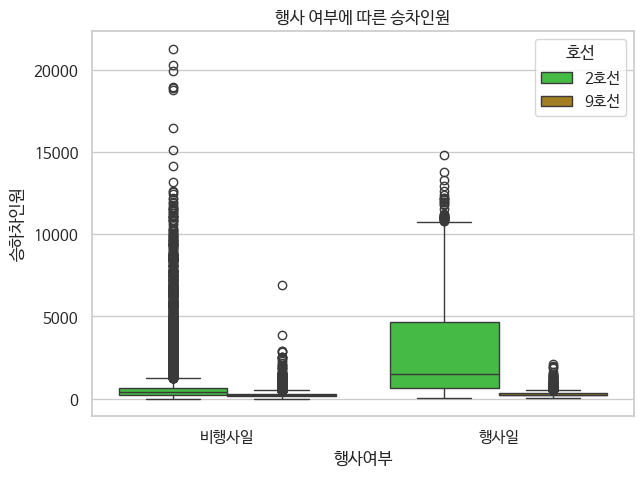

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=ride_df,
    x='행사여부',
    y='승하차인원',
    hue='호선',palette={
            '2호선': '#32cd32',
            '9호선': '#b8860b'
        },
)

plt.title("행사 여부에 따른 승차인원")
plt.show()

#### 시간대별 승차량 비교

In [ ]:
# 행사는 시간대 영향이 크기때문에 평균으로 확인함.
pivot = ride_df.pivot_table(
    values='승하차인원',
    index='시간대',
    columns='행사여부',
    aggfunc='mean'
)
pivot

행사여부,비행사일,행사일
시간대,,
06-07시간대,159.714237,NaN
06시이전,48.754962,NaN
07-08시간대,429.254278,NaN
08-09시간대,573.866872,NaN
09-10시간대,423.140657,NaN
10-11시간대,313.698152,NaN
11-12시간대,303.007187,NaN
12-13시간대,339.492471,NaN
13-14시간대,341.746407,NaN


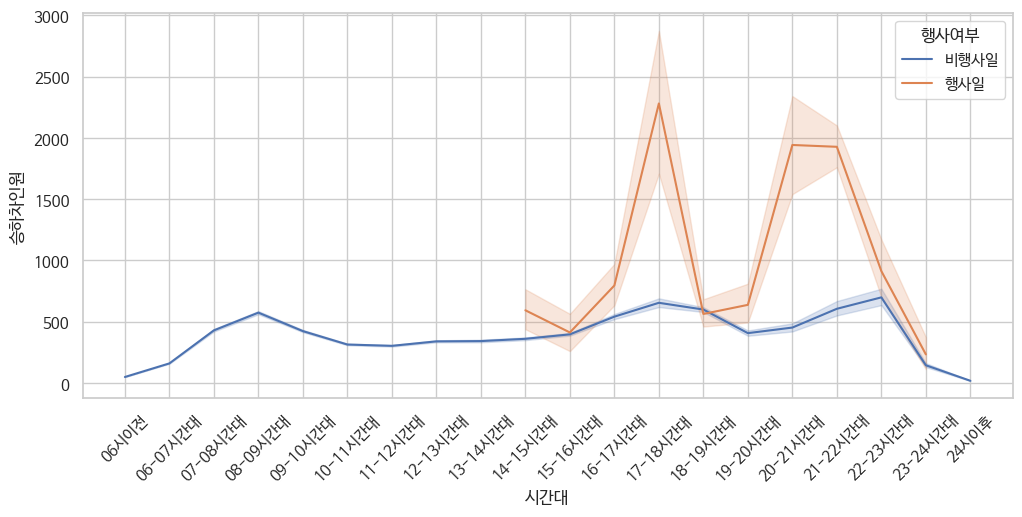

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=ride_df,
    x='시간대',
    y='승하차인원',
    hue='행사여부'
)

plt.xticks(rotation=45)
plt.show()

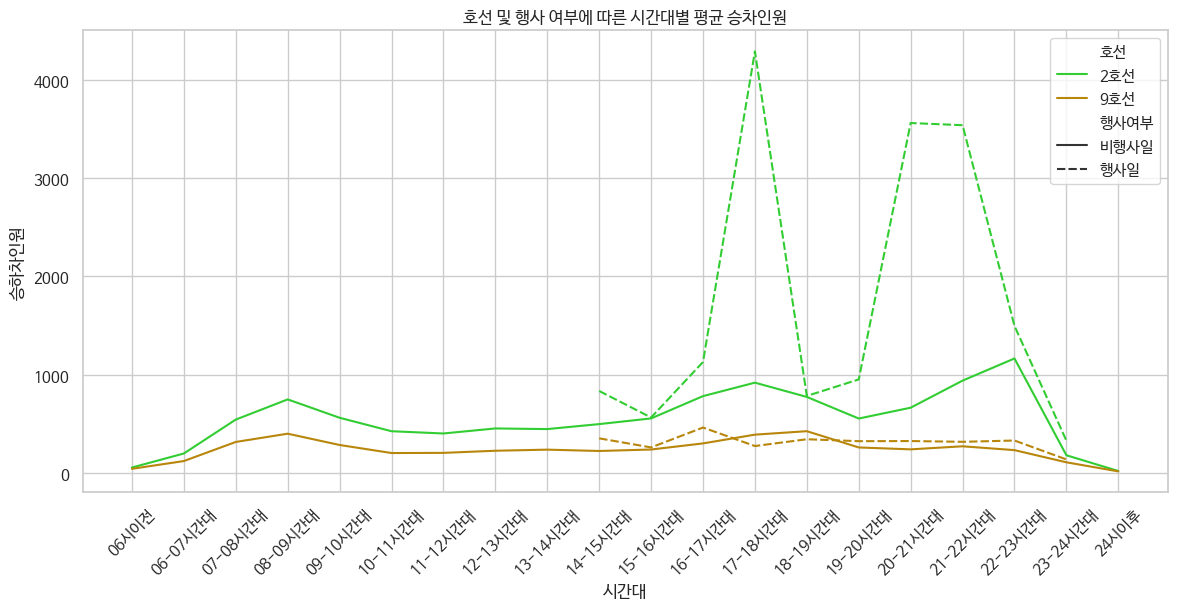

In [ ]:
# 호선까지 같이
plt.figure(figsize=(14,6))

sns.lineplot(
    data=ride_df,
    x='시간대',
    y='승하차인원',
    hue='호선',
    style='행사여부',
    estimator='mean',
    palette={
        '2호선': '#32cd32',
        '9호선': '#b8860b'
    },
    errorbar=None
)

plt.xticks(rotation=45)
plt.title('호선 및 행사 여부에 따른 시간대별 평균 승차인원')
plt.show()

#### 행사일 승차 데이터만 필터링

In [ ]:
event_ride_df = integration4_df[
    (integration4_df['승하차구분'] == '승차') &
    (integration4_df['행사여부'] == True)
].copy()

In [ ]:
# 스포츠 경기, 공연, 두개가 같이 열리는 복합행사, 이렇게 3가지로 구분
def classify_event(row):
    field = row['분야명']
    count = row['행사수']

    if count >=2 and '공연' in field and '스포츠 경기' in field:
        return '복합행사'
    elif '공연' in field:
        return '공연'
    elif '스포츠 경기' in field:
        return '스포츠 경기'
    else:
        return '기타'

event_ride_df['행사구분'] = event_ride_df.apply(classify_event, axis=1)

In [ ]:
# 행사 유형별 기술통계
event_type_summary = (
    event_ride_df.groupby('행사구분')['승하차인원']
    .agg(['count', 'mean', 'median', 'std', 'max'])
)

event_type_summary

,count,mean,median,std,max
행사구분,,,,,
공연,424,777.504717,342.0,1199.598885,13274.0
복합행사,256,2247.773438,645.5,3193.517601,13775.0
스포츠 경기,1100,1964.738182,354.0,2986.196974,14818.0


행사 구분별 승차인원 분포 확인

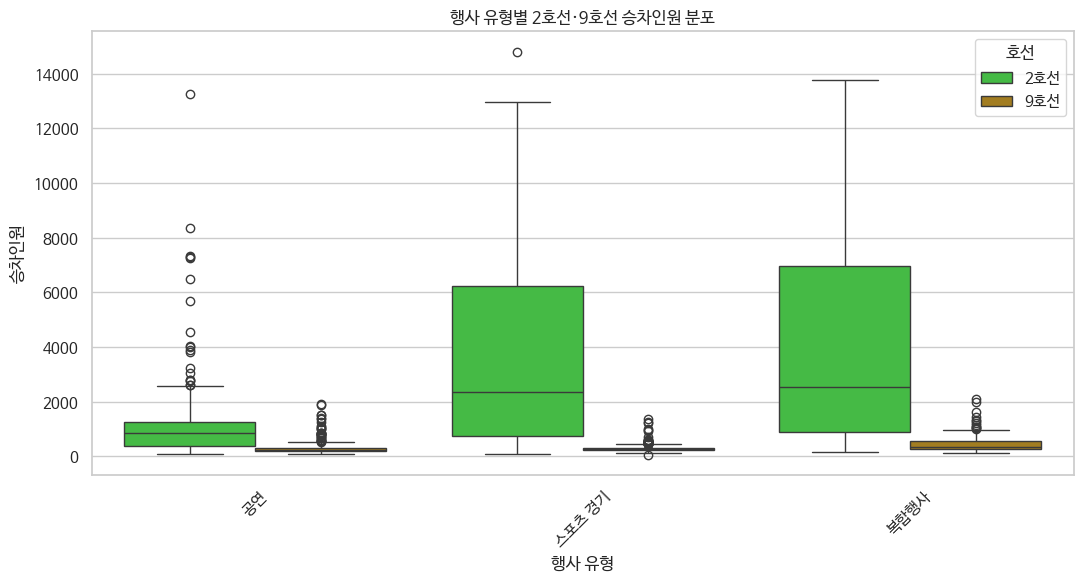

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=event_ride_df[
        event_ride_df['호선'].isin(['2호선', '9호선'])
    ],
    x='행사구분',
    y='승하차인원',
    hue='호선',
    palette={
            '2호선': '#32cd32',
            '9호선': '#b8860b'
        },
)

plt.xticks(rotation=45)
plt.title('행사 유형별 2호선·9호선 승차인원 분포')
plt.xlabel('행사 유형')
plt.ylabel('승차인원')
plt.tight_layout()
plt.show()

#### 하차 피크 확인

In [ ]:
alight_df = integration4_df[
    (integration4_df['승하차구분'] == '하차') &
        (integration4_df['행사여부'] == True)
].copy()

In [ ]:
# 행사구분 추가
alight_df['행사구분'] = alight_df.apply(classify_event, axis=1)

행사 유형별 시간대/호선별 평균 하차 인원

Text(0.5, 1.05, '행사 유형별 시간대·호선별 평균 하차인원')

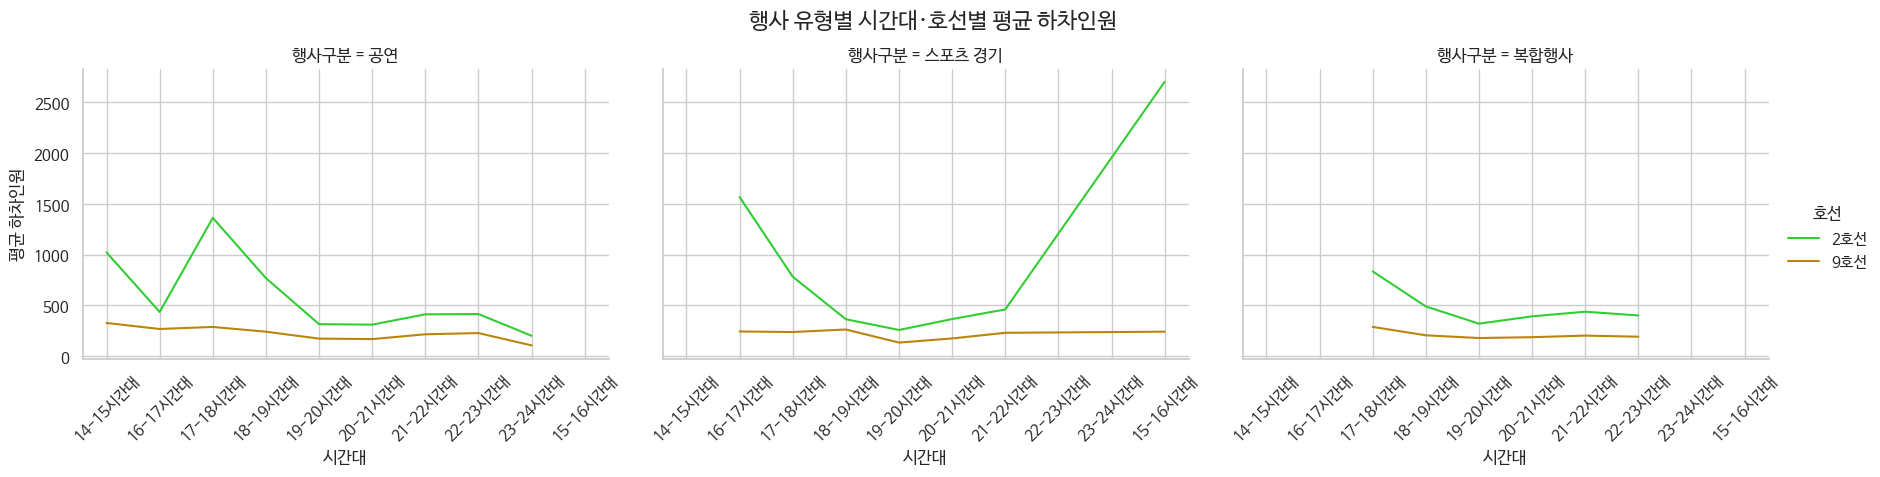

In [ ]:
g = sns.relplot(
    data=alight_df[
        (alight_df['행사여부']) &
        (alight_df['호선'].isin(['2호선', '9호선']))
    ],
    x='시간대',
    y='승하차인원',
    hue='호선',
    col='행사구분',
    palette={
            '2호선': '#32cd32',
            '9호선': '#b8860b'
        },
    kind='line',
    estimator='mean',
    errorbar=None,
    height=4,
    aspect=1.5
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
g.set_axis_labels('시간대', '평균 하차인원')
g.fig.suptitle(
    '행사 유형별 시간대·호선별 평균 하차인원',
    fontsize=16,
    y=1.05
)

### 승차량 증가율 계산

In [ ]:
# 비행사일의 평균을 기준으로 만들기
baseline = (
    ride_df[ride_df['행사여부'] == '비행사일']
    .groupby(['호선', '시간대', '요일'])['승하차인원'].mean().round(2)
    .reset_index()
    .rename(columns={'승하차인원': '기준승차인원'})
)

baseline

,호선,시간대,요일,기준승차인원
0,2호선,06-07시간대,금요일,229.78
1,2호선,06-07시간대,목요일,236.87
2,2호선,06-07시간대,수요일,234.29
3,2호선,06-07시간대,월요일,236.49
4,2호선,06-07시간대,일요일,91.07
...,...,...,...,...
275,9호선,24시이후,수요일,19.86
276,9호선,24시이후,월요일,12.50
277,9호선,24시이후,일요일,0.27
278,9호선,24시이후,토요일,0.17


In [ ]:
# 행사가 있는 날의 데이터만 추출.
event_df = ride_df[
    ride_df['행사여부'] == '행사일'
].copy()

In [ ]:
# 행사구분 추가
event_df['행사구분'] = event_df.apply(classify_event, axis=1)

In [ ]:
event_df = event_df.merge(
    baseline,
    on=['호선', '시간대', '요일'],
    how='left'
)

In [ ]:
event_df['승차량증가율'] = (
    (event_df['승하차인원'] - event_df['기준승차인원']) / event_df['기준승차인원'] * 100
).round(3)

In [ ]:
event_df.groupby(['행사구분', '호선'])['승차량증가율'].agg(
    ['mean', 'median', 'std', 'max']
)

mean    median         std       max
행사구분   호선                                             
공연     2호선    7.361354  -27.2385  143.045962  1011.344
       9호선   21.211033  -13.0630  111.476256   721.279
복합행사   2호선  218.877359   87.1355  313.192533  1182.815
       9호선   59.938469   20.8730  107.083048   562.742
스포츠 경기 2호선  268.823207  127.3495  379.105301  1794.712
       9호선    4.450933   -3.0910   45.354541   440.019

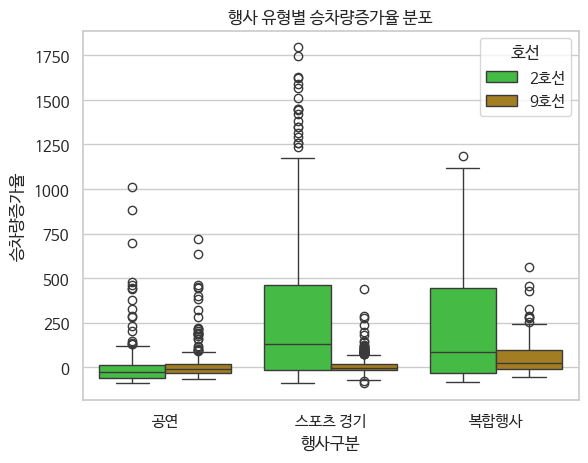

In [ ]:
sns.boxplot(
    data=event_df,
    x='행사구분',
    y='승차량증가율',
    hue='호선',
    palette={
            '2호선': '#32cd32',
            '9호선': '#b8860b'
        }
)

plt.title('행사 유형별 승차량증가율 분포')
plt.show()

### 증가율에 대해 시간대별 추가 분석

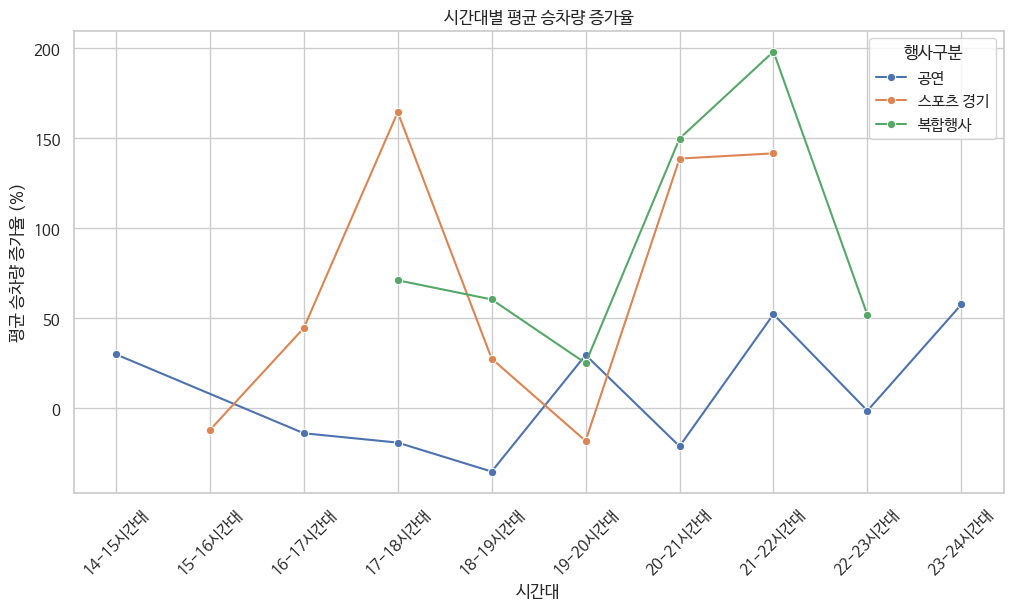

In [ ]:
# 시간대별 평균 승차량 증가율
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=event_df,
    x='시간대',
    y='승차량증가율',
    hue='행사구분',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title('시간대별 평균 승차량 증가율')
plt.xticks(rotation=45)
plt.xlabel('시간대')
plt.ylabel('평균 승차량 증가율 (%)')

plt.show()

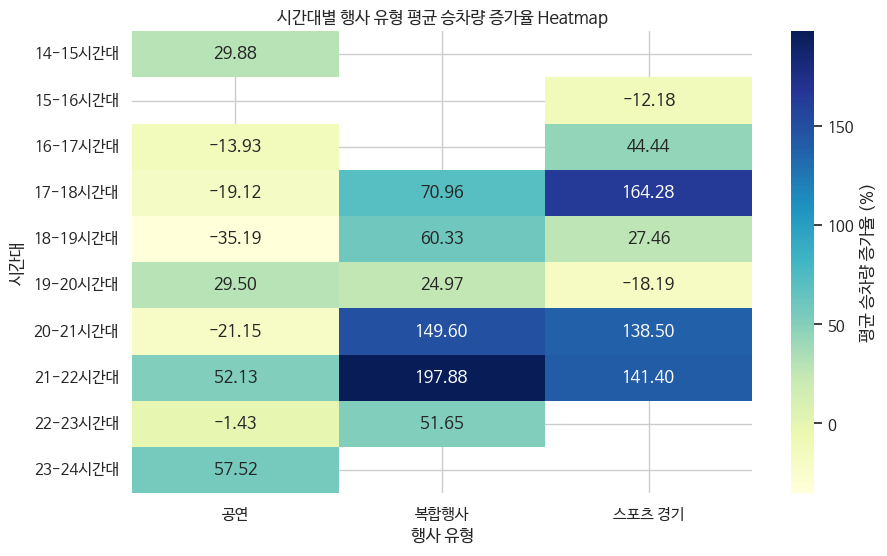

In [ ]:
# 시간대와 행사유형 heatmap
pivot = event_df.pivot_table(
    values='승차량증가율',
    index='시간대',
    columns='행사구분',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': '평균 승차량 증가율 (%)'}
)
plt.title('시간대별 행사 유형 평균 승차량 증가율 Heatmap')
plt.xlabel('행사 유형')
plt.ylabel('시간대')

plt.show()

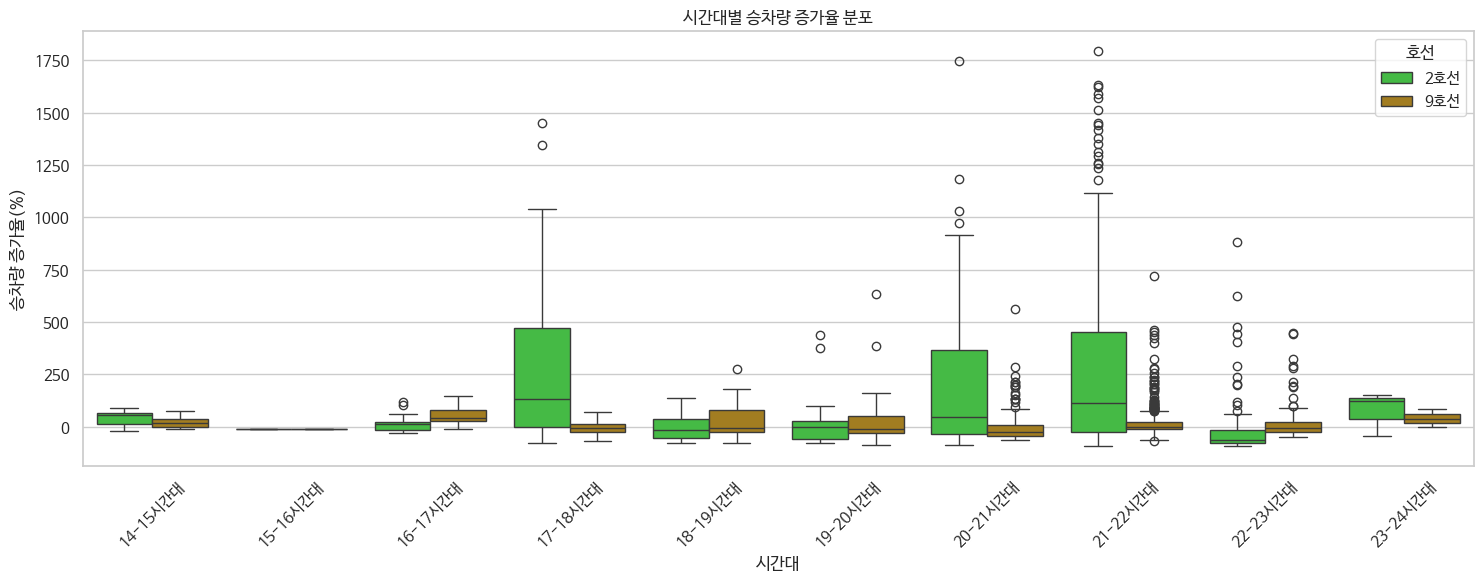

In [ ]:
plt.figure(figsize=(15, 6))

sns.boxplot(
    data=event_df,
    x='시간대',
    y='승차량증가율',
    hue='호선',
    palette={
            '2호선': '#32cd32',   # 파란색
            '9호선': '#b8860b'    # 주황색
        },
)

plt.title('시간대별 승차량 증가율 분포')
plt.xlabel('시간대')
plt.ylabel('승차량 증가율(%)')
plt.xticks(rotation=45)

plt.legend(title='호선')
plt.tight_layout()
plt.show()

## 가설 5
### 가설 같은 유형의 행사라도 평일/주말에 따라 승하차량과 수요가 집중되는 시간대가 다르게 나타난다.

In [ ]:
TIME_ORDER = [
    '06시이전', '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대',
    '10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대',
    '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대', '19-20시간대',
    '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후'
]



integration5_df = pd.read_csv(f'{base_path}/data/4차통합.csv')
integration5_df['시간대'] = pd.Categorical(
    integration5_df['시간대'], categories=TIME_ORDER, ordered=True)

# 중복행 재확인 (2차통합에서 있었던 문제가 계속 해결된 상태인지 체크)
key_cols = ['통합연번', '수송일자', '호선', '역번호', '역명', '승하차구분', '시간대', '승하차인원']
dup_count = integration5_df.duplicated(subset=key_cols, keep=False).sum()
# print(f"중복행: {dup_count}건 (0이면 정상)") -> 0

/tmp/ipykernel_146190/525531392.py:10: DtypeWarning: Columns (23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  integration5_df = pd.read_csv(f'{base_path}/data/4차통합.csv')


### 행사 '날짜' 단위로 전체 시간대 복원

`제목`이 태깅된 시간대는 행사당 1~2개뿐이므로, 먼저 행사가 열린 (날짜, 분야명) 목록만 뽑고
그 날짜에 해당하는 전체 20개 시간대 레코드를 원본 df에서 다시 가져옴.
분석은 **단일 분야(공연 또는 스포츠 경기)만 열린 날**을 기준으로 함 (혼합일은 제외).

In [ ]:
event_days = (
    integration5_df[integration5_df['분야명'].isin(['공연', '스포츠 경기'])][['수송일자', '분야명']]
    .drop_duplicates()
)
print(f"행사일(날짜x분야, 단일분야 기준) {len(event_days):,}건 추출")

event_df = integration5_df.merge(event_days, on='수송일자', suffixes=('', '_evday'))
event_df['분야명'] = event_df['분야명_evday']  # 그날의 분야명으로 통일

행사일(날짜x분야, 단일분야 기준) 928건 추출


### 분야별(공연/스포츠) 평일 vs 주말 하차·승차 패턴 (2022년 이후)

In [ ]:
# 코로나 제외
df_recent = integration5_df[integration5_df['연도'] >= 2022].copy()

In [ ]:
event_days_recent = (
    df_recent[df_recent['분야명'].isin(['공연', '스포츠 경기'])][['수송일자', '분야명']]
    .drop_duplicates()
)

event_df_recent = df_recent.merge(event_days_recent, on='수송일자', suffixes=('', '_evday'))
event_df_recent['분야명'] = event_df_recent['분야명_evday']

In [ ]:
compare_rows = []
for cat in ['공연', '스포츠 경기']:
    for gubun in ['하차', '승차']:
        full_piv = (event_df[(event_df['분야명'] == cat) & (event_df['승하차구분'] == gubun)]
                    .groupby(['요일구분', '시간대'], observed=False)['승하차인원'].mean().unstack('요일구분'))
        recent_piv = (event_df_recent[(event_df_recent['분야명'] == cat) & (event_df_recent['승하차구분'] == gubun)]
                      .groupby(['요일구분', '시간대'], observed=False)['승하차인원'].mean().unstack('요일구분'))
        for wd in ['평일', '주말']:
            compare_rows.append({
                '분야': cat, '구분': gubun, '요일구분': wd,
                '전체기간_피크시간대': full_piv[wd].idxmax(), '전체기간_피크인원': round(full_piv[wd].max(), 0),
                '2022이후_피크시간대': recent_piv[wd].idxmax(), '2022이후_피크인원': round(recent_piv[wd].max(), 0),
            })

compare_df = pd.DataFrame(compare_rows)
compare_df

,분야,구분,요일구분,전체기간_피크시간대,전체기간_피크인원,2022이후_피크시간대,2022이후_피크인원
0,공연,하차,평일,18-19시간대,1495.0,18-19시간대,1495.0
1,공연,하차,주말,16-17시간대,1133.0,16-17시간대,1143.0
2,공연,승차,평일,21-22시간대,913.0,21-22시간대,917.0
3,공연,승차,주말,21-22시간대,1090.0,21-22시간대,1094.0
4,스포츠 경기,하차,평일,18-19시간대,1927.0,18-19시간대,2221.0
5,스포츠 경기,하차,주말,16-17시간대,1194.0,16-17시간대,1540.0
6,스포츠 경기,승차,평일,21-22시간대,1589.0,21-22시간대,1948.0
7,스포츠 경기,승차,주말,20-21시간대,930.0,20-21시간대,1209.0


/tmp/ipykernel_146190/1672833863.py:30: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_146190/1672833863.py:30: UserWarning: Glyph 9918 (\N{BASEBALL}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_146190/1672833863.py:31: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) NanumBarunGothic.
  plt.savefig('eda_1_category_lineplot_2022plus.png', dpi=200)
/tmp/ipykernel_146190/1672833863.py:31: UserWarning: Glyph 9918 (\N{BASEBALL}) missing from font(s) NanumBarunGothic.
  plt.savefig('eda_1_category_lineplot_2022plus.png', dpi=200)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9918 (\N{BASEBALL}) missing from font(s) NanumBaru

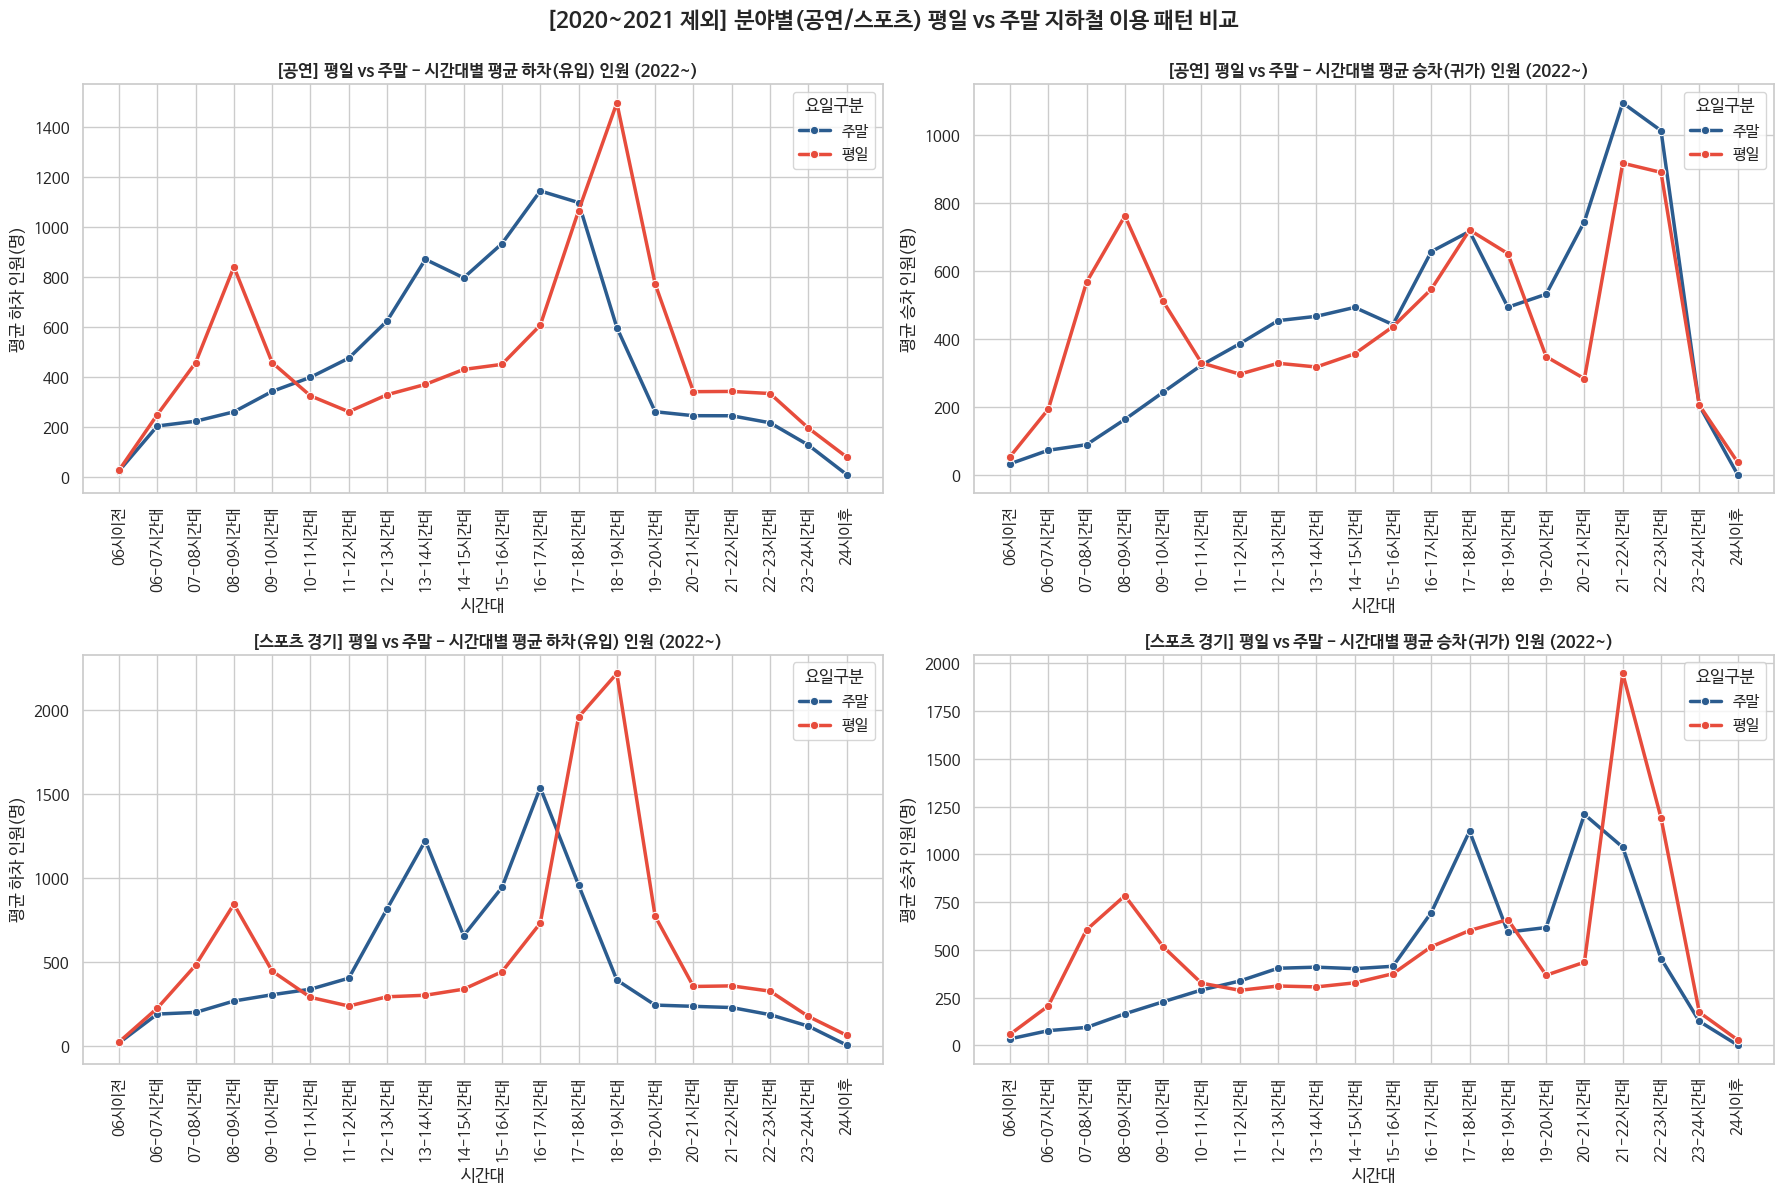

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
palette = ['#2b5c8f', '#e74c3c']

for row, category in enumerate(['공연', '스포츠 경기']):
    cat_df = event_df_recent[event_df_recent['분야명'] == category]
    agg = (
        cat_df.groupby(['요일구분', '시간대', '승하차구분'], observed=False)['승하차인원']
        .mean()
        .reset_index()
    )
    icon = '🎭' if category == '공연' else '⚾'

    sns.lineplot(
        data=agg[agg['승하차구분'] == '하차'], x='시간대', y='승하차인원', hue='요일구분',
        marker='o', linewidth=2.5, ax=axes[row, 0], palette=palette
    )
    axes[row, 0].set_title(f'{icon} [{category}] 평일 vs 주말 - 시간대별 평균 하차(유입) 인원 (2022~)', fontsize=12, fontweight='bold')
    axes[row, 0].set_ylabel('평균 하차 인원(명)')
    axes[row, 0].tick_params(axis='x', rotation=90)

    sns.lineplot(
        data=agg[agg['승하차구분'] == '승차'], x='시간대', y='승하차인원', hue='요일구분',
        marker='o', linewidth=2.5, ax=axes[row, 1], palette=palette
    )
    axes[row, 1].set_title(f'{icon} [{category}] 평일 vs 주말 - 시간대별 평균 승차(귀가) 인원 (2022~)', fontsize=12, fontweight='bold')
    axes[row, 1].set_ylabel('평균 승차 인원(명)')
    axes[row, 1].tick_params(axis='x', rotation=90)

plt.suptitle('[2020~2021 제외] 분야별(공연/스포츠) 평일 vs 주말 지하철 이용 패턴 비교', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('eda_1_category_lineplot_2022plus.png', dpi=200)
plt.show()

### 핵심 귀가 시간대 승차 집중도

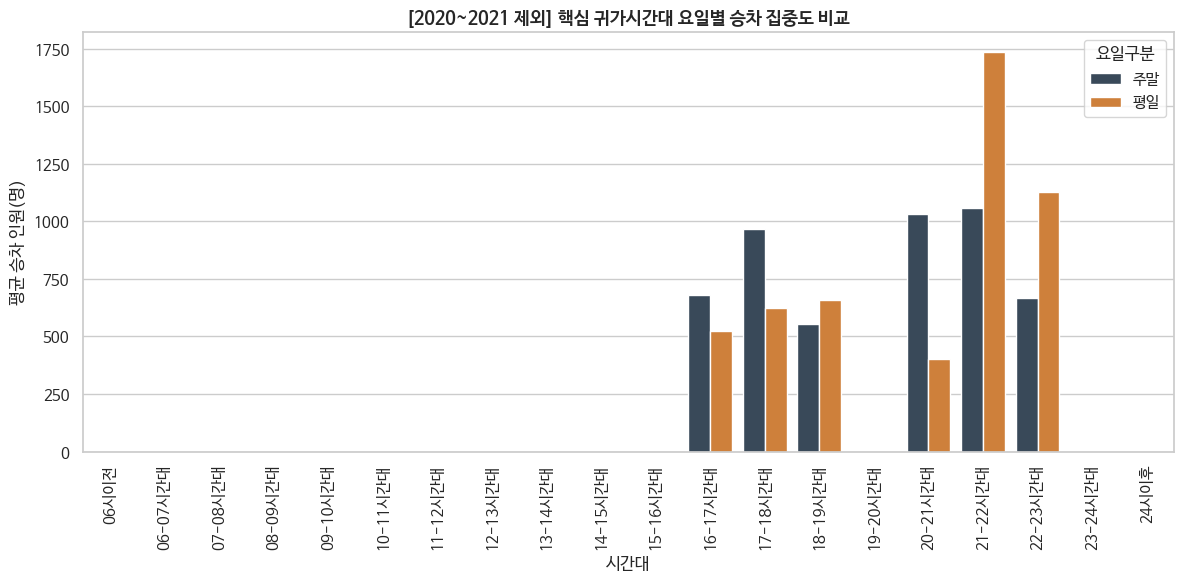

In [ ]:
key_slots = ['16-17시간대', '17-18시간대', '18-19시간대', '20-21시간대', '21-22시간대', '22-23시간대']
boarding_recent = event_df_recent[event_df_recent['승하차구분'] == '승차']
key_agg_recent = (
    boarding_recent[boarding_recent['시간대'].isin(key_slots)]
    .groupby(['요일구분', '시간대'], observed=False)['승하차인원']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=key_agg_recent, x='시간대', y='승하차인원', hue='요일구분', palette=['#34495e', '#e67e22'])
plt.title('[2020~2021 제외] 핵심 귀가시간대 요일별 승차 집중도 비교', fontsize=13, fontweight='bold')
plt.ylabel('평균 승차 인원(명)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('eda_2_key_hour_barplot_2022plus.png', dpi=200)
plt.show()

### 프로야구 히트맵(승/하차 분리)
평균 기준.

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/tmp/ipykernel_146190/133890507.py:17: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_146190/133890507.py:18: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  plt.savefig('eda_3_baseball_heatmap_2022plus.png', dpi=200)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


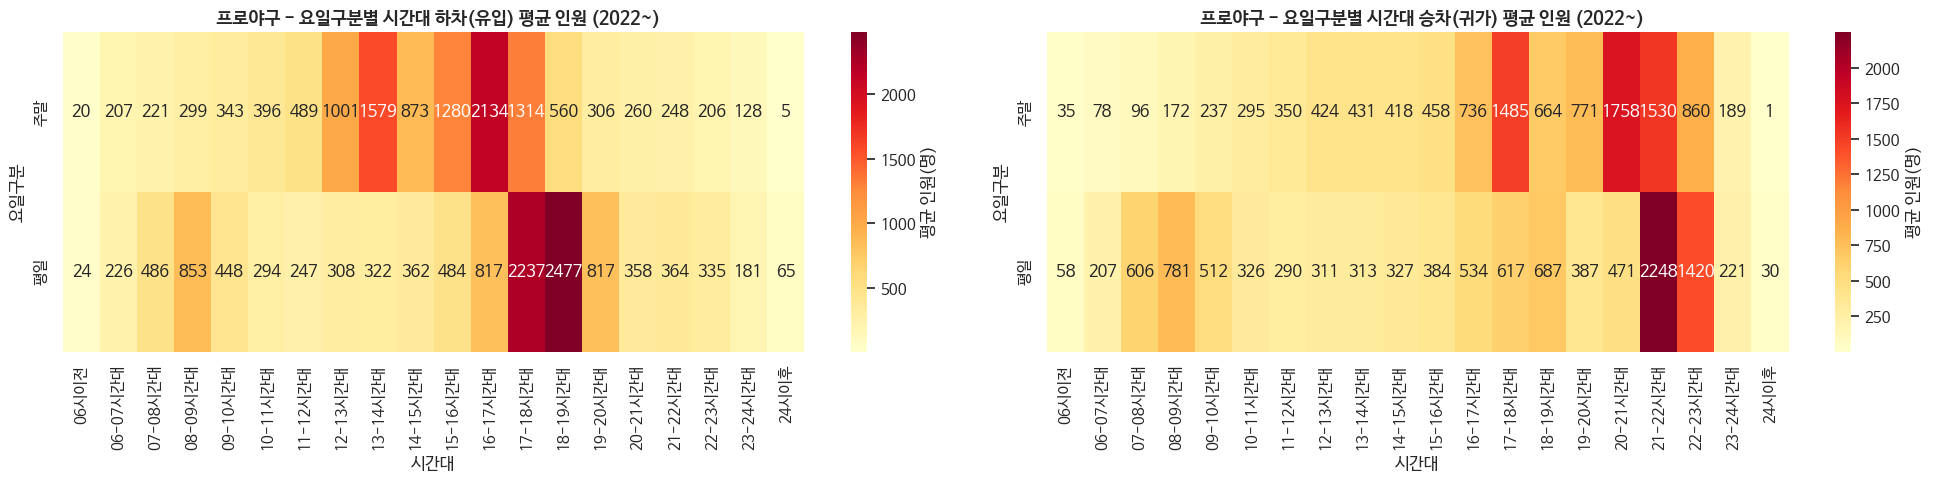

In [ ]:
bb_days_recent = df_recent[df_recent['제목'].str.contains('프로야구', na=False)][['수송일자']].drop_duplicates()
bb_df_recent = df_recent.merge(bb_days_recent, on='수송일자')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
for i, gubun in enumerate(['하차', '승차']):
    pivot = bb_df_recent[bb_df_recent['승하차구분'] == gubun].pivot_table(
        index='요일구분', columns='시간대', values='승하차인원',
        aggfunc='mean', observed=False
    )
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': '평균 인원(명)'}, ax=axes[i])
    label = '유입' if gubun == '하차' else '귀가'
    axes[i].set_title(f'🔥 프로야구 - 요일구분별 시간대 {gubun}({label}) 평균 인원 (2022~)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일구분')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('eda_3_baseball_heatmap_2022plus.png', dpi=200)
plt.show()

# 결과해석 및 결론 도출

## 가설 1에 대한 결론
1. 포커스 ⇒ 행사 종료시간이 많이 분포되어 있는 21-22시간대를 중점적으로
2. **대부분의 요일에서 21-22시간대에 행사일의 경우가 비행사일의 경우보다 평균 승/하차량이 높게 나옴**
3. 월요일의 경우, 행사 자체 데이터가 적어 신뢰도 있는 자료를 기대하기 어려움 ⇒ 한계
4. 승차의 경우, 행사 종료 시간대에 수요 증가율이 높았음 (동일 요일별로 비교 시)
5. 하차의 경우, 행사 시작 1시간 전 시간대에 수요 증가율이 높았음 (동일 요일별로 비교 시)
6. 요일별 패턴이 따로 있다기보단, 평일/주말의 패턴이 존재하는 것으로 보임

⇒ 즉, 행사일의 경우 동일 요일의 비행사일보다 비교적 평균 승/하차량이 높게 나오고 특히, 행사 종료 시간이 많이 분포되어있는 21-22시간대에 대부분의 요일에서 평균 승/하차량이 높음. +) 동일 요일로 비교 시, 승차는 행사 종료 시간대, 하차는 행사 시작 1시간 전 시간대에 수요 증가율이 높았음

## 가설2에 대한 결론
1. 늦은 저녁~야간 시간대 종료 행사 이후 승차 수요가 증가하는 경향을 확인하여 행사 종료 이후 귀가 수요 증가 가설을 확인하였다.
2. 시간대별 평균 승차인원 분석 결과, 평일과 주말 모두 20시 이후 야간 시간대에서 승차 수요가 재상승하는 패턴이 나타났으며, 특히 평일 2호선은 21~22시 구간에서 높은 승차인원을 기록하였다.
3. 피크타임 및 연도별 분석에서도 야간 재상승 피크가 반복적으로 나타나 특정 기간에 한정된 현상이 아닌 지속적인 수요 패턴임을 확인하였다.
4. 또한 행사 최종 종료 시각별 분석 결과, 평일은 21시 종료 행사, 주말은 17시, 20시, 23시 종료 행사에서 높은 승차 수요가 나타났으며, 행사 종료 이후 귀가 승객 유입이 야간 승차 수요 증가에 영향을 준 것으로 판단된다.
5. 2호선과 9호선 비교 결과, 행사 종료 이후 시간대인 20~22시 구간에서 2호선 승차 수요가 9호선 대비 크게 증가하는 모습을 확인하였다.
6. 이를 통해 행사 종료 후 귀가 승객은 2호선 중심으로 집중되는 것으로 판단되며, 특히 야간 재상승 피크가 발생하는 20~22시 시간대를 중심으로 2호선 증편 우선 검토가 필요할 것으로 판단된다.

## 가설3에 대한 결론
1. 행사 종류 별 노선 별 승차비중 비교 했을 때 **가설과 달리 야구경기의 경우 경기가 종료된 직후 관객이 바로 지하철로 탑승했고, 콘서트의 경우 공연장에 1시간가량 더 머물렀다고 추측해볼 수 있다.**
2. 현재 행사 데이터의 경우 종료시각이 명확히 기록되지 않은 건이 많아, 종료시각이 없는 데이터는 각 행사 유형별 평균 진행시간을 시작시각에 더한 대체값으로 채워져 있었다. 야구와 콘서트는 실제값 확인 비율 자체는 비슷했으나(11%대), 콘서트는 표본 수(4건)가 절대적으로 적어 강건성 검증에 적합하지 않다고 판단하고, 야구경기에 대해서만 강건성 검증을 진행하였다. **실제 데이터와 전체 데이터 간에 차이가 있었다.** 다만 표본 수가 4건에 불과해 이 차이가 실제 패턴인지 우연인지 통계적으로 판단하기 어렵다. 날씨 등 개별 날짜의 특수 변수가 영향을 줬을 가능성도 배제할 수 없으나, 이를 뒷받침할 별도 데이터 확인은 진행하지 않았으므로 원인을 특정하지 않고 표본 부족에 따른 한계로 정리한다.
3. 행사일의 승차비중을 비행사일과 비교한 결과, 2호선은 비행사일 대비 야구·콘서트 각각에서 뚜렷한 차이를 보였다. 반면 9호선은 야구경기일과 비행사일 간 차이가 거의 없었으나, 콘서트가 있던 날은 비행사일과 차이를 보였다. 이는 잠실야구장과 콘서트 개최 장소(주경기장/실내체육관 등)가 2호선·9호선 각 역과의 접근성·환승 동선에서 차이가 있어, 노선별로 실제 이용객 유입에 미치는 영향이 다르게 나타났을 가능성을 시사한다.

## 가설4에 대한 결론
1. 행사 유형에 따라 이용객의 이동 패턴이 다르게 나타났다. 공연의 경우 하차는 오후-저녁시간대가 모두가 증가하고 승차는 20-22시 사이가 피크 이지만 스포츠 경기같은 경우 경기시작 전과 경기 종료 이 두 시간대가 집중적으로 급격히 증가하였다.

2. 행사 이용객은 전체적으로 9호선보다 2호선을 더 많이 이용한다.
모든 행사 유형에서 **2호선의 승차 및 하차 인원이 9호선보다 많았다.** 증가율 또한 대부분 시간대에서 2호선이 더 높게 나타났으며, 이는 행사 관람객이 이동 시 2호선을 상대적으로 많이 이용함을 의미한다.

=> 행사 유형에 따라 노선별로 승차 증가율은 다르게 나타났다.

- 증가율을 이용하여 행사로 인해 추가 발생한 수요를 정량적으로 비교할 수 있었다.

## 가설5에 대한 결론
1. **유입(하차) 피크 시간대가 요일에 따라 이동한다**
공연·스포츠 둘 다 동일하게 2시간 앞당겨짐. 종목 고유 특성이 아니라 "요일" 자체가 만드는 차이임을 뒷받침한다.
2. 귀가(승차) 방향성도 종목마다 다르다
스포츠는 주말이 더 일찍 끝나는데, 공연은 반대로 주말이 더 늦게까지 붐빔. 같은 방향이 아니라 종목 x 요일 조합에 따라 방향 자체가 갈린다.
3. 코로나 기간(2020~2021) 제외 검증 결과 — 코로나 시기가 실제로 수치를 낮춤
공연은 2020-2021 포함 여부와 거의 무관하지만, 스포츠 경기는 2020-2021을 빼면 피크 인원이 15-30% 더 커진다. 순수하게 정상 운영 시기만 보면 실제 수요는 이전보다 더 크다. 다만 피크 시간대 자체(언제 붐비는지)는 전혀 안 바뀐다.

=> "평일/주말"이라는 요일 변수는 모든 행사에 공통으로 작용하는 1차 효과(피크 이동, 형태 변화) 와, 종목에 따라 다르게 작용하는 2차 효과(귀가 방향성) 를 동시에 만들어낸다.

# 최종결론.
# -> 행사 종료 후 지하철 수요 대응 우선순위 및 증편 편수 산정 시도
1차로는 행사일과 비행사일의 승차 인원을 비교해 우선 대응 노선과 시간대를 정했고, 방향별 혼잡도 자료를 참고해 어느 방향을 우선적으로 관리해야 하는지도 확인했다.

이후 2차로는 행사 종료 후 증가한 승객 수를 기준으로 실제 열차를 몇 편 더 투입해야 하는지까지 계산해보려고 했다.


---
## 1. 우선 대응 노선

행사일과 동일 연도·동일 요일의 비행사일을 비교한 결과, 행사 종료 후 승차 인원 증가는 9호선보다 2호선에서 크게 나타났다.

2호선은 행사 종료가 포함된 시간대에 승차 인원이 비행사일보다 평균 약 2,381명 증가했고, 종료 후 1시간대에도 약 1,408명 증가했다.

반면 9호선은 종료 포함 시간대에 약 85명, 종료 후 1시간대에 약 136명 증가해 2호선보다 증가 규모가 작았다.

따라서 행사 종료 후 수요 대응은 9호선보다 2호선을 우선하는 것이 적절하다고 판단했다.
| 호선 | 상대시간대 | 평균 증가 인원 | 판단 |
| --- | --- | --- | --- |
| 2호선 | 종료 포함 시간대 | 약 2,381명 | 최우선 대응 |
| 2호선 | 종료 후 1시간대 | 약 1,408명 | 추가 관리 필요 |
| 9호선 | 종료 포함 시간대 | 약 85명 | 증가 규모 작음 |
| 9호선 | 종료 후 1시간대 | 약 136명 | 탄력 대응 |

---
## 2. 우선 대응 시간대

행사 종료 후 승차 수요는 행사가 종료된 시간대에 가장 크게 증가했고, 종료 후 1시간대까지 증가가 이어졌다.

따라서 행사 종료 직후 한 시간만 관리하기보다, 행사 종료가 포함된 시간대부터 종료 후 1시간까지 연속해서 관리할 필요가 있다.

행사가 주로 21시부터 22시 사이에 종료되는 점을 고려하면 21시부터 23시 사이가 주요 관리 시간대가 된다.

정리하면 다음과 같다.

- 1차 관리 시간대: 행사가 종료된 시간대
- 2차 관리 시간대: 행사 종료 후 1시간대
- 주요 운영 시간: 21시부터 23시 사이


---
## 3. 방향별 우선순위 확인

종합운동장역 승차 데이터에는 2호선 내선·외선과 9호선 상선·하선 방향이 구분되어 있지 않다.

따라서 2020~2025년 시간대별 방향 혼잡도의 평균을 계산하고, 각 방향의 혼잡도가 전체에서 차지하는 비중을 참고해 방향별 우선순위를 확인했다.

다만 혼잡도에는 종합운동장역에서 새로 탄 승객뿐만 아니라 이전 역부터 이미 열차에 타고 있던 승객도 포함되어 있다.

따라서 방향별 혼잡도 비중을 실제 행사 승객의 이동 방향 비율로 볼 수는 없다. 방향을 확정하기 위한 자료라기보다, 기존에 어느 방향의 부담이 더 큰지 확인하기 위한 참고 자료로 활용했다.
### 평일 2호선

평일 21시부터 23시 사이에는 외선 혼잡도 비중이 내선보다 높게 나타났다.

| 시간대 | 내선 혼잡도 비중 | 외선 혼잡도 비중 |
| --- | --- | --- |
| 21:00~21:59 | 33.0% | 67.0% |
| 22:00~22:59 | 30.2% | 69.8% |
| 23:00~23:59 | 29.9% | 70.1% |

행사 승객의 67~70%가 외선으로 이동한다고 단정할 수는 없지만, 평일 저녁에는 외선의 기존 부담이 내선보다 큰 것으로 나타났다.

따라서 평일 행사 종료 시에는 2호선 외선을 우선 관리 방향으로 선정했다.

### 주말 2호선

주말 저녁에는 평일과 달리 내선과 외선의 혼잡도 비중이 비슷하게 나타났다.

| 시간대 | 내선 혼잡도 비중 | 외선 혼잡도 비중 |
| --- | --- | --- |
| 21:00~21:59 | 50.4% | 49.6% |
| 22:00~22:59 | 50.7% | 49.3% |
| 23:00~23:59 | 45.7% | 54.3% |

한쪽 방향이 계속 높게 나타난 평일과 달리, 주말은 내선과 외선의 차이가 크지 않았다.

따라서 주말에는 특정 방향만 우선하기보다 내선과 외선 양방향을 함께 관리하는 것이 적절하다고 판단했다.

### 9호선

9호선은 평일 저녁에 상선 혼잡도 비중이 하선보다 높게 나타났다.

| 시간대 | 상선 혼잡도 비중 | 하선 혼잡도 비중 |
| --- | --- | --- |
| 21:00~21:59 | 69.6% | 30.4% |
| 22:00~22:59 | 67.9% | 32.1% |
| 23:00~23:59 | 76.5% | 23.5% |

다만 행사 종료 후 9호선의 추가 승차 인원 자체가 2호선보다 작았다.

또한 9호선은 일반과 급행의 실제 운행 횟수가 다른데, 현재 분석에서는 일반과 급행 혼잡도를 동일한 비중으로 평균 냈다는 한계도 있다.

따라서 9호선은 기본적인 우선 증편 대상으로 선정하기보다, 관람객 규모가 큰 행사나 여러 행사가 동시에 열리는 경우에 현장 상황을 보고 탄력적으로 대응하는 것이 적절하다고 판단했다.



---

# 1차 분석 결과

현재 데이터를 기준으로 행사 종료 후 수요 대응 우선순위는 다음과 같이 정리할 수 있다.

### 1순위

평일 행사 종료 시간대와 종료 후 1시간의 2호선 외선

2호선의 승차 증가량이 9호선보다 컸고, 평일 저녁에는 외선 혼잡도 비중도 내선보다 높게 나타났다.

따라서 평일 21시부터 23시 사이의 2호선 외선을 가장 먼저 관리해야 할 구간으로 선정했다.

### 2순위

주말 행사 종료 시간대의 2호선 내선·외선 양방향

주말에는 내선과 외선의 혼잡도 비중 차이가 크지 않았기 때문에 특정 방향에만 대응하기보다 양방향을 함께 관리할 필요가 있다.

### 9호선

9호선은 행사 종료 후 증가 인원이 2호선보다 작아 기본 우선 대응 노선에서는 제외했다.

다만 대형 행사나 복합행사처럼 평소보다 수요가 크게 증가할 가능성이 있는 경우에는 현장 혼잡 상황에 따라 추가 대응을 검토한다.



---
## 2차 분석: 추가 편성 대수 산정 시도

**행사별 평균 관중 수 도출**

>
>
> - 프로야구 : 18,390명
> - 프로축구 : 10,490명
> - 주경기장 대형 콘서트 : 45,000명
> - 잠실실내체육관 콘서트 : 10,000명
>
> 프로야구 참고자료 : (일자별 관중 현황 | KBO 정규시즌 | 관중 현황 | 기록/순위 | KBO )
> 프로축구 참고자료 : ( K LEAGUE )
> ※ 콘서트와 같은 공연 : 기존 가용 객석에서 무대설치를 고려하여 보수적으로 설정
>

**행사 종료 이 후 지하철 이용량 추정**

>
>
>
> 2호선과 9호선 이용 ⇒ 7:3 (수용 인원을 기준으로 잡음)
> 2호선 내선 : 외선 ⇒ 6:4 (혼잡도 데이터 이용)
> 9호선 하행 : 상행 ⇒ 6:4 (혼잡도 데이터 이용)
>

**열차 1편당 여유 수용량**

> 정원 * (1 - 평균 혼잡도)
>

**행사별 종료시간대**

> 행사의 카테고리별 종료시간 최빈값을 사용 + 행사 종료 직후 1시간까지 수요 증가가 이어짐

- 스포츠 분야 : 21:35 ~ 22:35
- 공연/콘서트 분야 : 22:10 ~ 23:10
>

**필요 증편 대수**

> 방향별 예상 추가 수요 / 열차 1편당 여유 수용량
>

행사 종료 이 후, 수요가 증가하는 1시간 사이 행사 종료로 인한 추가 수요를 모두 소화하기 위해서는 다음과 같은 열차 증편이 필요하다

| 행사 | 2호선 | 9호선 | 증편 시간대 |
| --- | --- | --- | --- |
| 프로야구 | 외선 3대 / 내선 2대 | 상행 2대 / 하행 1대 | 21:35 ~ 22:35 |
| 프로축구 | 외선 2대 / 내선 1대 | 상행 1대 / 하행 2대 | 21:35 ~ 22:35 |
| 주경기장 콘서트 | 외선 7대 / 내선 5대 | 상행 5대 / 하행 3대 | 22:10 ~ 23:10 |
| 실내체육관 콘서트 | 외선 2대 / 내선 1대 | 상행 1대 / 하행 1대 | 22:10 ~ 23:10 |

---

# 최종 정리

1차 분석에서는 행사 종료 후 우선적으로 관리해야 할 노선과 시간대, 방향을 정했다.

분석 결과 행사 종료 후에는 9호선보다 2호선의 승차 수요 증가가 크게 나타났고, 행사 종료 시간대부터 종료 후 1시간까지 수요 증가가 이어졌다.

따라서 평일에는 21시부터 23시 사이의 2호선 외선을 가장 먼저 관리하고, 주말에는 2호선 내선과 외선 양방향을 함께 관리하는 방향을 제안했다.

9호선은 행사 종료 후 수요 증가량이 상대적으로 작아 기본 대응 노선에서는 제외하고, 대형 행사나 복합행사 발생 시 탄력적으로 대응하는 것이 적절하다고 판단했다.

2차 분석에서는 ****행사 종료 시점부터 이후 1시간 동안 집중되는 추가 수요를 완전 수용하기 위해 필요한 열차 증편 규모(편성 수)를 산출하였다.

